In [18]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
from scipy import stats

from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
)

In [19]:
teams = ["dire", "radiant"]
positions = ["1", "2", "3", "4", "5"]
times = [5, 10, 15, 20]
analysis_time = 20
hero_limit = 40

# statistic columns
player_stats_params = [
    "networth",
    "xpm",
    "kills",
    "hero_damage",
    "tower_damage",
    "camps_stacked",
    "actions"
]
game_stats_params = ["towers_lost"]
player_stats_key = "position_{pos}_{param}_{time}"
player_hero_key = "position_{pos}_hero"

In [20]:
def load_data(
    time: int,
    hero_count: int,
    include_result: bool = False,
    include_heroes: bool = False,
    player_params: list = player_stats_params,
):
    """
    Load data from csv file and return a dataframe
    """
    if time not in times:
        raise ValueError("time must be one of 5, 10, 15, 20")


    df = pd.read_csv("../data/parsed_data.csv")

    # filter heroes
    hero_cols = []
    for team in teams:
        for pos in positions:
            hero_cols.append(f"{team}_position_{pos}_hero")

    # limit number of heroes across all positions
    filtered_df = df
    for col in hero_cols:
        filter_keys = filtered_df[col].value_counts()[:hero_count].keys()
        filtered_df = filtered_df.loc[filtered_df[col].isin(filter_keys)]

    radiant_columns = {}
    dire_columns = {}
    stats_columns = []

    # player stats columns
    for pos in positions:
        for param in player_params:
            col_name = player_stats_key.format(pos=pos, param=param, time=time)
            radiant_col_name = f"radiant_{col_name}"
            dire_col_name = f"dire_{col_name}"
            radiant_columns[radiant_col_name] = col_name
            dire_columns[dire_col_name] = col_name
            stats_columns.append(col_name)

        if include_heroes:
            col_name = player_hero_key.format(pos=pos)
            radiant_col_name = f"radiant_{col_name}"
            dire_col_name = f"dire_{col_name}"
            radiant_columns[radiant_col_name] = col_name
            dire_columns[dire_col_name] = col_name
            stats_columns.append(col_name)

    # game stats columns
    col_name = f"towers_lost_{time}"
    radiant_col_name = f"radiant_{col_name}"
    dire_col_name = f"dire_{col_name}"
    radiant_columns[radiant_col_name] = col_name
    dire_columns[dire_col_name] = col_name
    stats_columns.append(col_name)

    # include heroes
    if include_heroes:
        for col in hero_cols:
            df[col] = df[col].astype("category")

    # split the data into two halves randomly
    winner_data = filtered_df.sample(frac=0.5, random_state=0)
    loser_data = filtered_df.drop(winner_data.index)

    # rename columns and drop opponent data
    radiant_winner = winner_data[winner_data["winner"] == "radiant"]
    radiant_winner = radiant_winner[radiant_columns.keys()]
    radiant_winner = radiant_winner.rename(columns=radiant_columns)

    dire_winner = winner_data[winner_data["winner"] == "dire"]
    dire_winner = dire_winner[dire_columns.keys()]
    dire_winner = dire_winner.rename(columns=dire_columns)

    winner_data = pd.concat([radiant_winner, dire_winner], axis=0)
    winner_data = winner_data.dropna(subset=stats_columns)

    radiant_loser = loser_data[loser_data["winner"] == "dire"]
    radiant_loser = radiant_loser[radiant_columns.keys()]
    radiant_loser = radiant_loser.rename(columns=radiant_columns)

    dire_loser = loser_data[loser_data["winner"] == "radiant"]
    dire_loser = dire_loser[dire_columns.keys()]
    dire_loser = dire_loser.rename(columns=dire_columns)

    loser_data = pd.concat([radiant_loser, dire_loser], axis=0)
    loser_data = loser_data.dropna(subset=stats_columns)

    # remove outliers
    winner_data = winner_data[stats_columns]
    loser_data = loser_data[stats_columns]
    winner_data = winner_data[
        (np.abs(stats.zscore(winner_data)) < 3).all(axis=1)
    ]
    loser_data = loser_data[(np.abs(stats.zscore(loser_data)) < 3).all(axis=1)]

    # remove data if more than 6 towers lost
    winner_data = winner_data[winner_data[f"towers_lost_{time}"] <= 6]
    loser_data = loser_data[loser_data[f"towers_lost_{time}"] <= 6]
    print(winner_data.shape, loser_data.shape)

    if include_result:
        winner_data["result"] = 1
        loser_data["result"] = 0

    return winner_data, loser_data

### Basic statistics

In [21]:
# load data
winner_data, loser_data = load_data(time=analysis_time, hero_count=hero_limit)

# statistics of the winner
print(winner_data.describe(include="all"))

(1457, 36) (1384, 36)
       position_1_networth_20  position_1_xpm_20  position_1_kills_20  \
count             1457.000000        1457.000000          1457.000000   
mean              9998.465340         586.255079             4.028140   
std               1457.980936          98.088225             2.624097   
min               5915.000000         326.400000             0.000000   
25%               9002.000000         517.850000             2.000000   
50%               9939.000000         580.550000             4.000000   
75%              10884.000000         648.600000             6.000000   
max              14715.000000         889.250000            12.000000   

       position_1_hero_damage_20  position_1_tower_damage_20  \
count                1457.000000                 1457.000000   
mean                 7550.676733                  695.361702   
std                  3285.792388                  894.355478   
min                   202.000000                    0.000000   


In [22]:
# statistics of the loser
print(loser_data.describe(include="all"))

       position_1_networth_20  position_1_xpm_20  position_1_kills_20  \
count             1384.000000        1384.000000          1384.000000   
mean              8959.984104         526.501301             2.744942   
std               1385.882272          91.920319             2.000174   
min               4988.000000         255.550000             0.000000   
25%               8011.500000         463.950000             1.000000   
50%               8893.000000         517.750000             2.000000   
75%               9890.750000         584.837500             4.000000   
max              13262.000000         804.950000             9.000000   

       position_1_hero_damage_20  position_1_tower_damage_20  \
count                1384.000000                 1384.000000   
mean                 6349.995665                  278.177023   
std                  2841.406179                  423.333478   
min                   241.000000                    0.000000   
25%                  4

**Skewness**
- Zero: symmetric, normal distribution
- Positive: right skewed
- Negative: left skewed

**Kurtosis**
- Zero: thin tails, normal distribution
- Positive: fat tails, sharp peak
- Negative: thin tails, flat peak

In [23]:
# skewness and kurtosis of winner
skewness = winner_data.skew().rename("skewness")
kurtosis = winner_data.kurt().rename("kurtosis")
winner_skew_kurt = pd.concat([skewness, kurtosis], axis=1)
print(winner_skew_kurt)

                             skewness   kurtosis
position_1_networth_20       0.235160   0.011835
position_1_xpm_20            0.319637  -0.033885
position_1_kills_20          0.630030  -0.032176
position_1_hero_damage_20    0.462781  -0.167865
position_1_tower_damage_20   1.824128   3.570638
position_1_camps_stacked_20  1.364550   1.274505
position_1_actions_20        0.102399  -0.786929
position_2_networth_20       0.155275  -0.129245
position_2_xpm_20            0.384563   0.092438
position_2_kills_20          0.516319   0.043482
position_2_hero_damage_20    0.552419   0.219854
position_2_tower_damage_20   2.293348   6.312573
position_2_camps_stacked_20  2.121211   4.440166
position_2_actions_20        0.132792  -0.849587
position_3_networth_20       0.140551  -0.149361
position_3_xpm_20            0.289986  -0.087625
position_3_kills_20          0.621933   0.030854
position_3_hero_damage_20    0.417909  -0.030301
position_3_tower_damage_20   1.897408   3.683545
position_3_camps_sta

In [24]:
# skewness and kurtosis of loser
skewness = loser_data.skew().rename("skewness")
kurtosis = loser_data.kurt().rename("kurtosis")
loser_skew_kurt = pd.concat([skewness, kurtosis], axis=1)
print(loser_skew_kurt)

                             skewness   kurtosis
position_1_networth_20       0.200844  -0.102181
position_1_xpm_20            0.331269  -0.032557
position_1_kills_20          0.669777   0.016584
position_1_hero_damage_20    0.543786   0.001987
position_1_tower_damage_20   1.785515   2.754793
position_1_camps_stacked_20  1.210944   0.901331
position_1_actions_20        0.123246  -0.979440
position_2_networth_20       0.108883  -0.116996
position_2_xpm_20            0.330748   0.084662
position_2_kills_20          0.611425  -0.104465
position_2_hero_damage_20    0.537134   0.203078
position_2_tower_damage_20   1.898831   3.718306
position_2_camps_stacked_20  1.796053   2.855375
position_2_actions_20        0.103245  -0.903646
position_3_networth_20       0.099857  -0.034454
position_3_xpm_20            0.216134   0.120953
position_3_kills_20          0.662418   0.002852
position_3_hero_damage_20    0.473872  -0.097165
position_3_tower_damage_20   1.971682   4.167184
position_3_camps_sta

### Distributions

(1457, 36) (1384, 36)


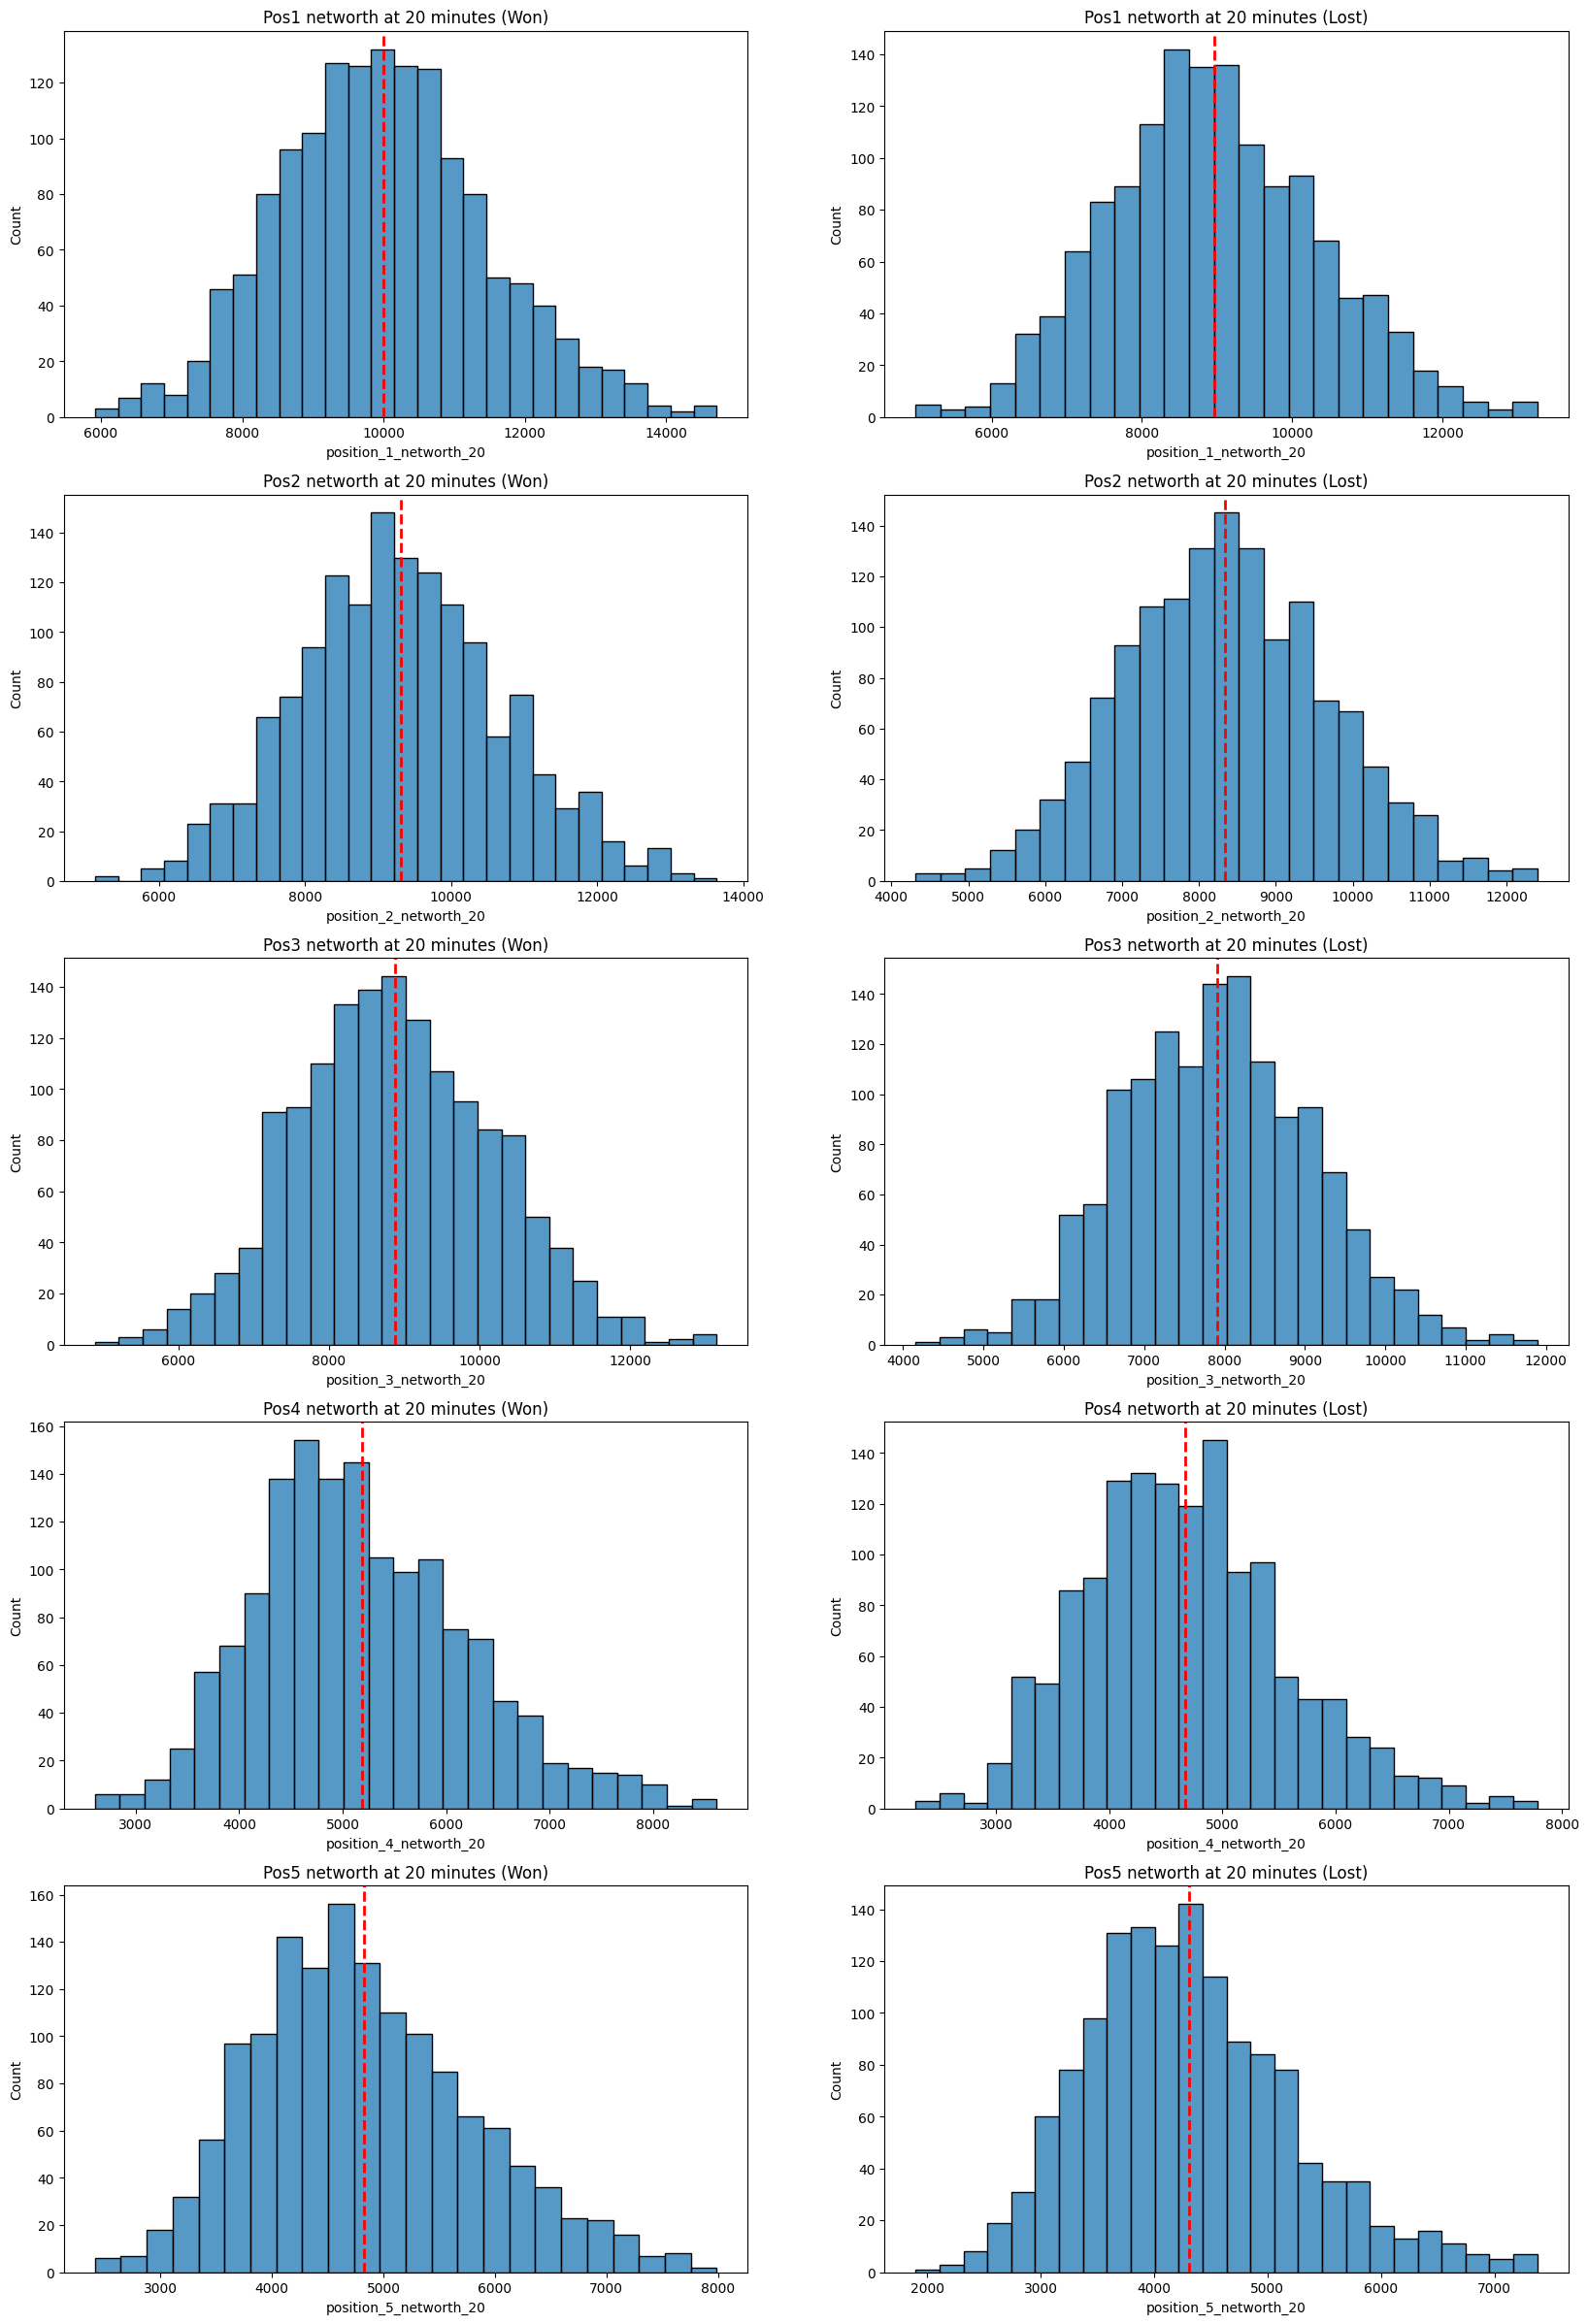

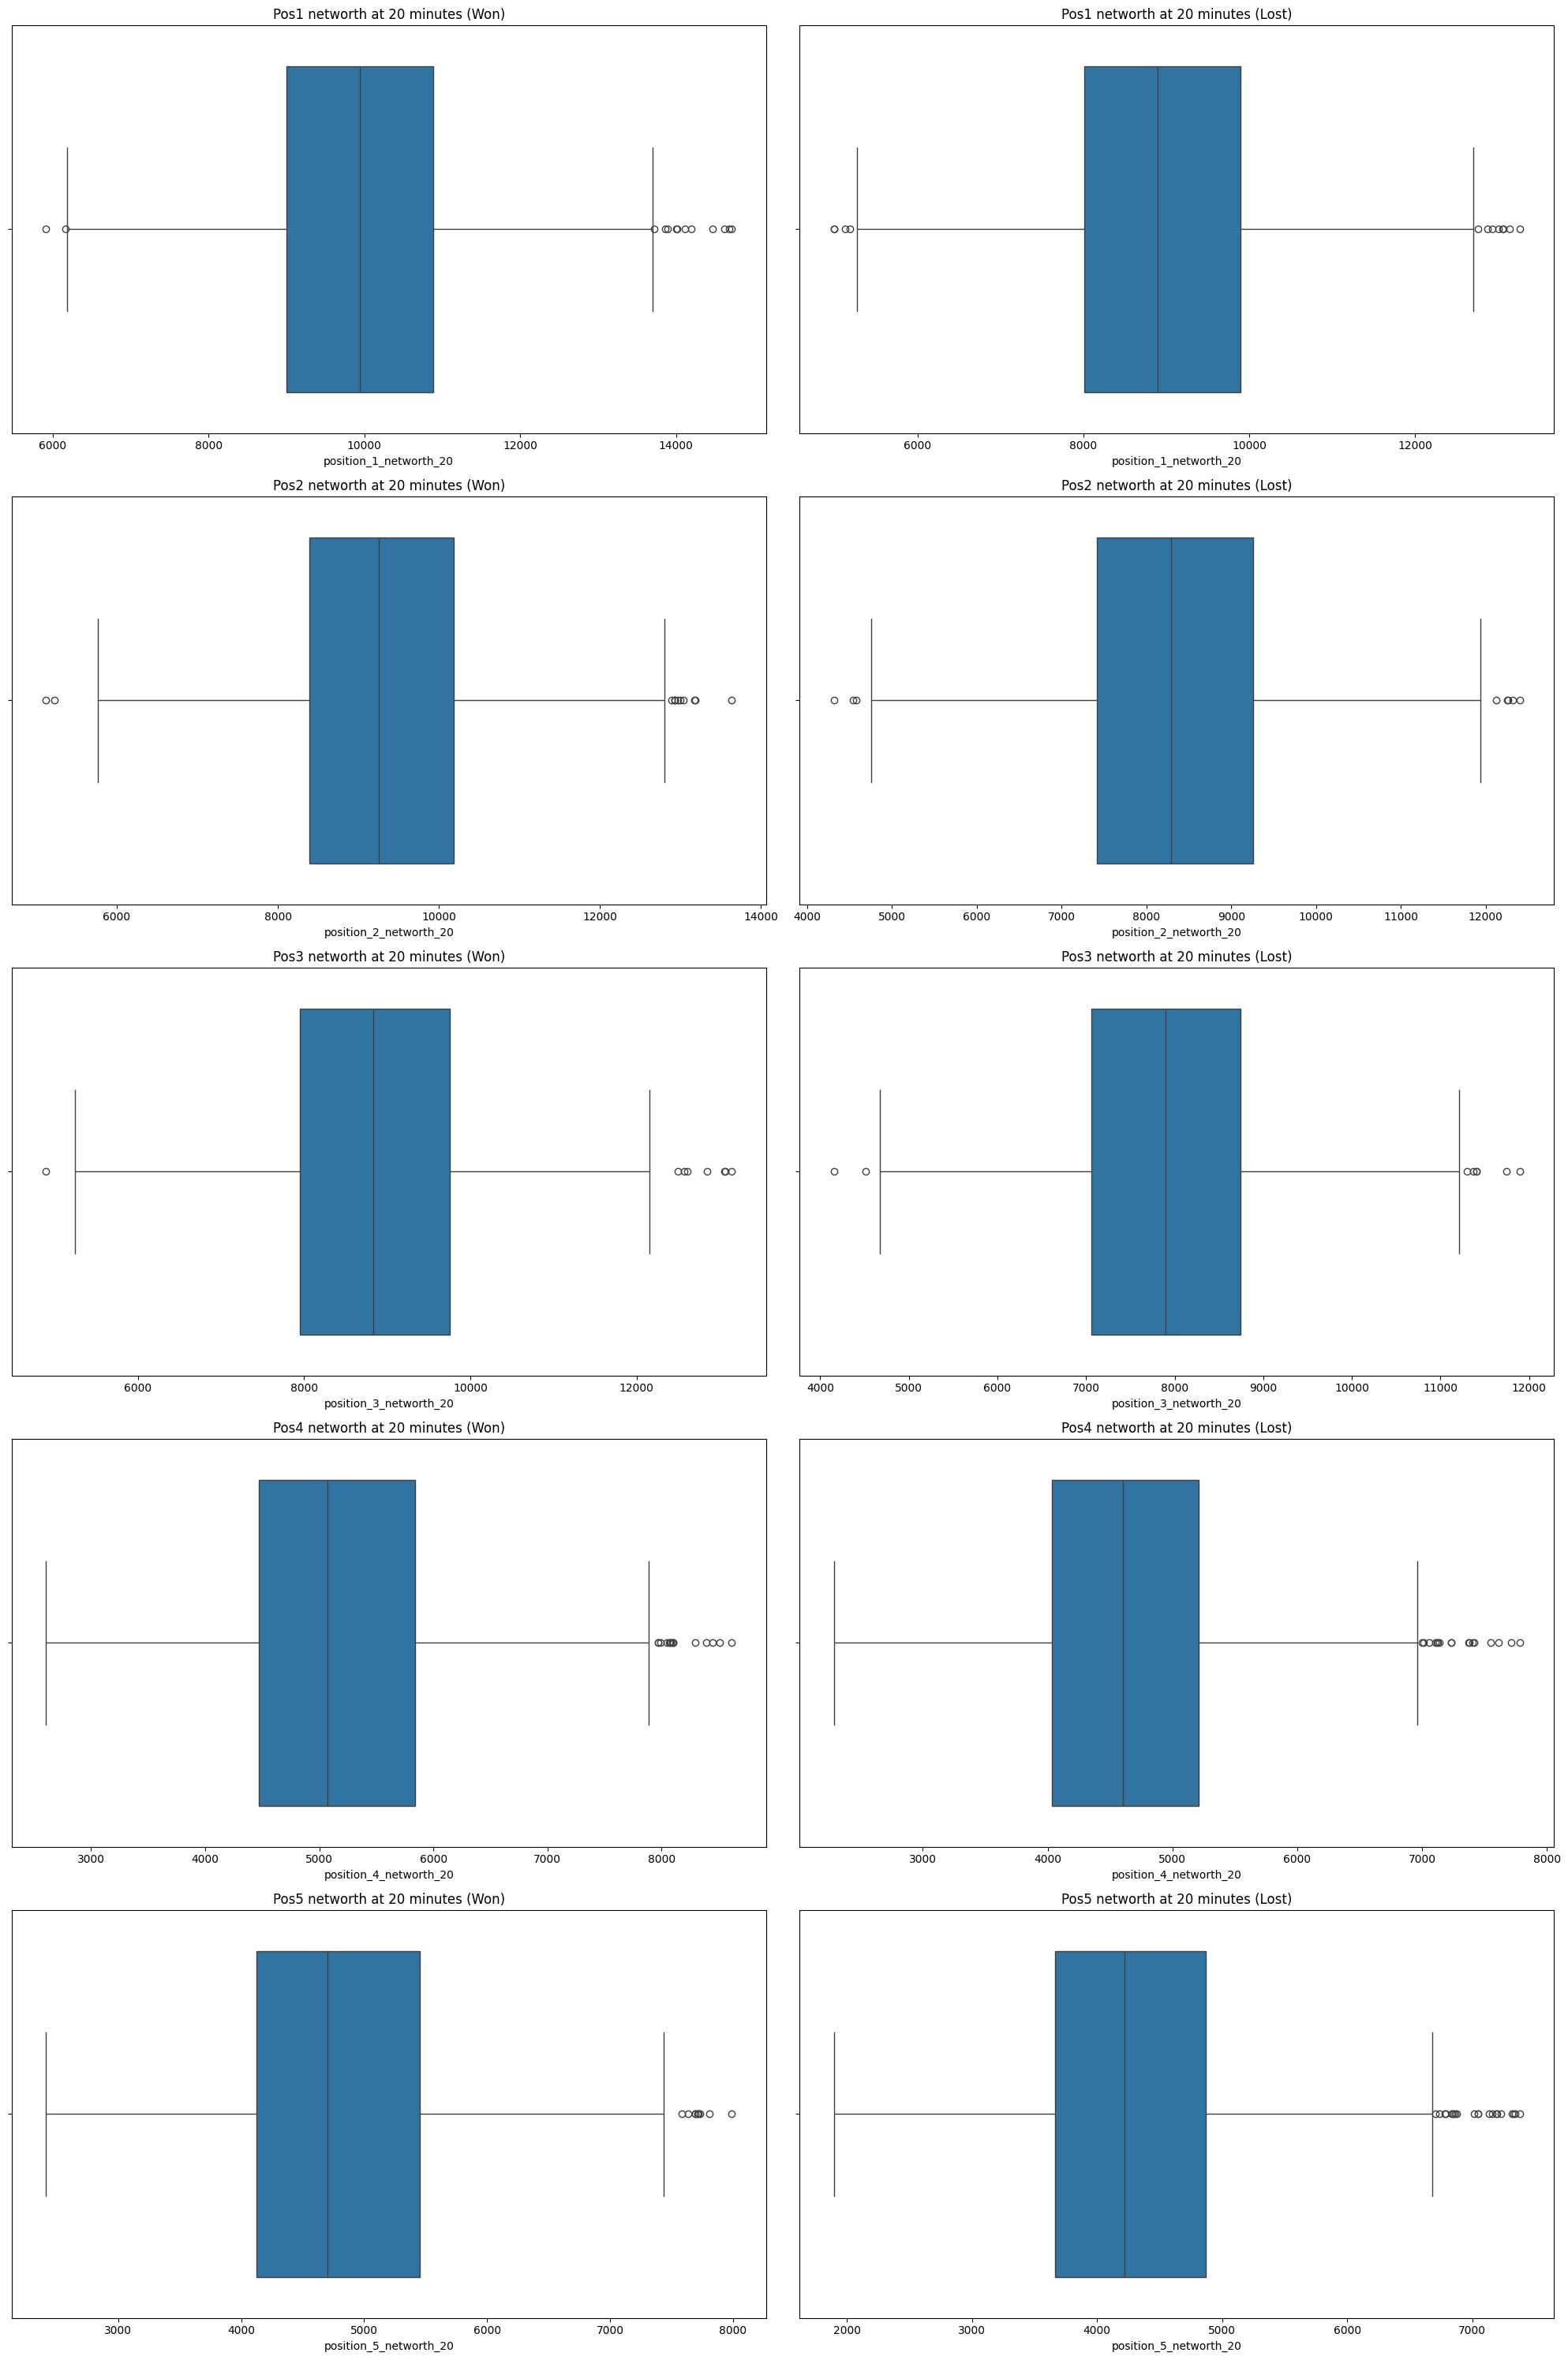

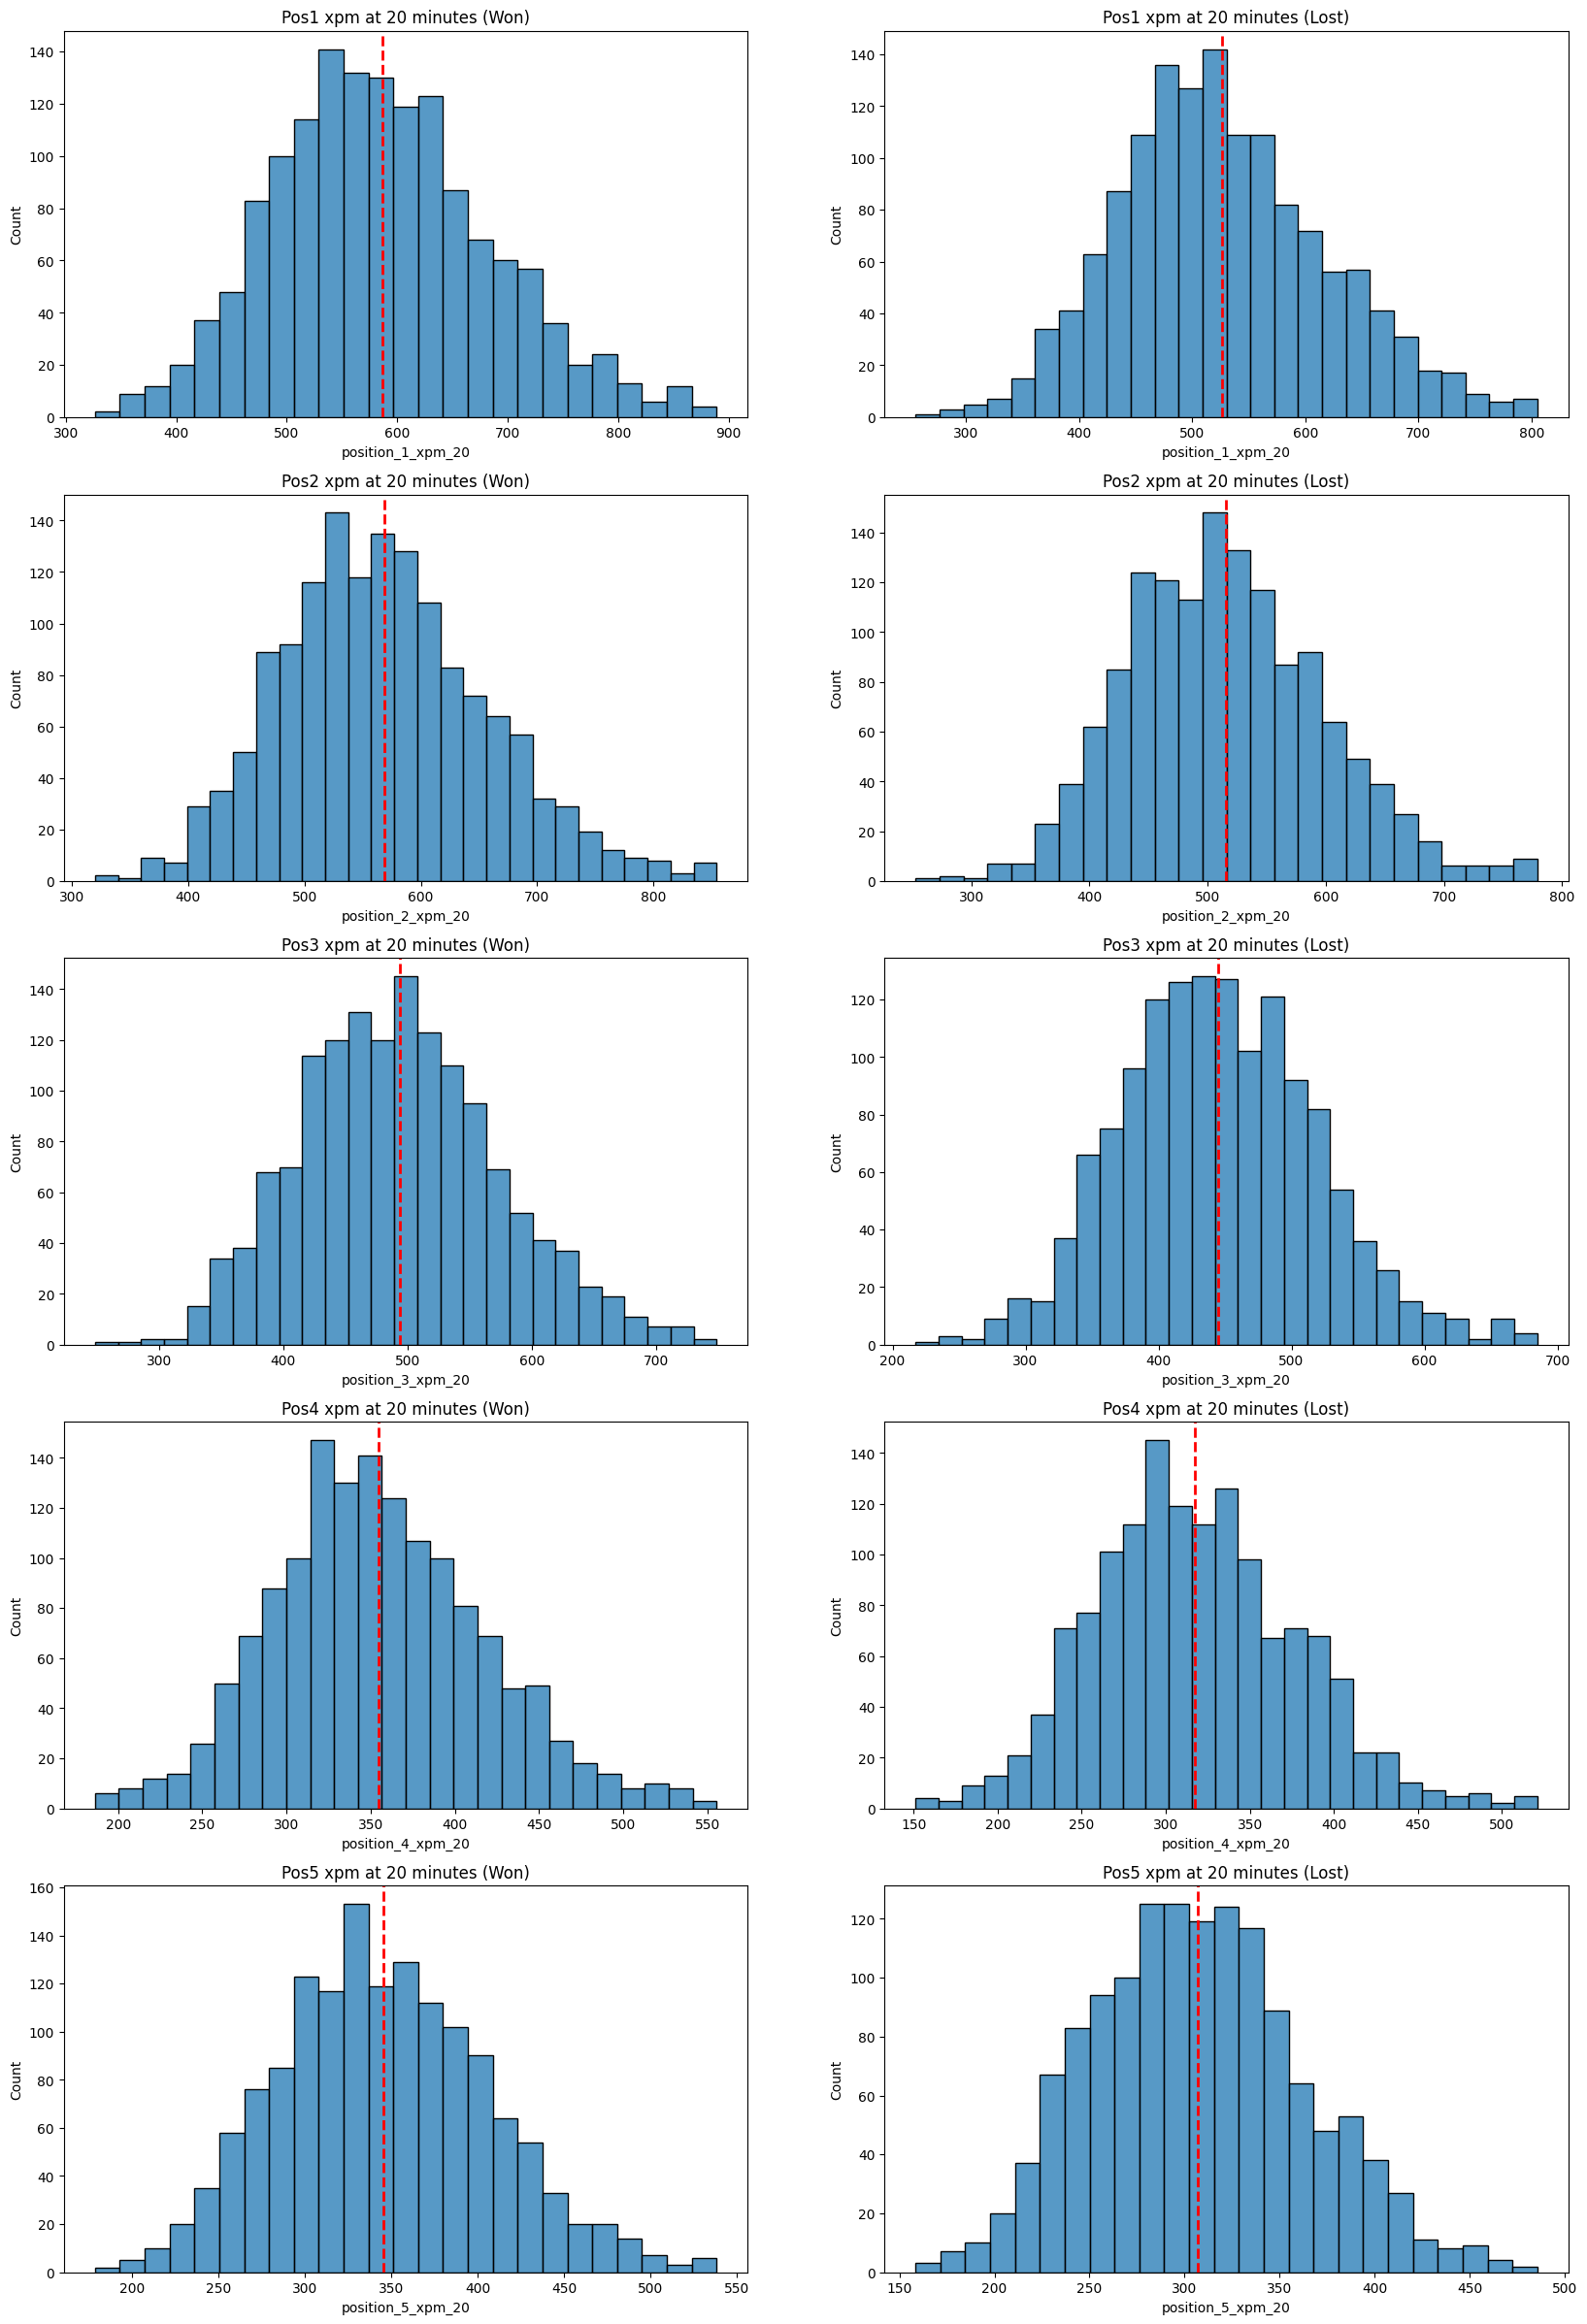

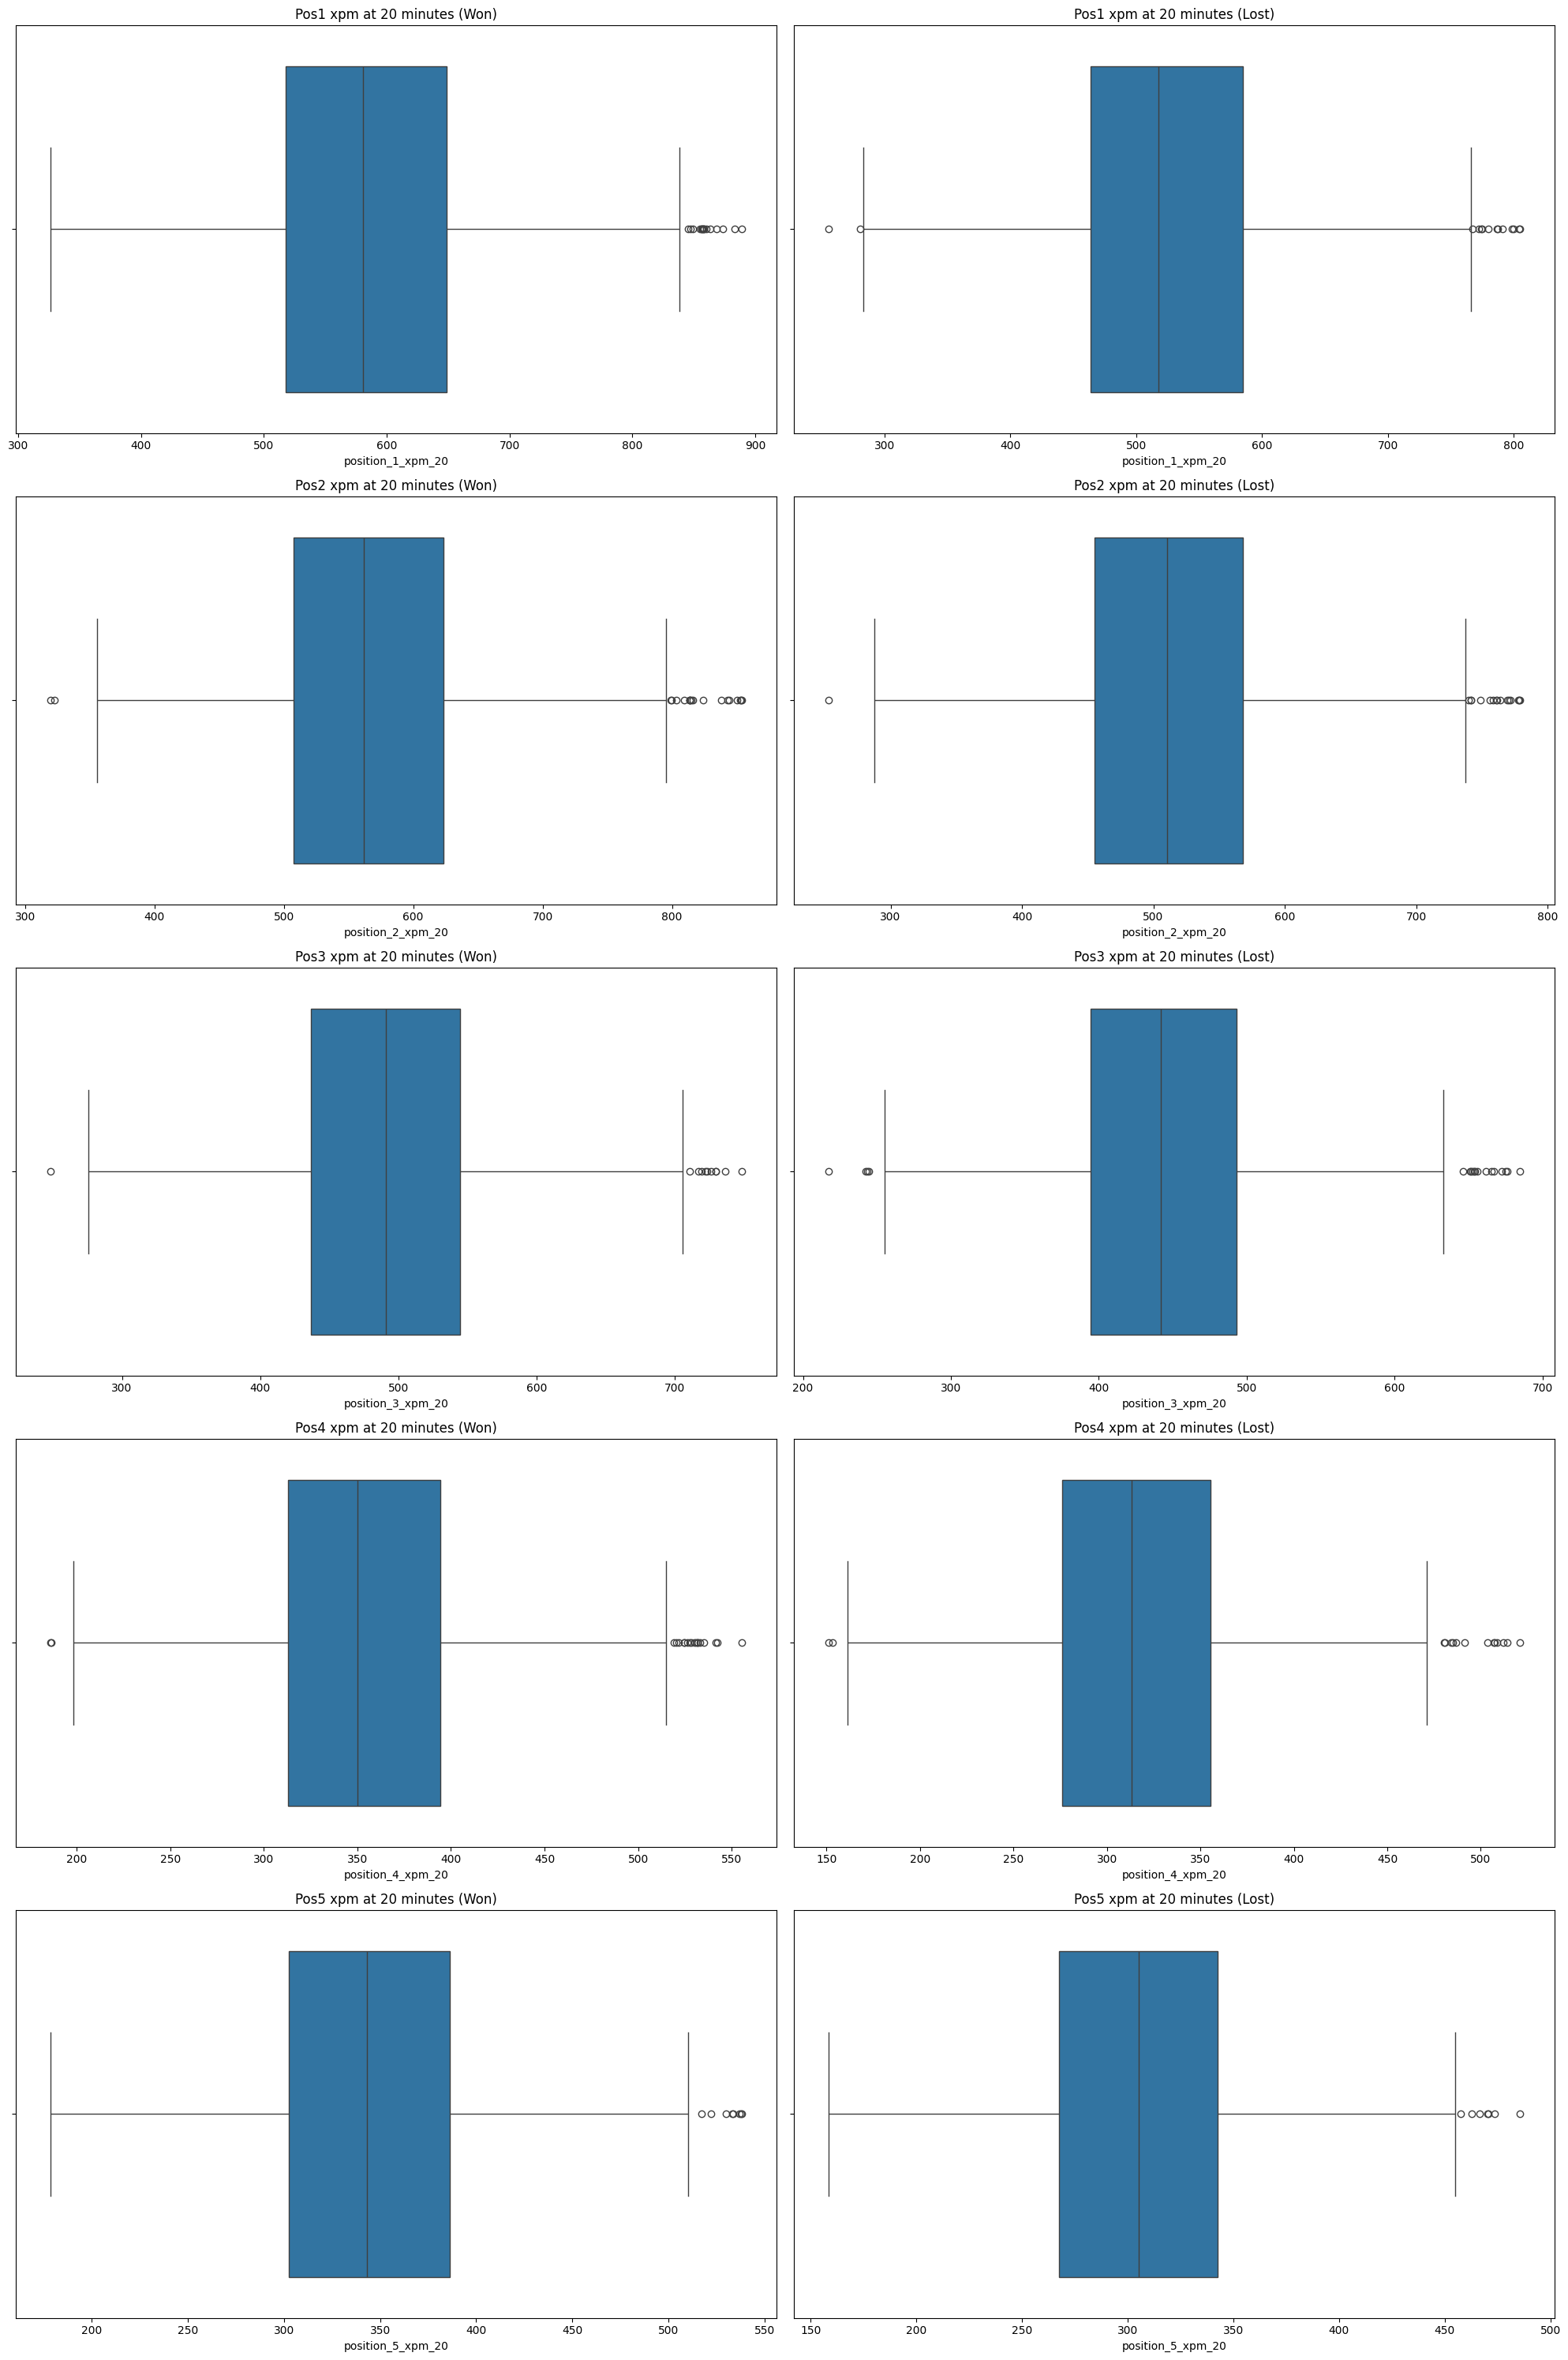

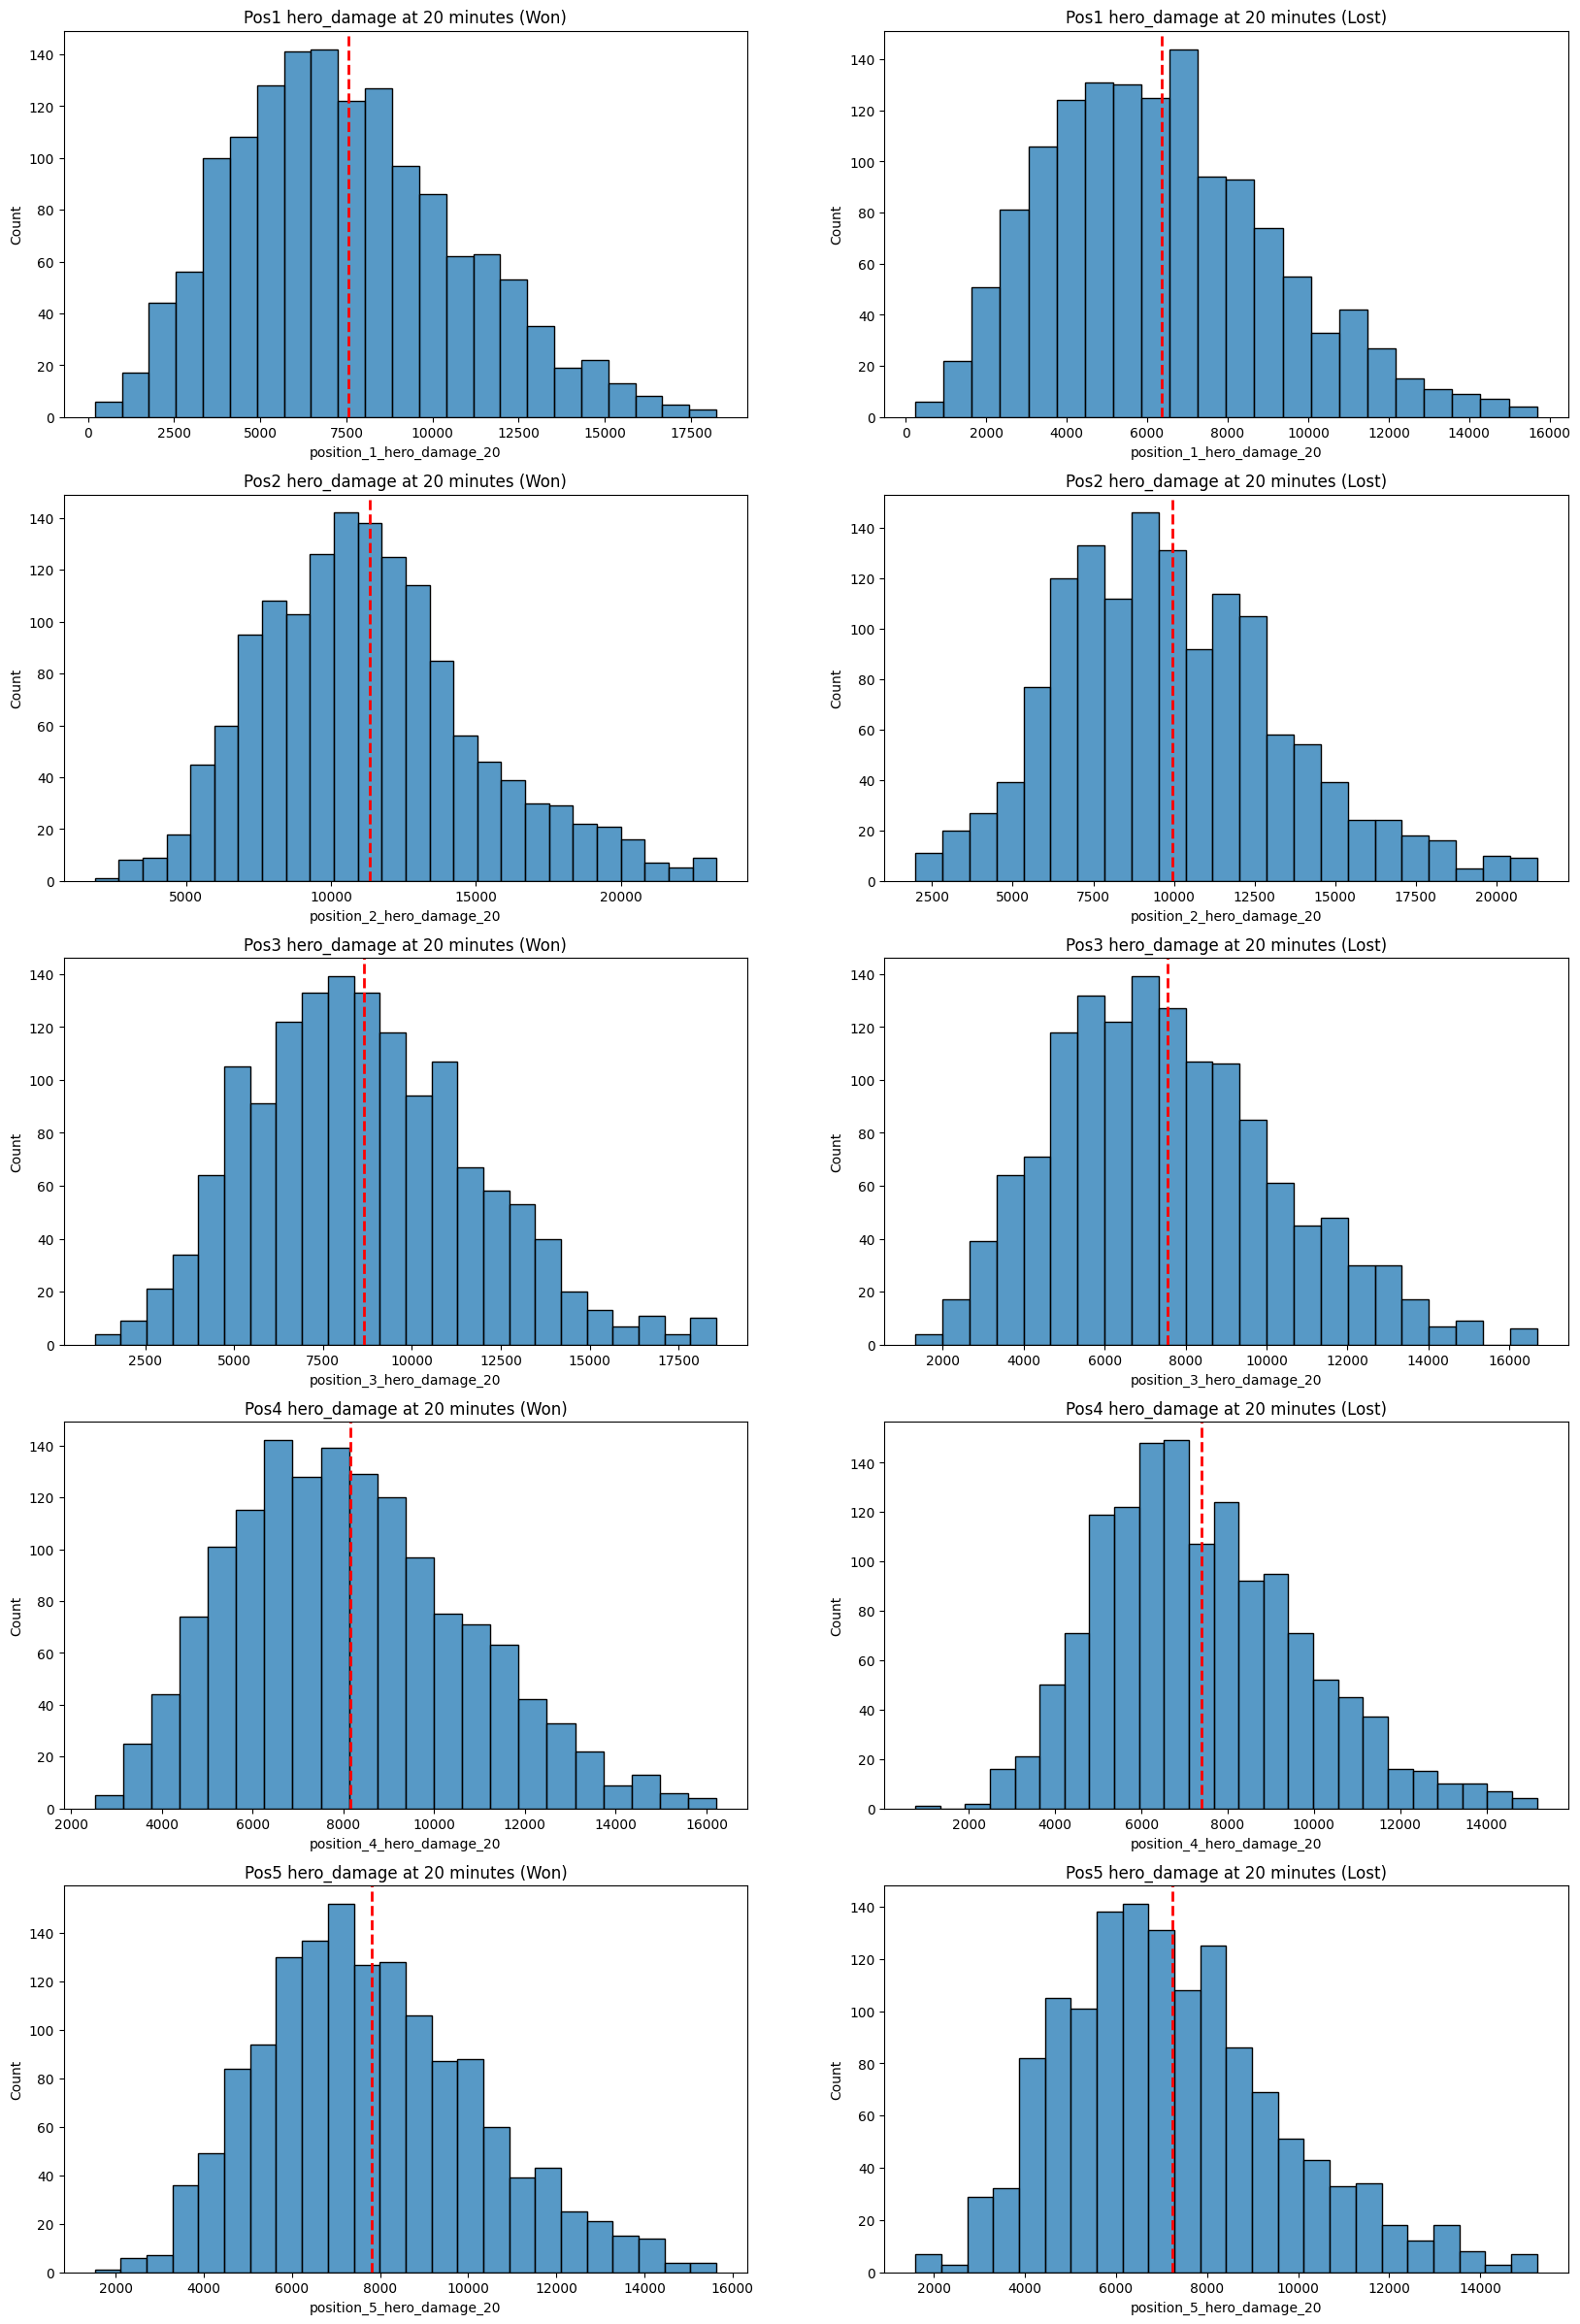

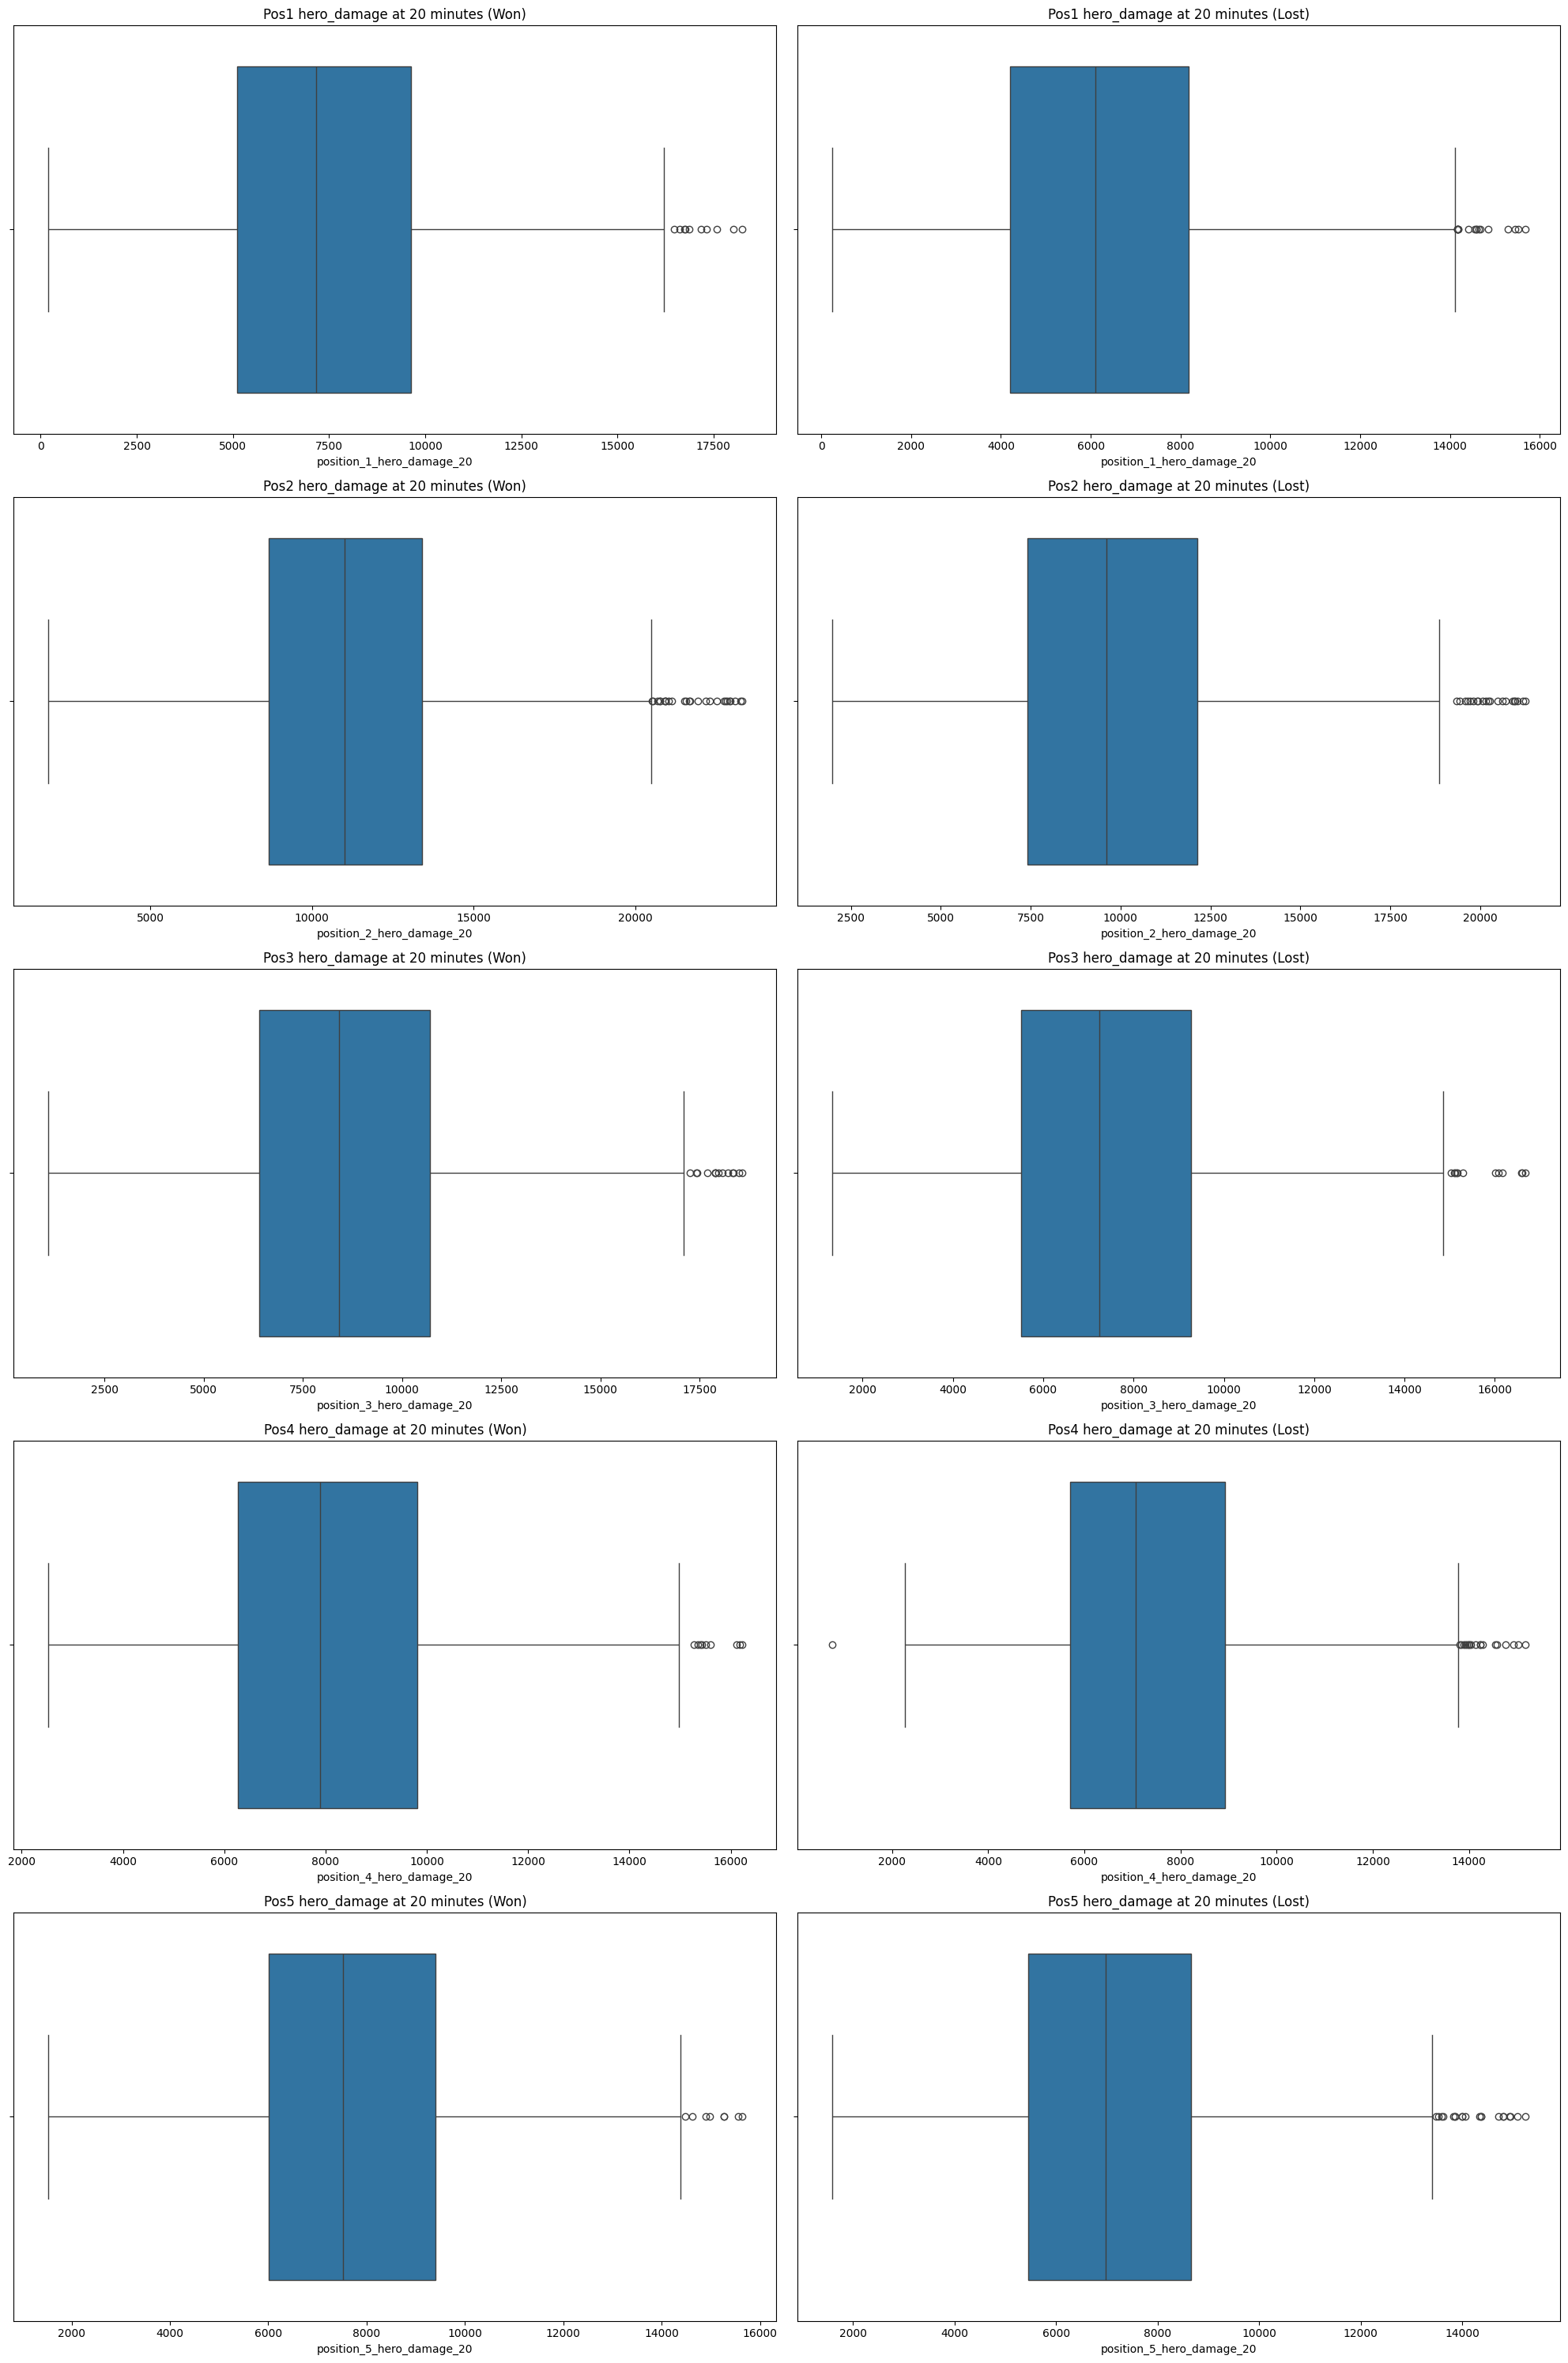

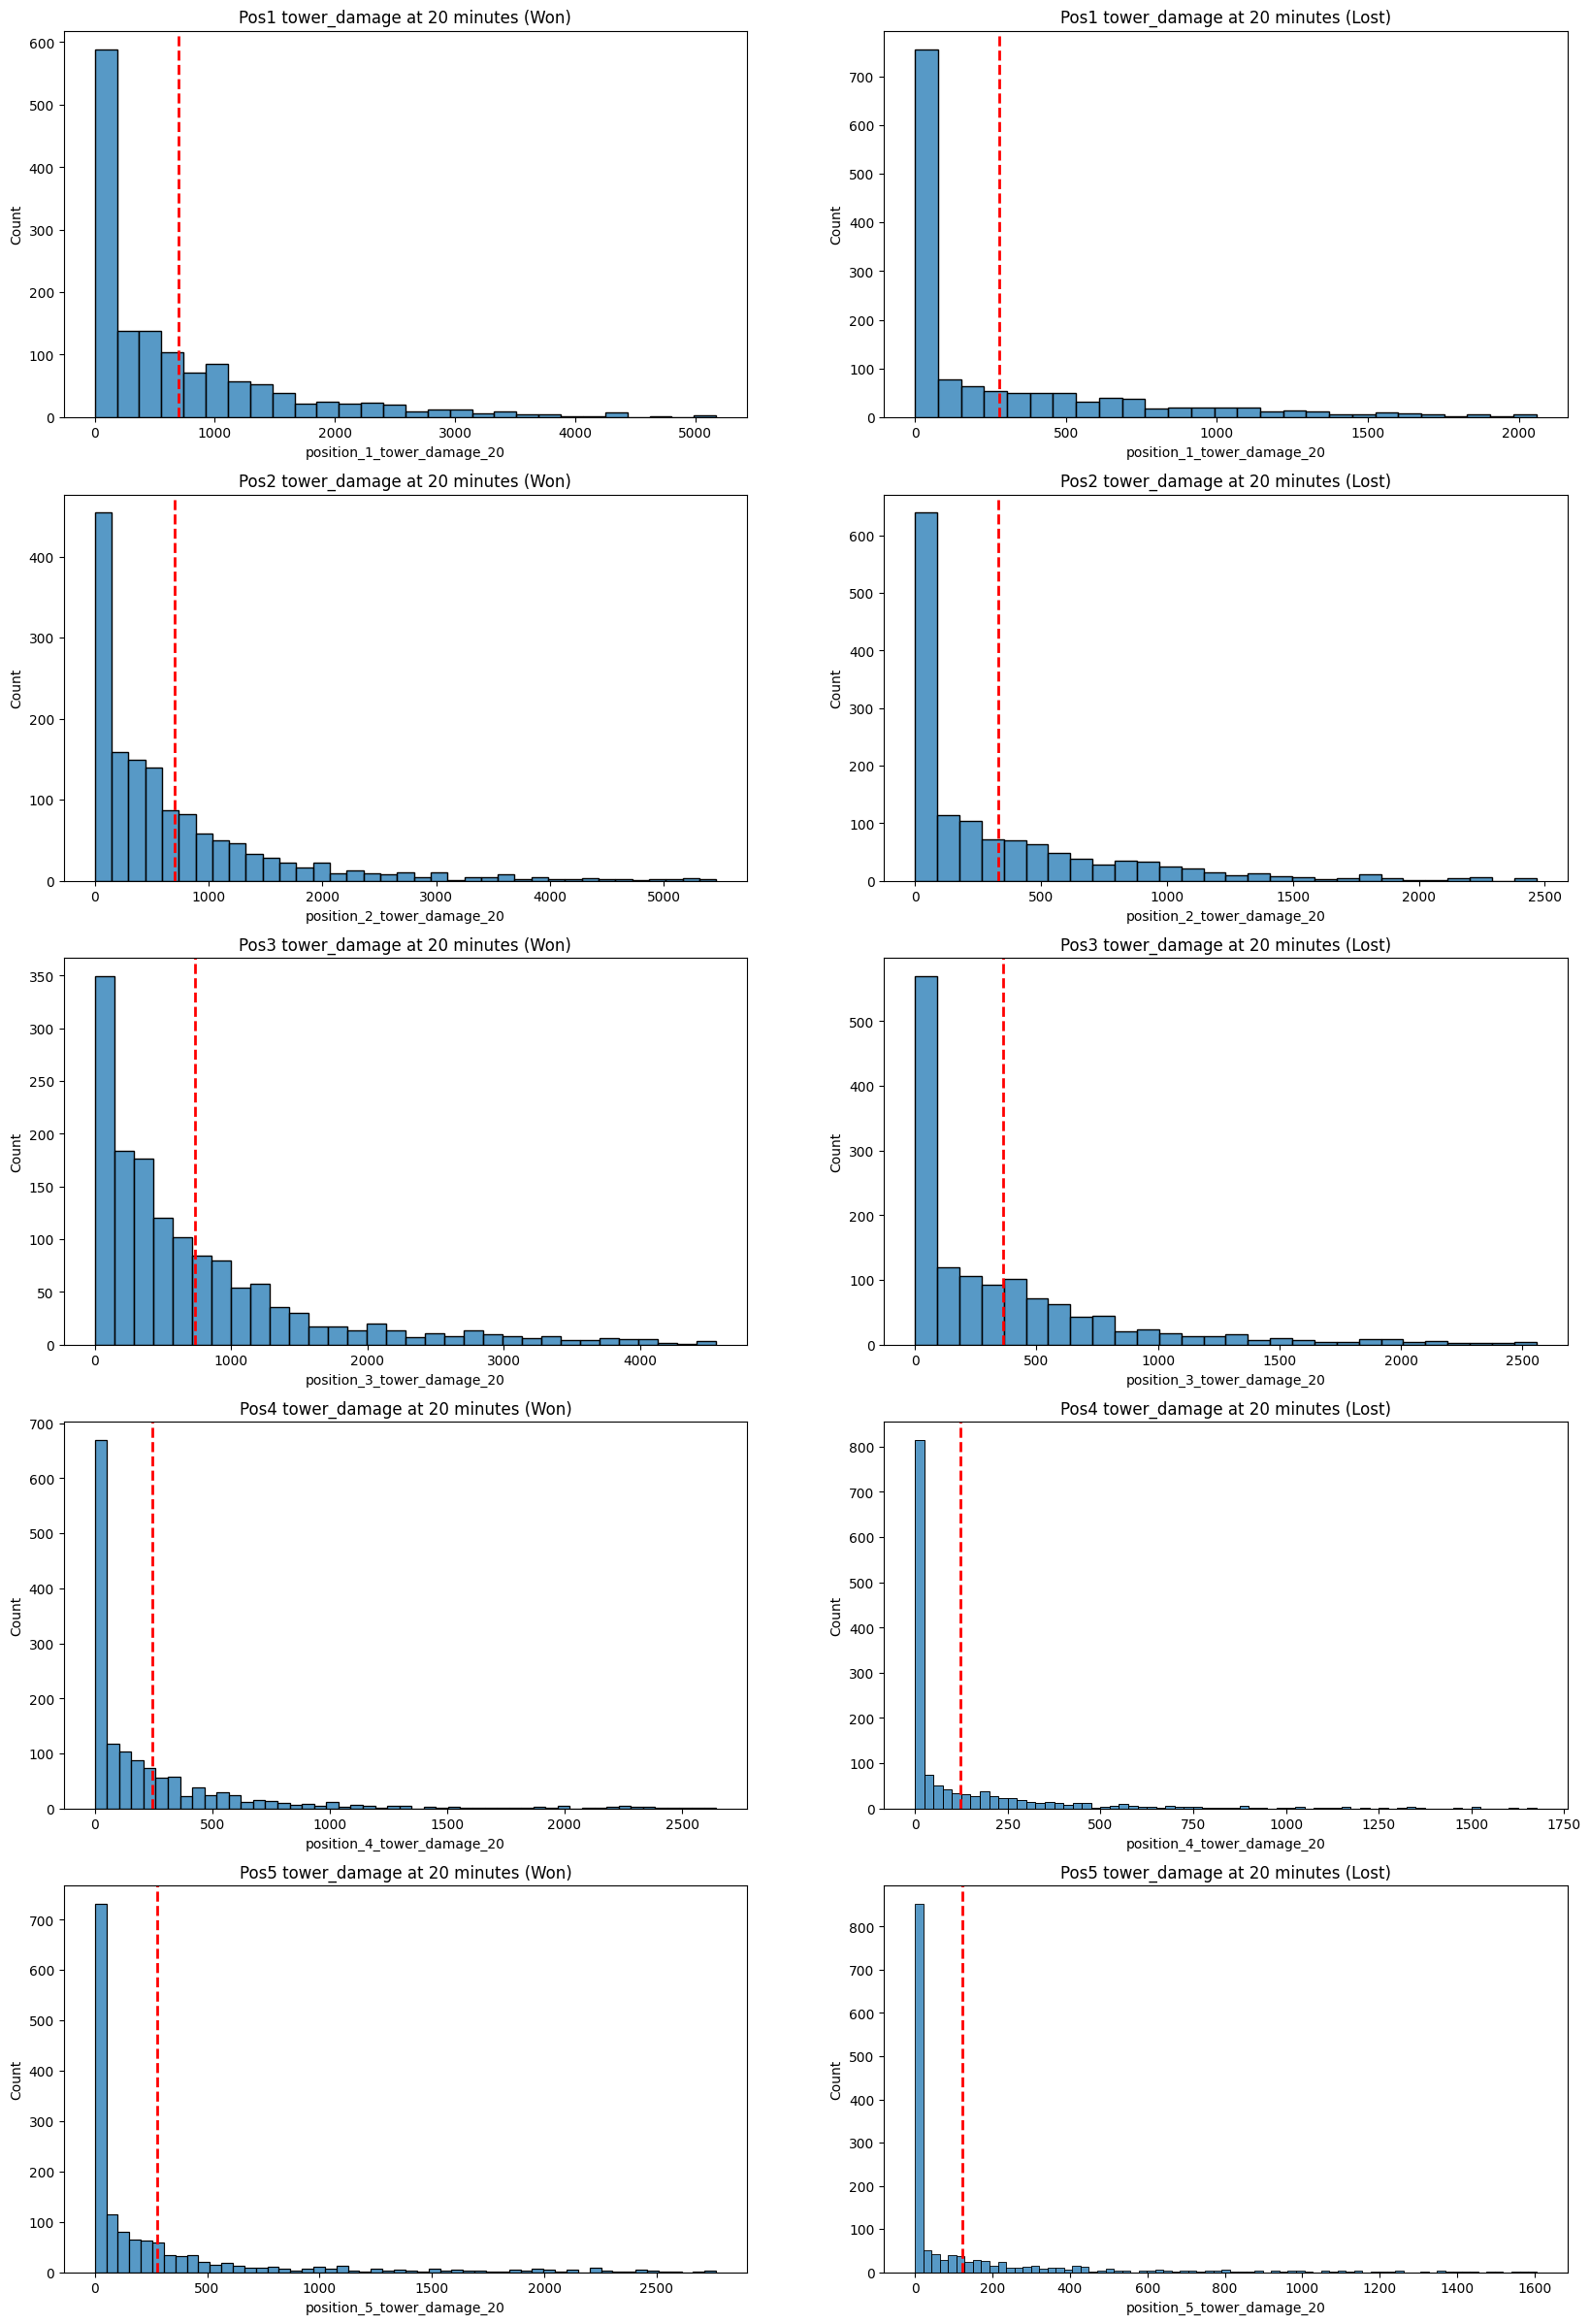

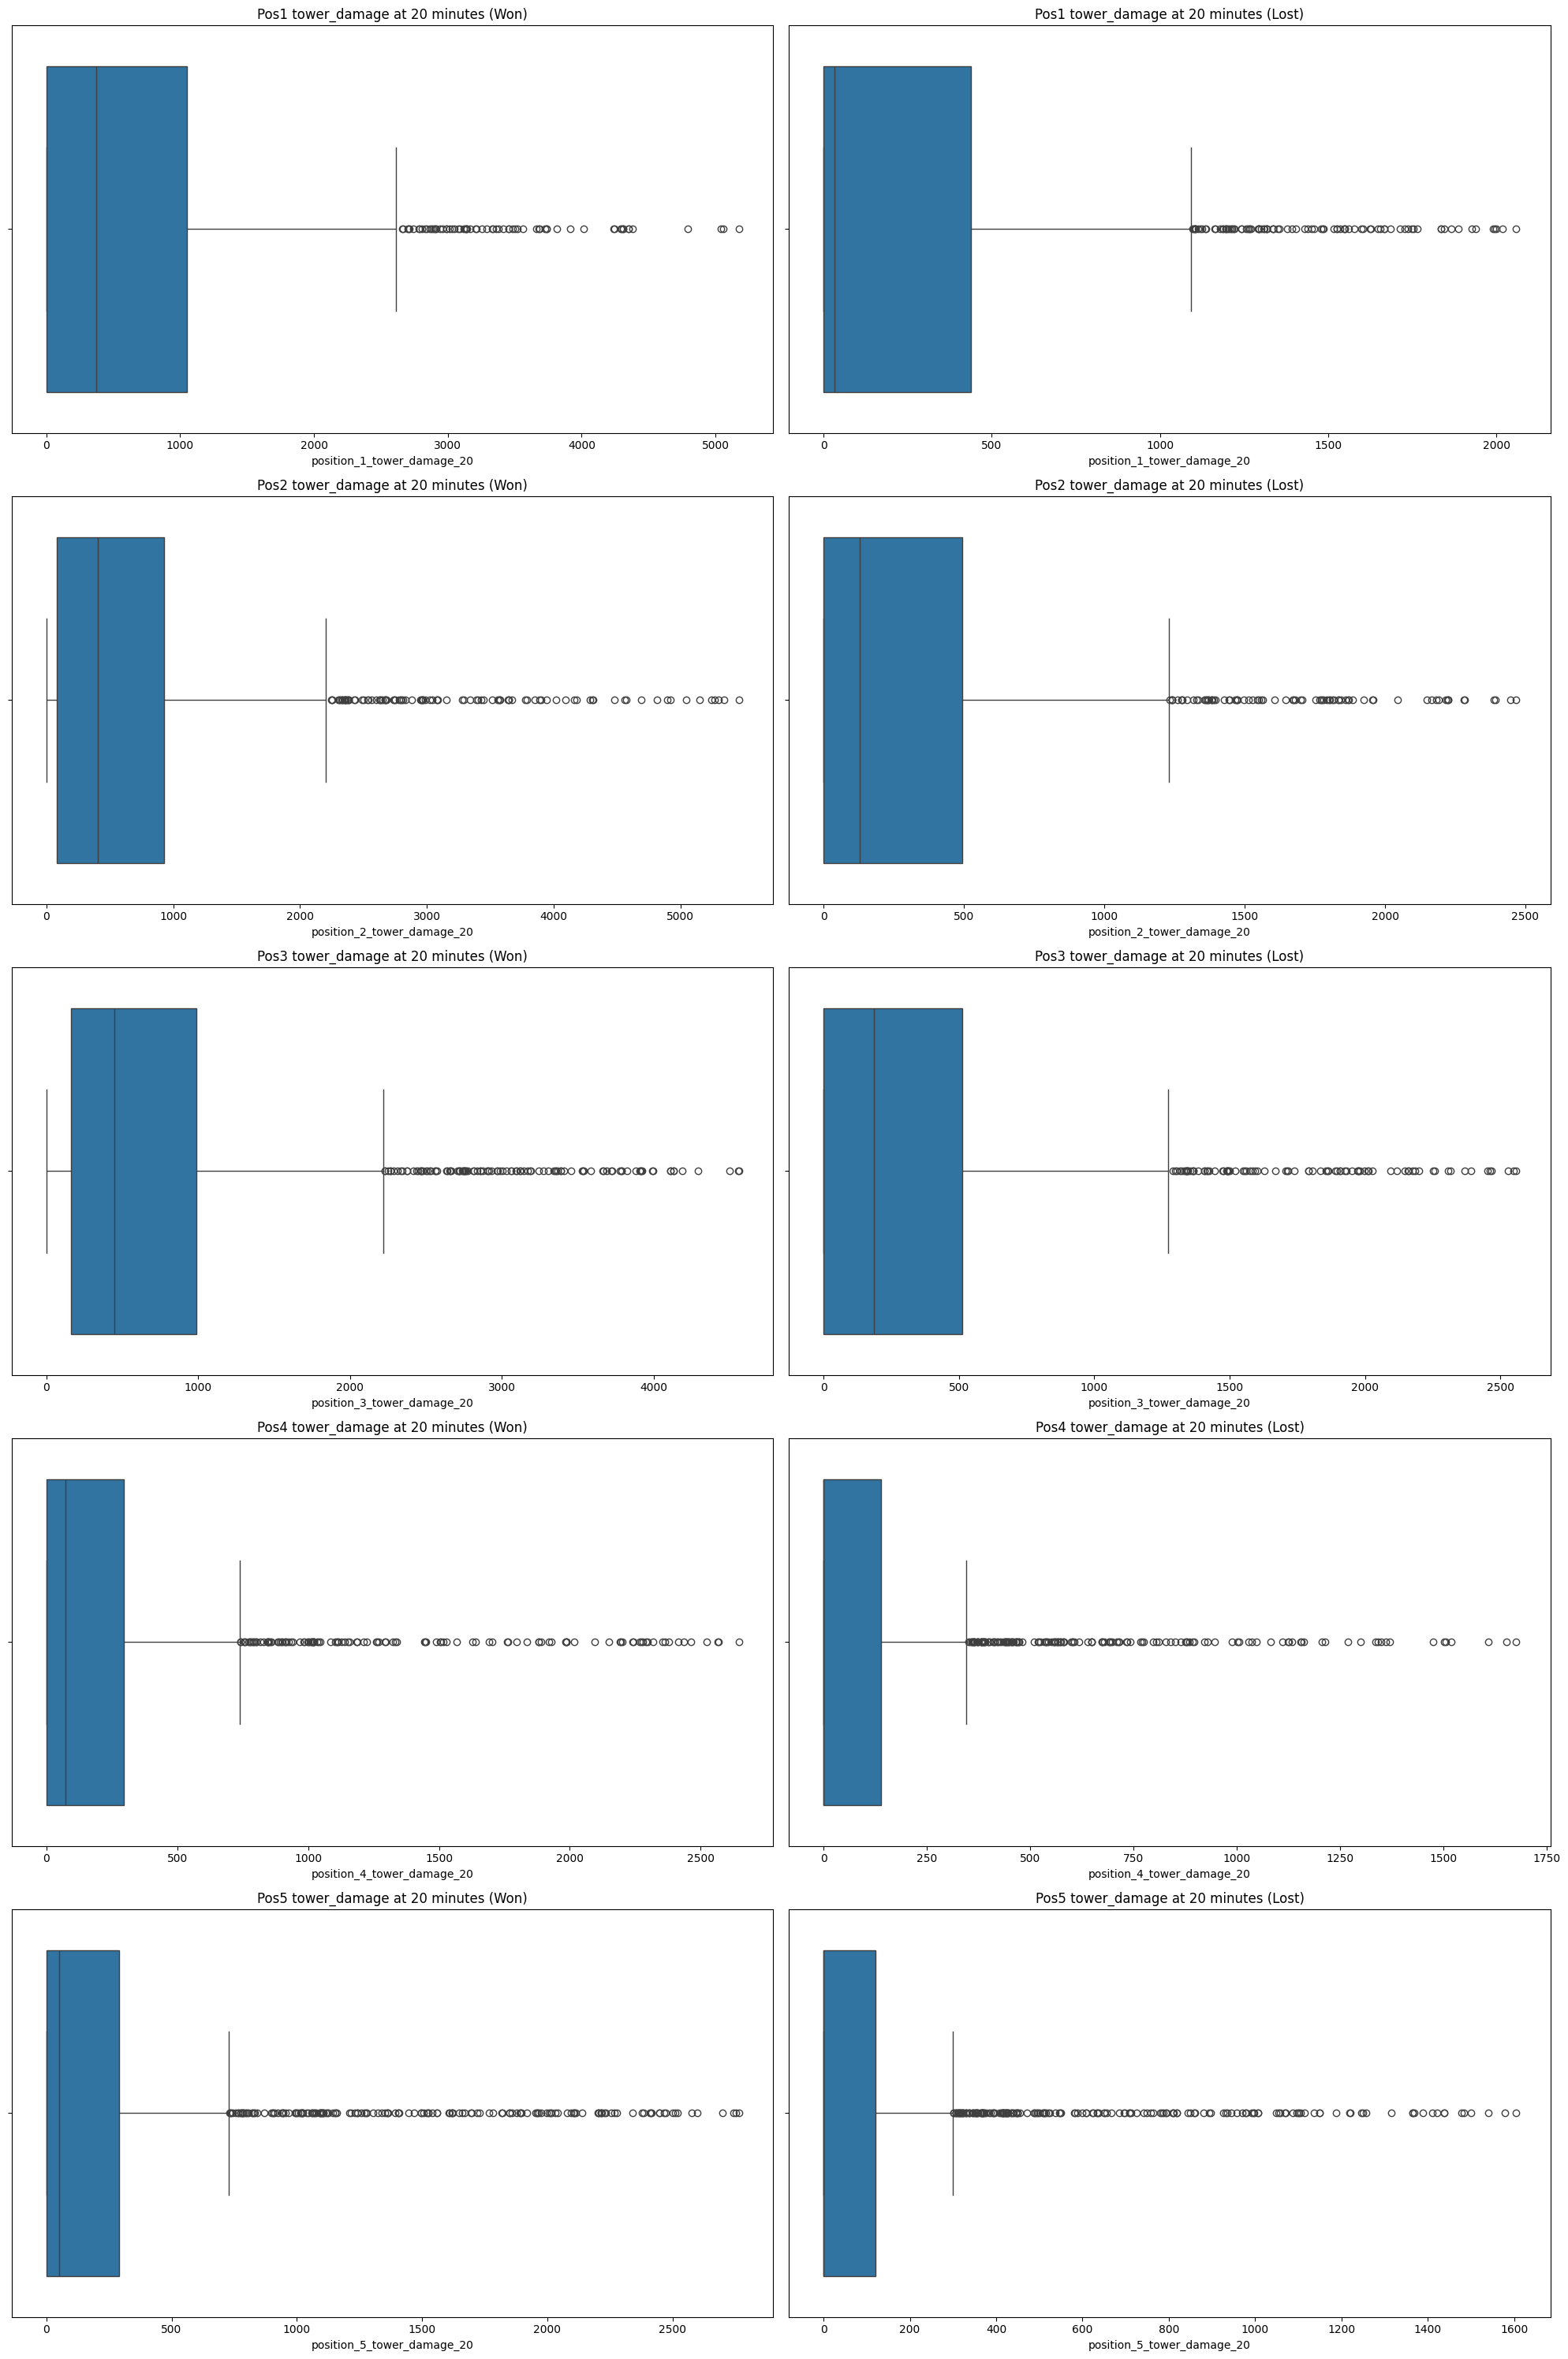

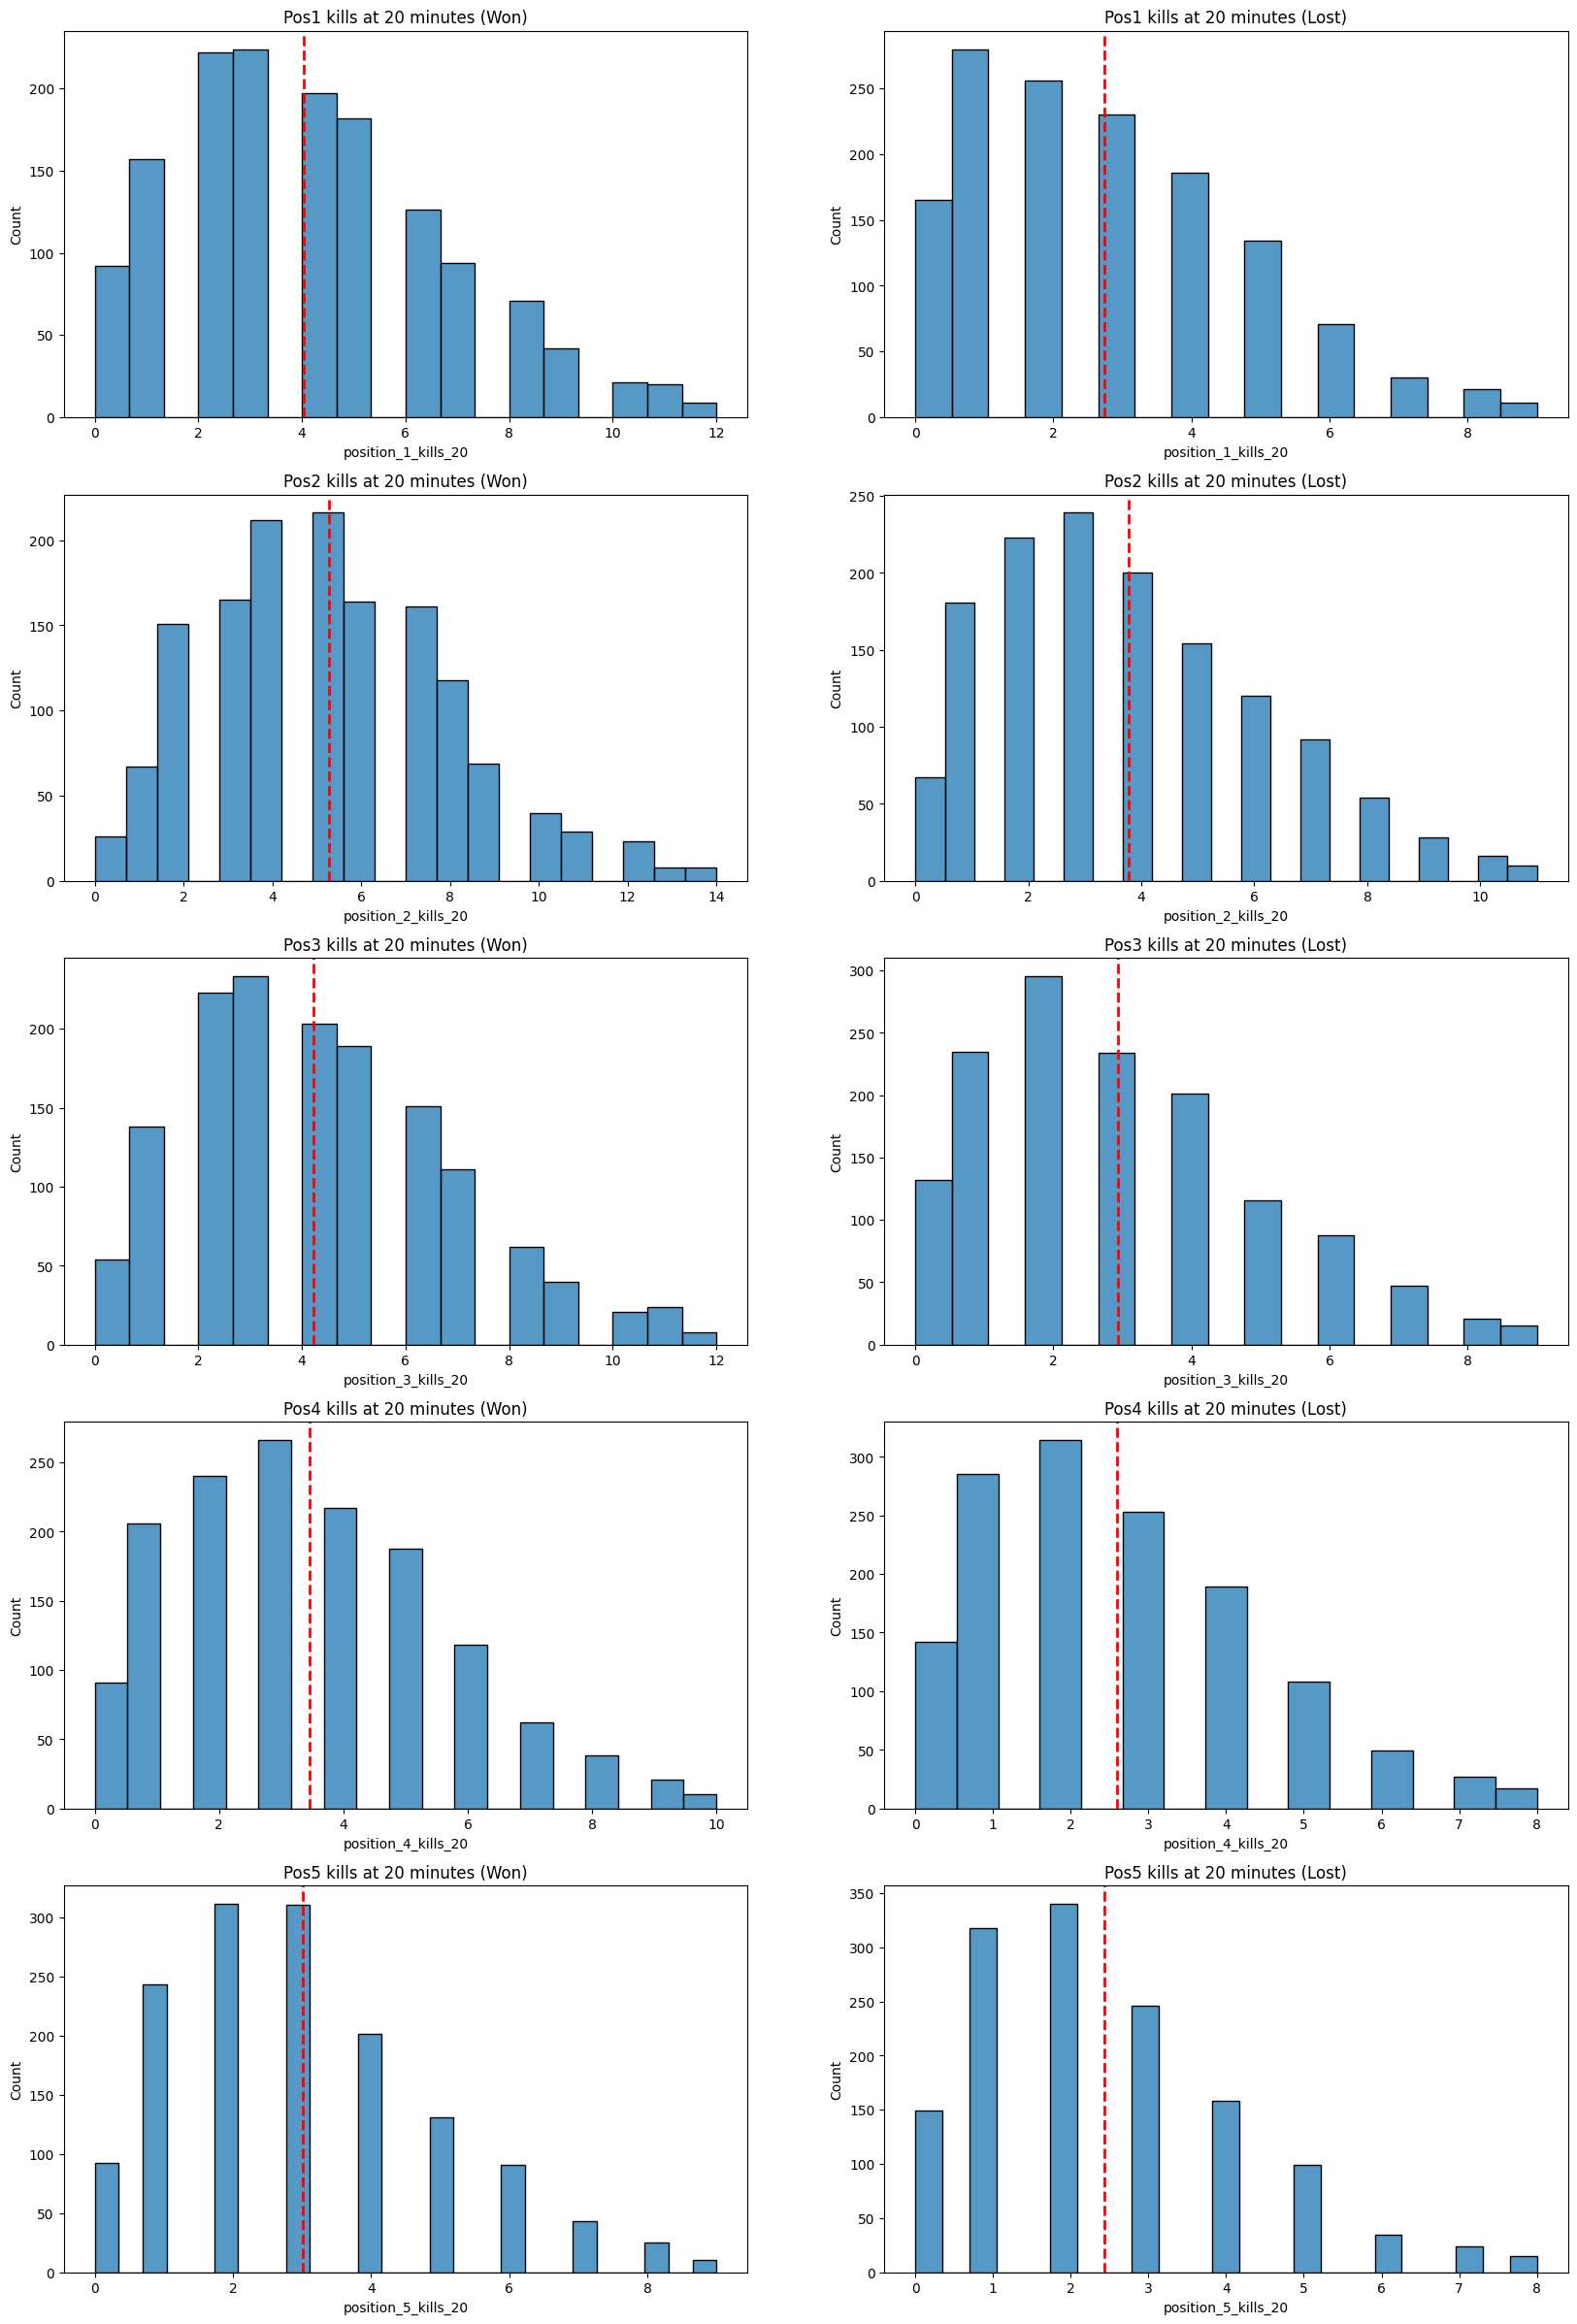

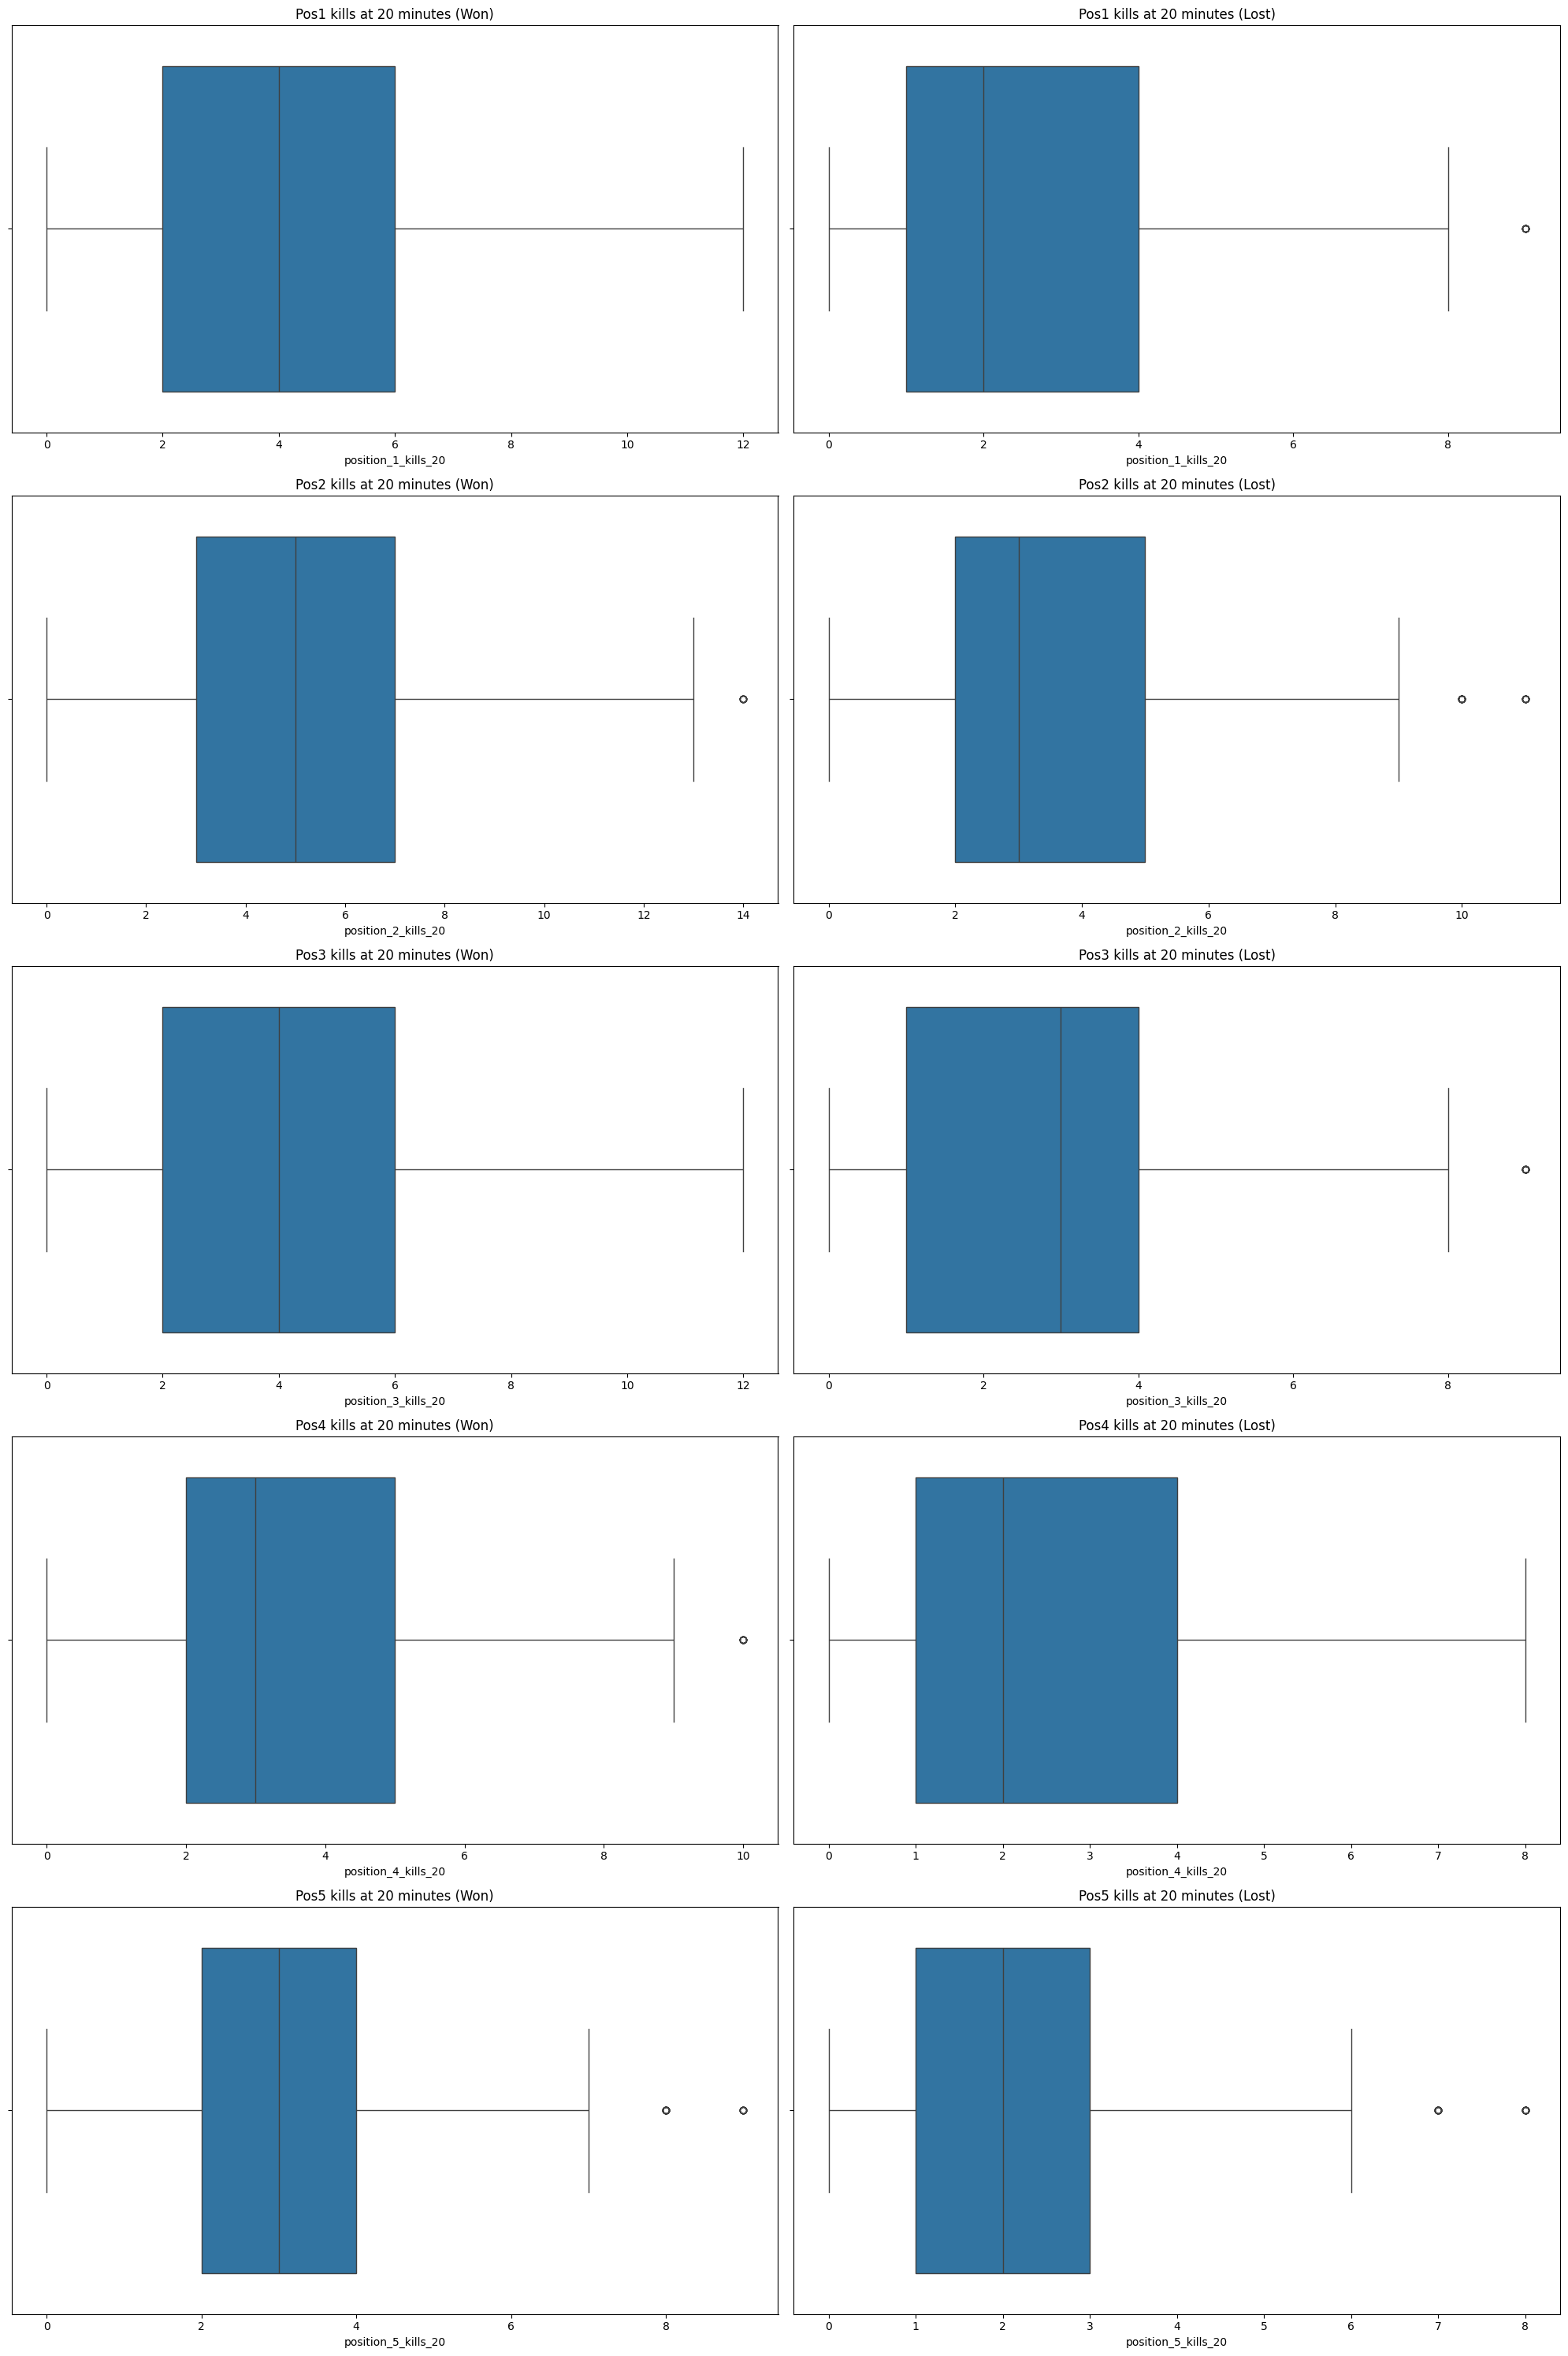

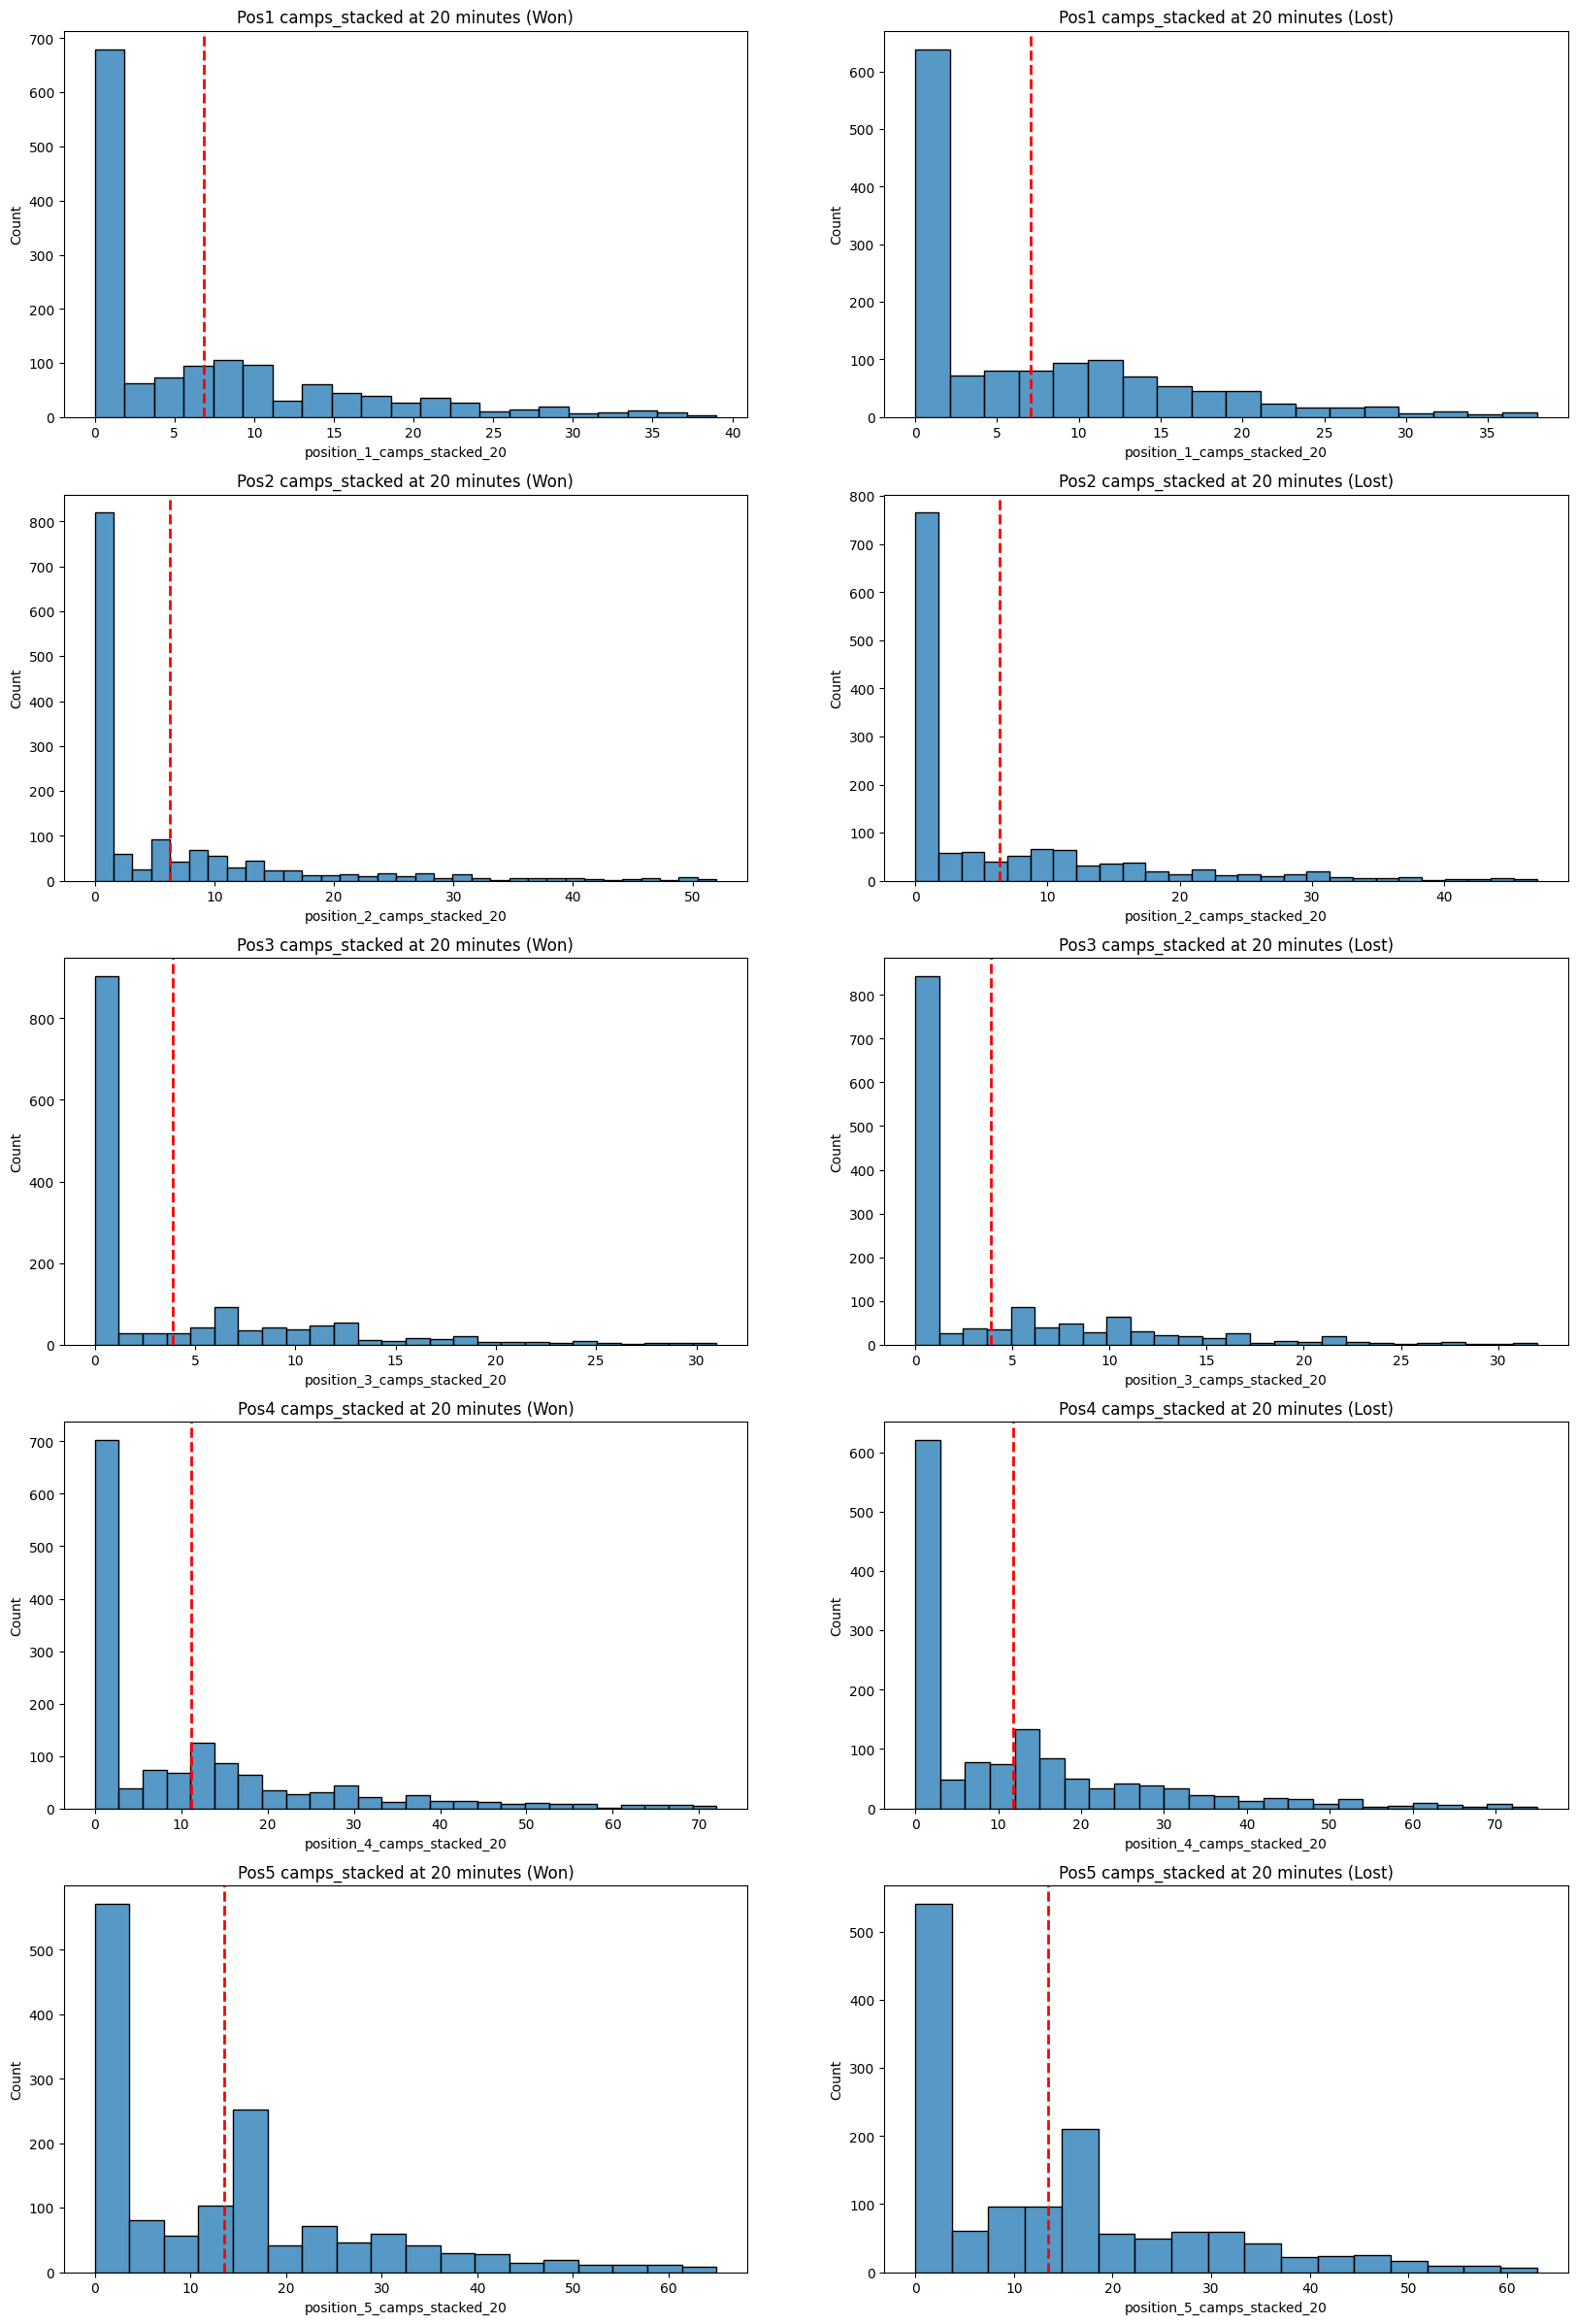

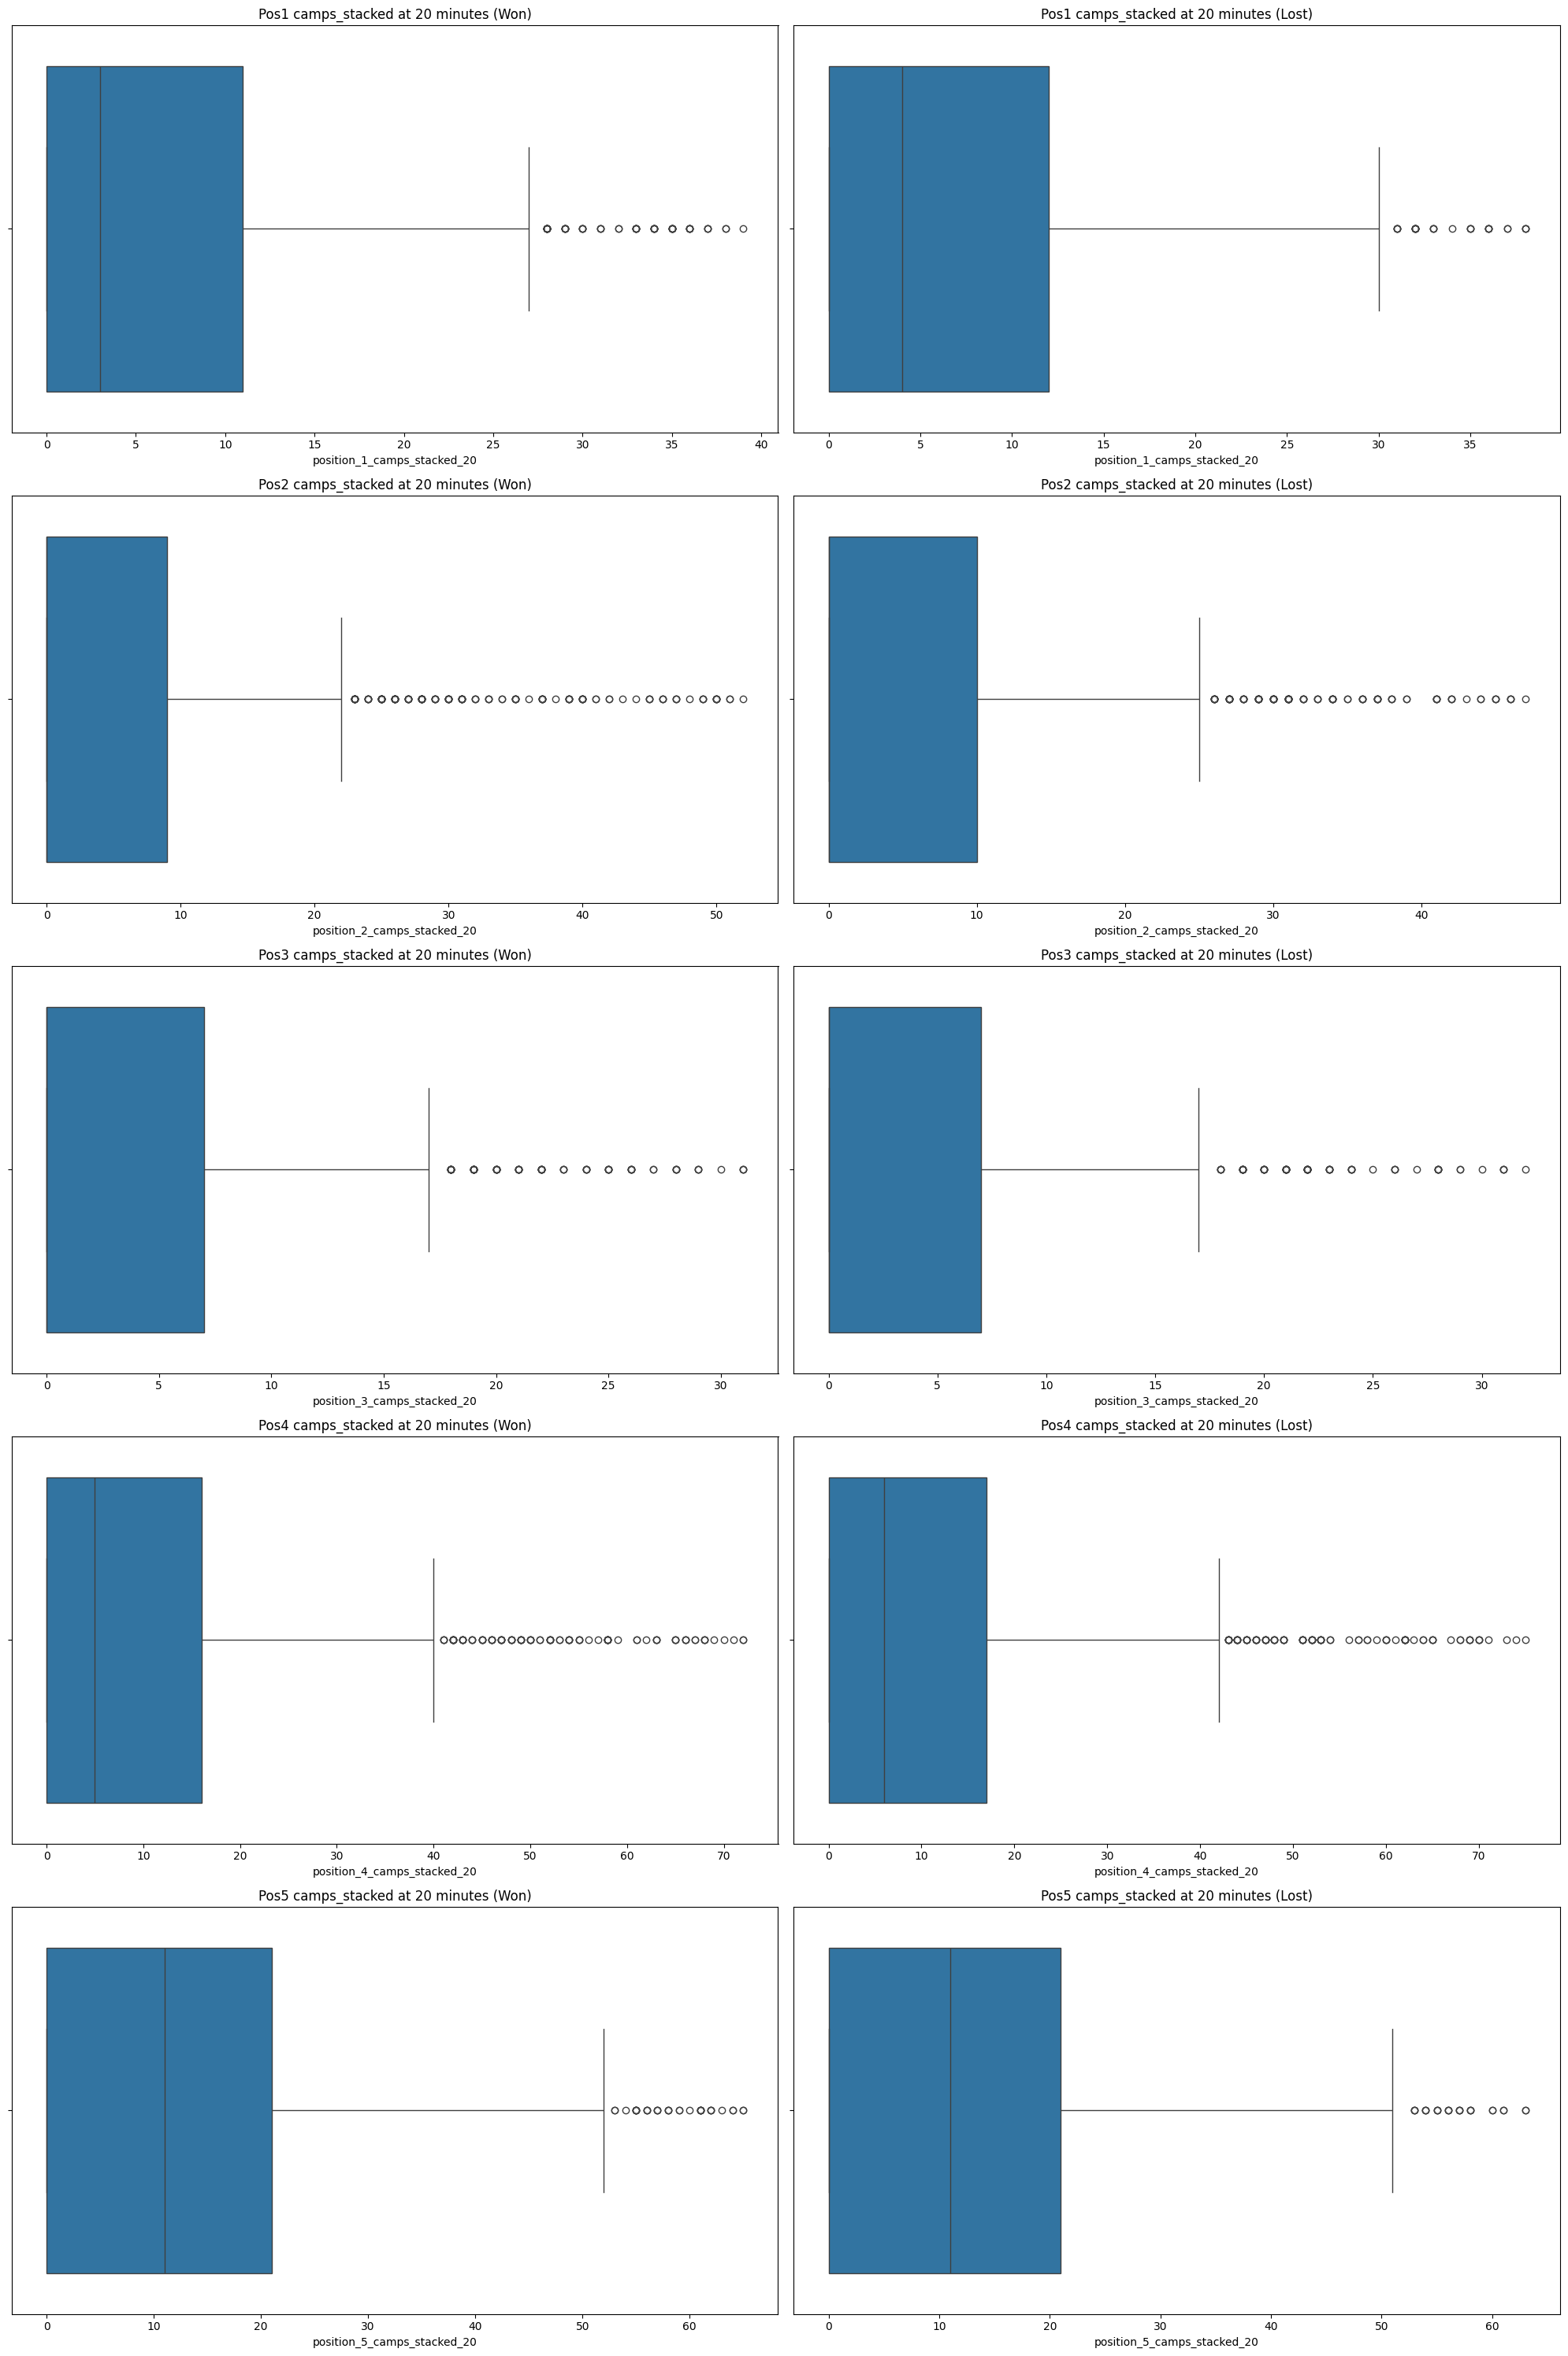

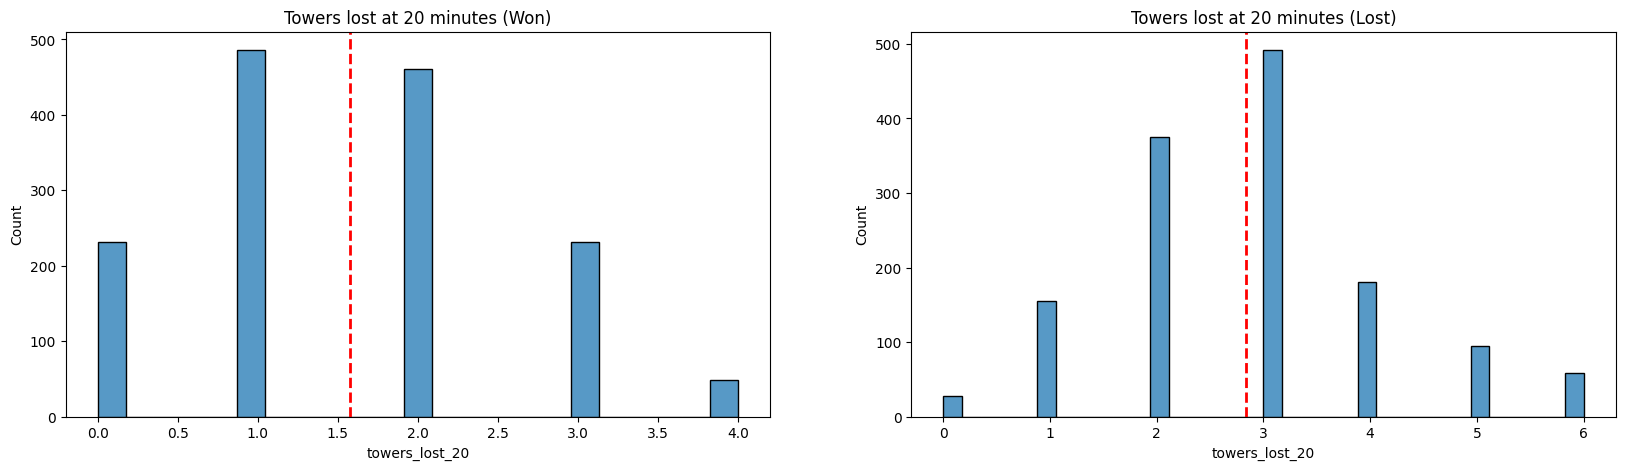

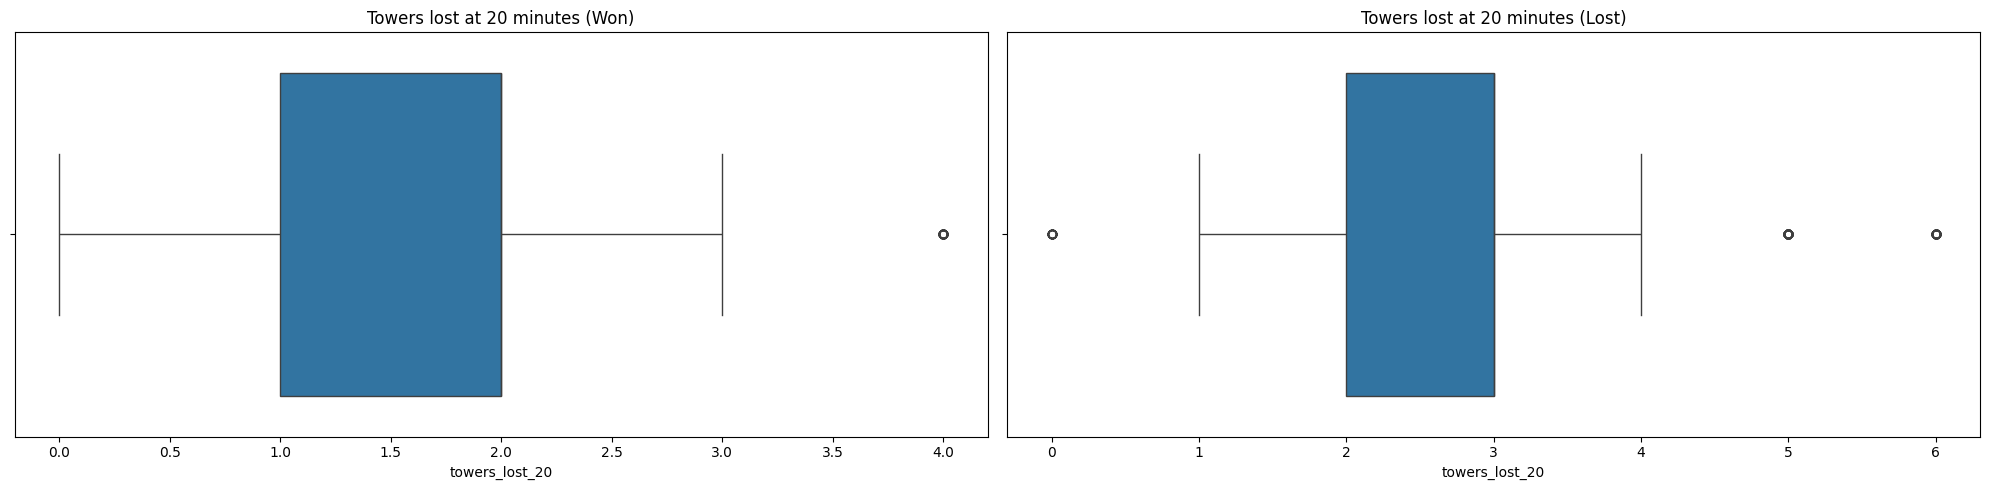

In [25]:
winner_copy, loser_copy = load_data(time=analysis_time, hero_count=hero_limit)
plot_params = [
    "networth",
    "xpm",
    "hero_damage",
    "tower_damage",
    "kills",
    "camps_stacked",
]
game_params = ["towers_lost"]
time = analysis_time

for param in plot_params:
    _, hist_axs = plt.subplots(5, 2, figsize=(20, 30))
    _, box_axs = plt.subplots(5, 2, figsize=(20, 30))
    for idx, pos in enumerate(positions):
        col = f"position_{pos}_{param}_{time}"

        # logarithmic normalization for skewed data
        # winner_copy[col] = np.log(winner_copy[col] + 1)
        # loser_copy[col] = np.log(loser_copy[col] + 1)

        # standard normalization
        # winner_copy[col] = (
        #     winner_copy[col] - winner_copy[col].mean()
        # ) / winner_copy[col].std()

        # loser_copy[col] = (
        #     loser_copy[col] - loser_copy[col].mean()
        # ) / loser_copy[col].std()

        title = f"Pos{pos} {param} at {time} minutes"

        # plot histograms
        ax = hist_axs[idx, 0]
        sns.histplot(winner_copy[col], ax=ax)
        ax.set_title(f"{title} (Won)")
        ax.axvline(
            winner_copy[col].mean(),
            color="red",
            linestyle="dashed",
            linewidth=2,
        )

        ax = hist_axs[idx, 1]
        sns.histplot(loser_copy[col], ax=ax)
        ax.set_title(f"{title} (Lost)")
        ax.axvline(
            loser_copy[col].mean(),
            color="red",
            linestyle="dashed",
            linewidth=2,
        )

        # plot boxplots
        ax = box_axs[idx, 0]
        sns.boxplot(x=winner_copy[col], ax=ax)
        ax.set_title(f"{title} (Won)")

        ax = box_axs[idx, 1]
        sns.boxplot(x=loser_copy[col], ax=ax)
        ax.set_title(f"{title} (Lost)")
    plt.tight_layout()
    plt.show()

for param in game_params:
    _, hist_axs = plt.subplots(1, 2, figsize=(20, 5))
    _, box_axs = plt.subplots(1, 2, figsize=(20, 5))
    col = f"{param}_{time}"

    # plot histograms
    ax = hist_axs[0]
    sns.histplot(winner_copy[col], ax=ax)
    ax.set_title(f"Towers lost at {time} minutes (Won)")
    ax.axvline(
        winner_copy[col].mean(),
        color="red",
        linestyle="dashed",
        linewidth=2,
    )

    ax = hist_axs[1]
    sns.histplot(loser_copy[col], ax=ax)
    ax.set_title(f"Towers lost at {time} minutes (Lost)")
    ax.axvline(
        loser_copy[col].mean(),
        color="red",
        linestyle="dashed",
        linewidth=2,
    )

    # plot boxplots
    ax = box_axs[0]
    sns.boxplot(x=winner_copy[col], ax=ax)
    ax.set_title(f"Towers lost at {time} minutes (Won)")

    ax = box_axs[1]
    sns.boxplot(x=loser_copy[col], ax=ax)
    ax.set_title(f"Towers lost at {time} minutes (Lost)")

    plt.tight_layout()
    plt.show()

### Ratios

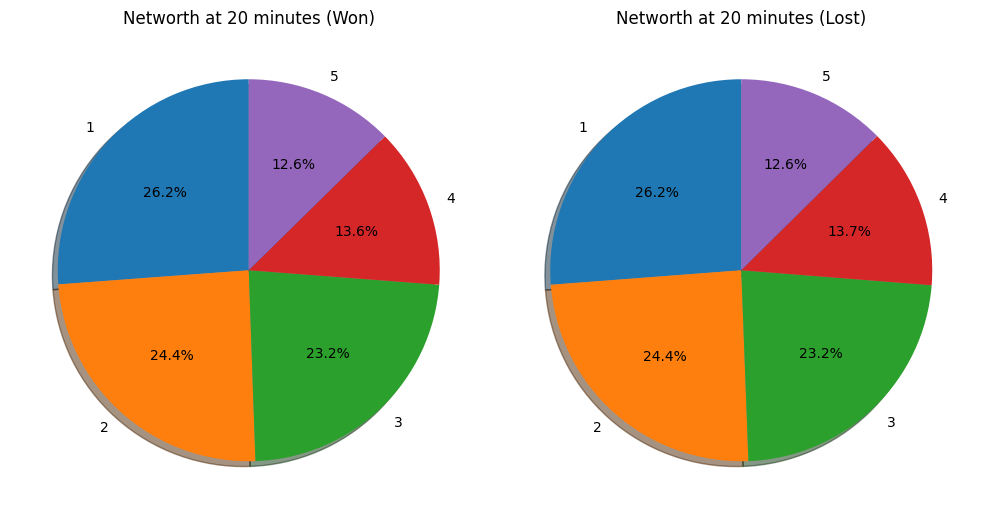

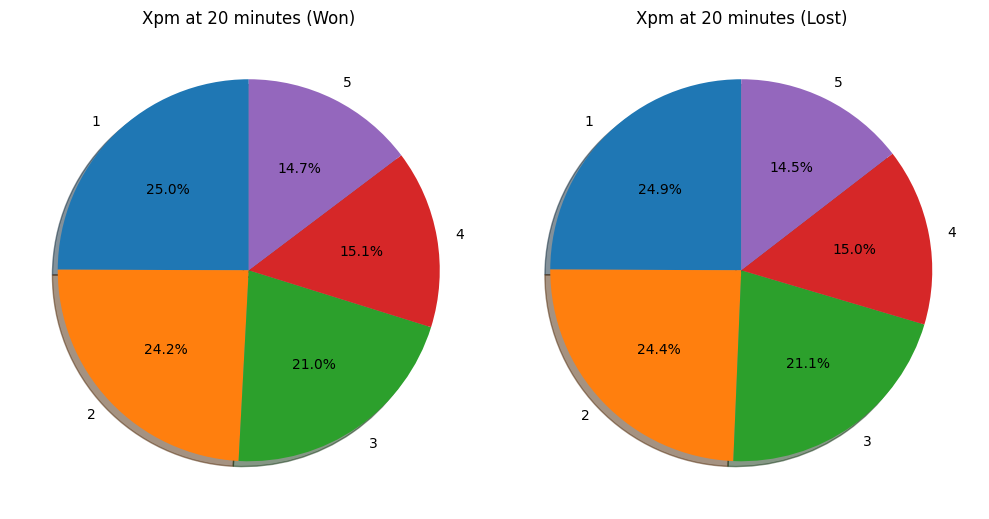

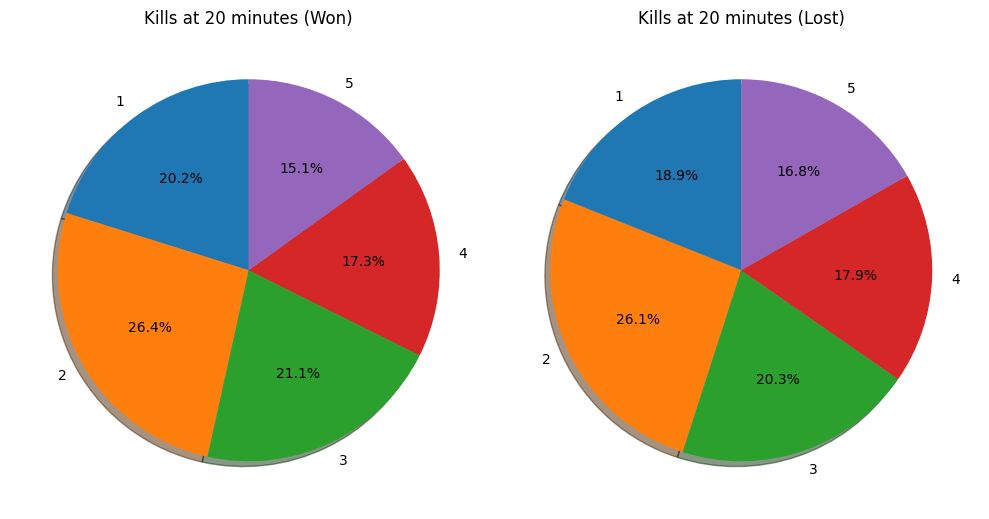

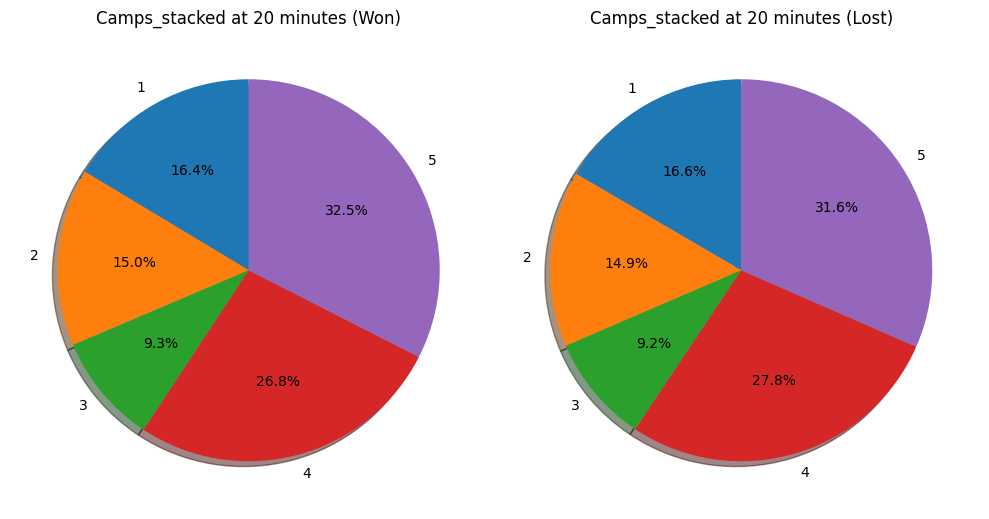

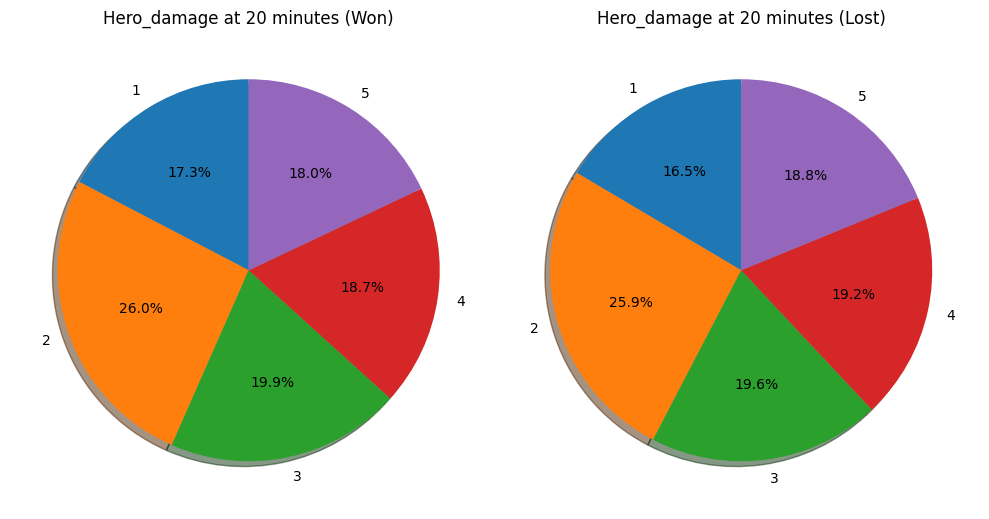

In [26]:
# plot total networth of each team as a pie chart
winner_copy = winner_data.copy(deep=True)
loser_copy = loser_data.copy(deep=True)
player_params = ["networth", "xpm", "kills", "camps_stacked", "hero_damage"]
time = analysis_time

for param in player_params:
    _, pie_axs = plt.subplots(1, 2, figsize=(10, 10))
    winner_pie = {}
    loser_pie = {}
    for pos in positions:
        col = f"position_{pos}_{param}_{time}"
        winner_pie[pos] = winner_copy[col].mean()
        loser_pie[pos] = loser_copy[col].mean()

    title = f"{param.capitalize()} at {time} minutes"
    # plot winner data
    ax = pie_axs[0]
    ax.pie(
        winner_pie.values(),
        labels=winner_pie.keys(),
        autopct="%1.1f%%",
        shadow=True,
        startangle=90,
    )
    ax.set_title(f"{title} (Won)")

    # plot loser data
    ax = pie_axs[1]
    ax.pie(
        loser_pie.values(),
        labels=loser_pie.keys(),
        autopct="%1.1f%%",
        shadow=True,
        startangle=90,
    )
    ax.set_title(f"{title} (Lost)")
    plt.tight_layout()
    plt.show()

### Correlations

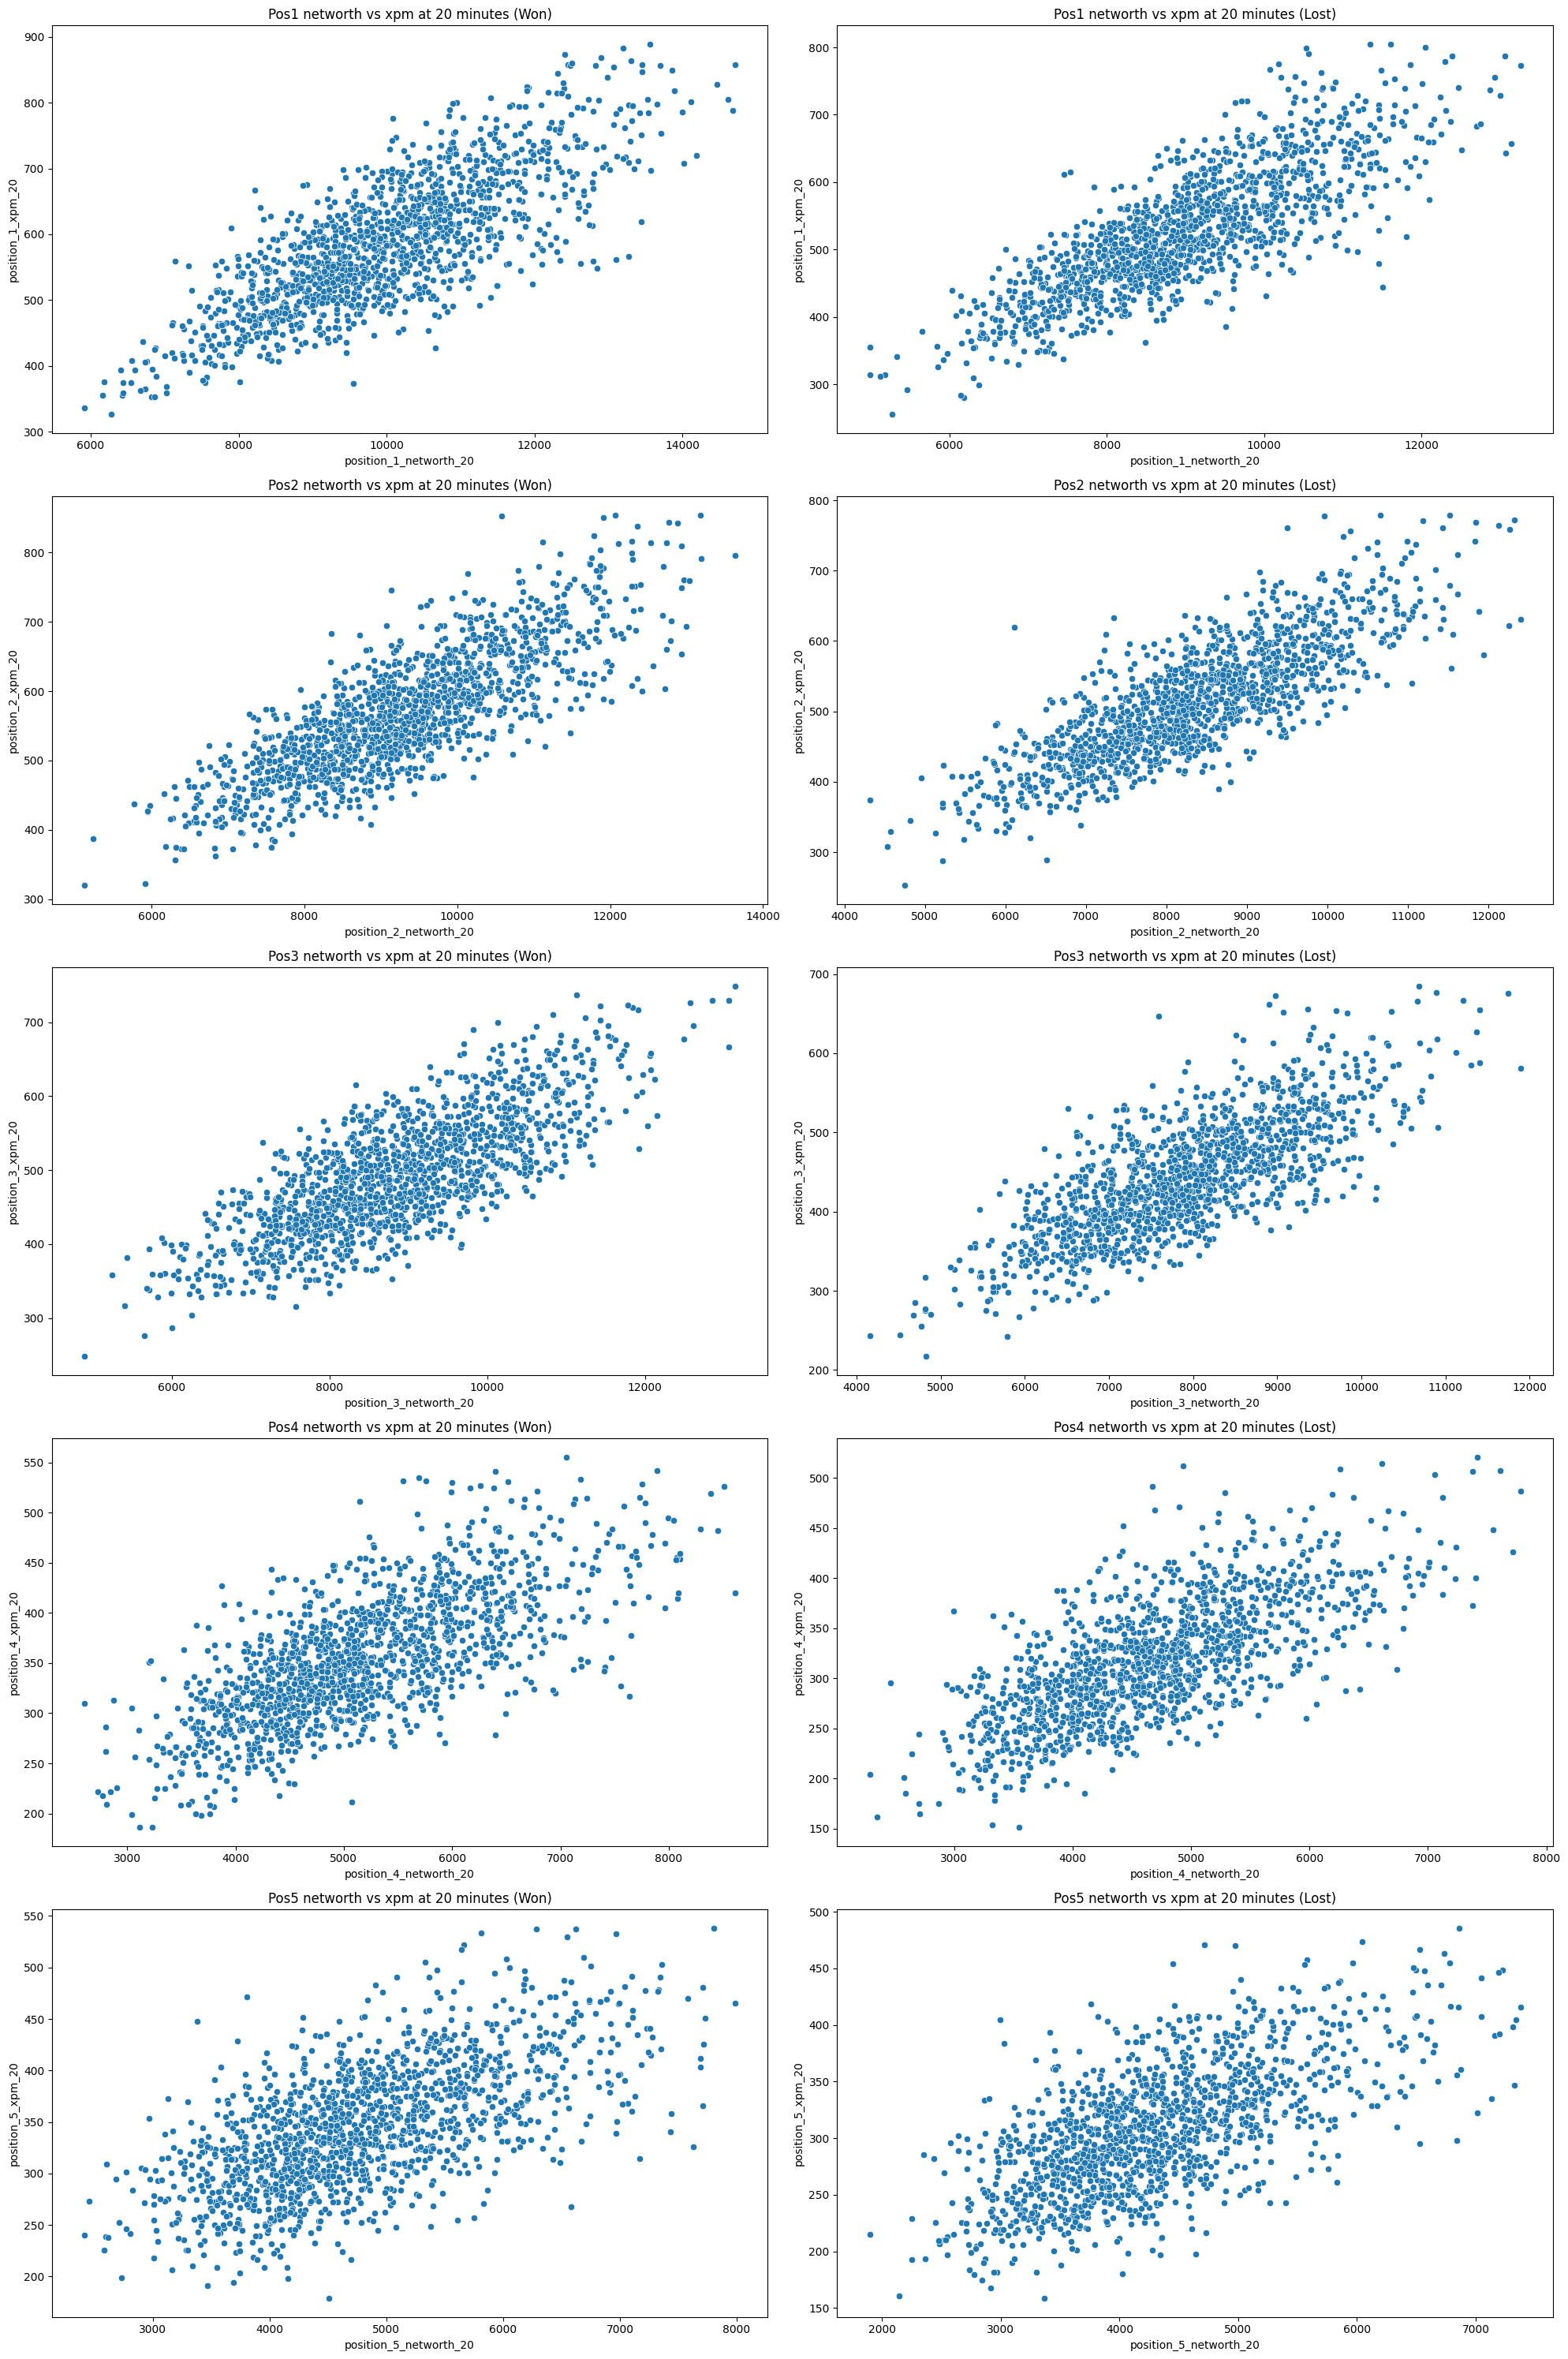

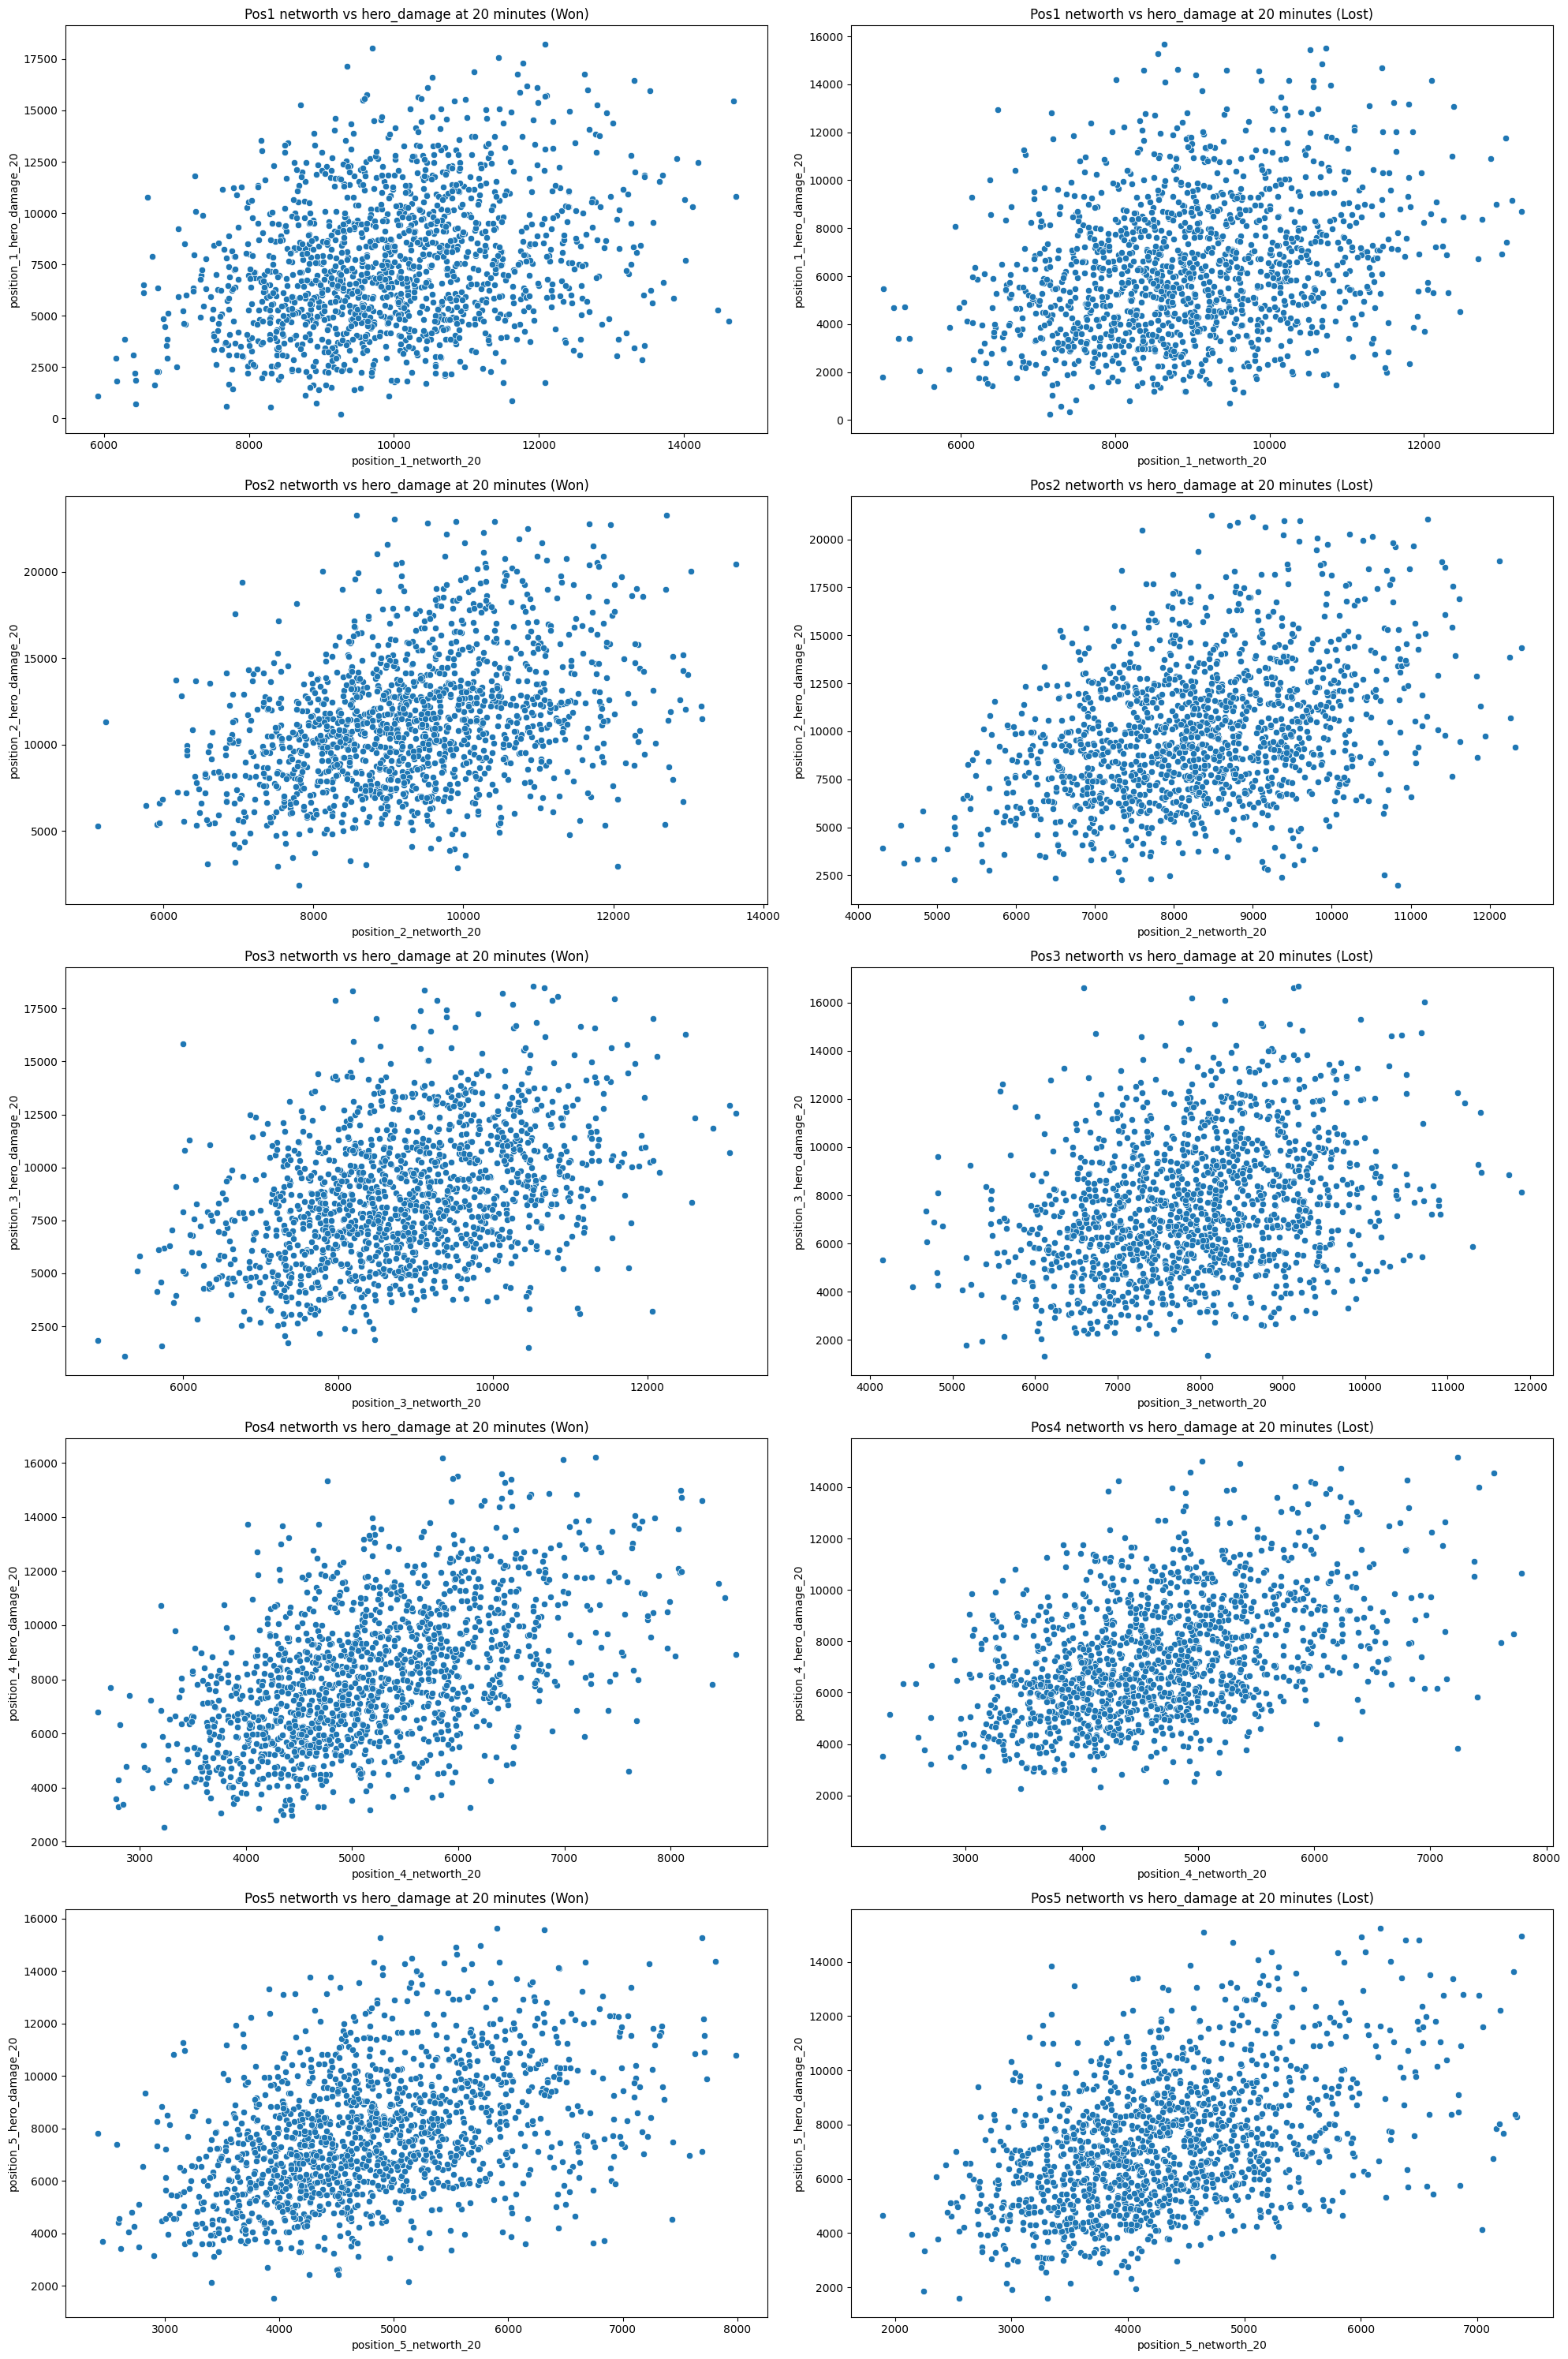

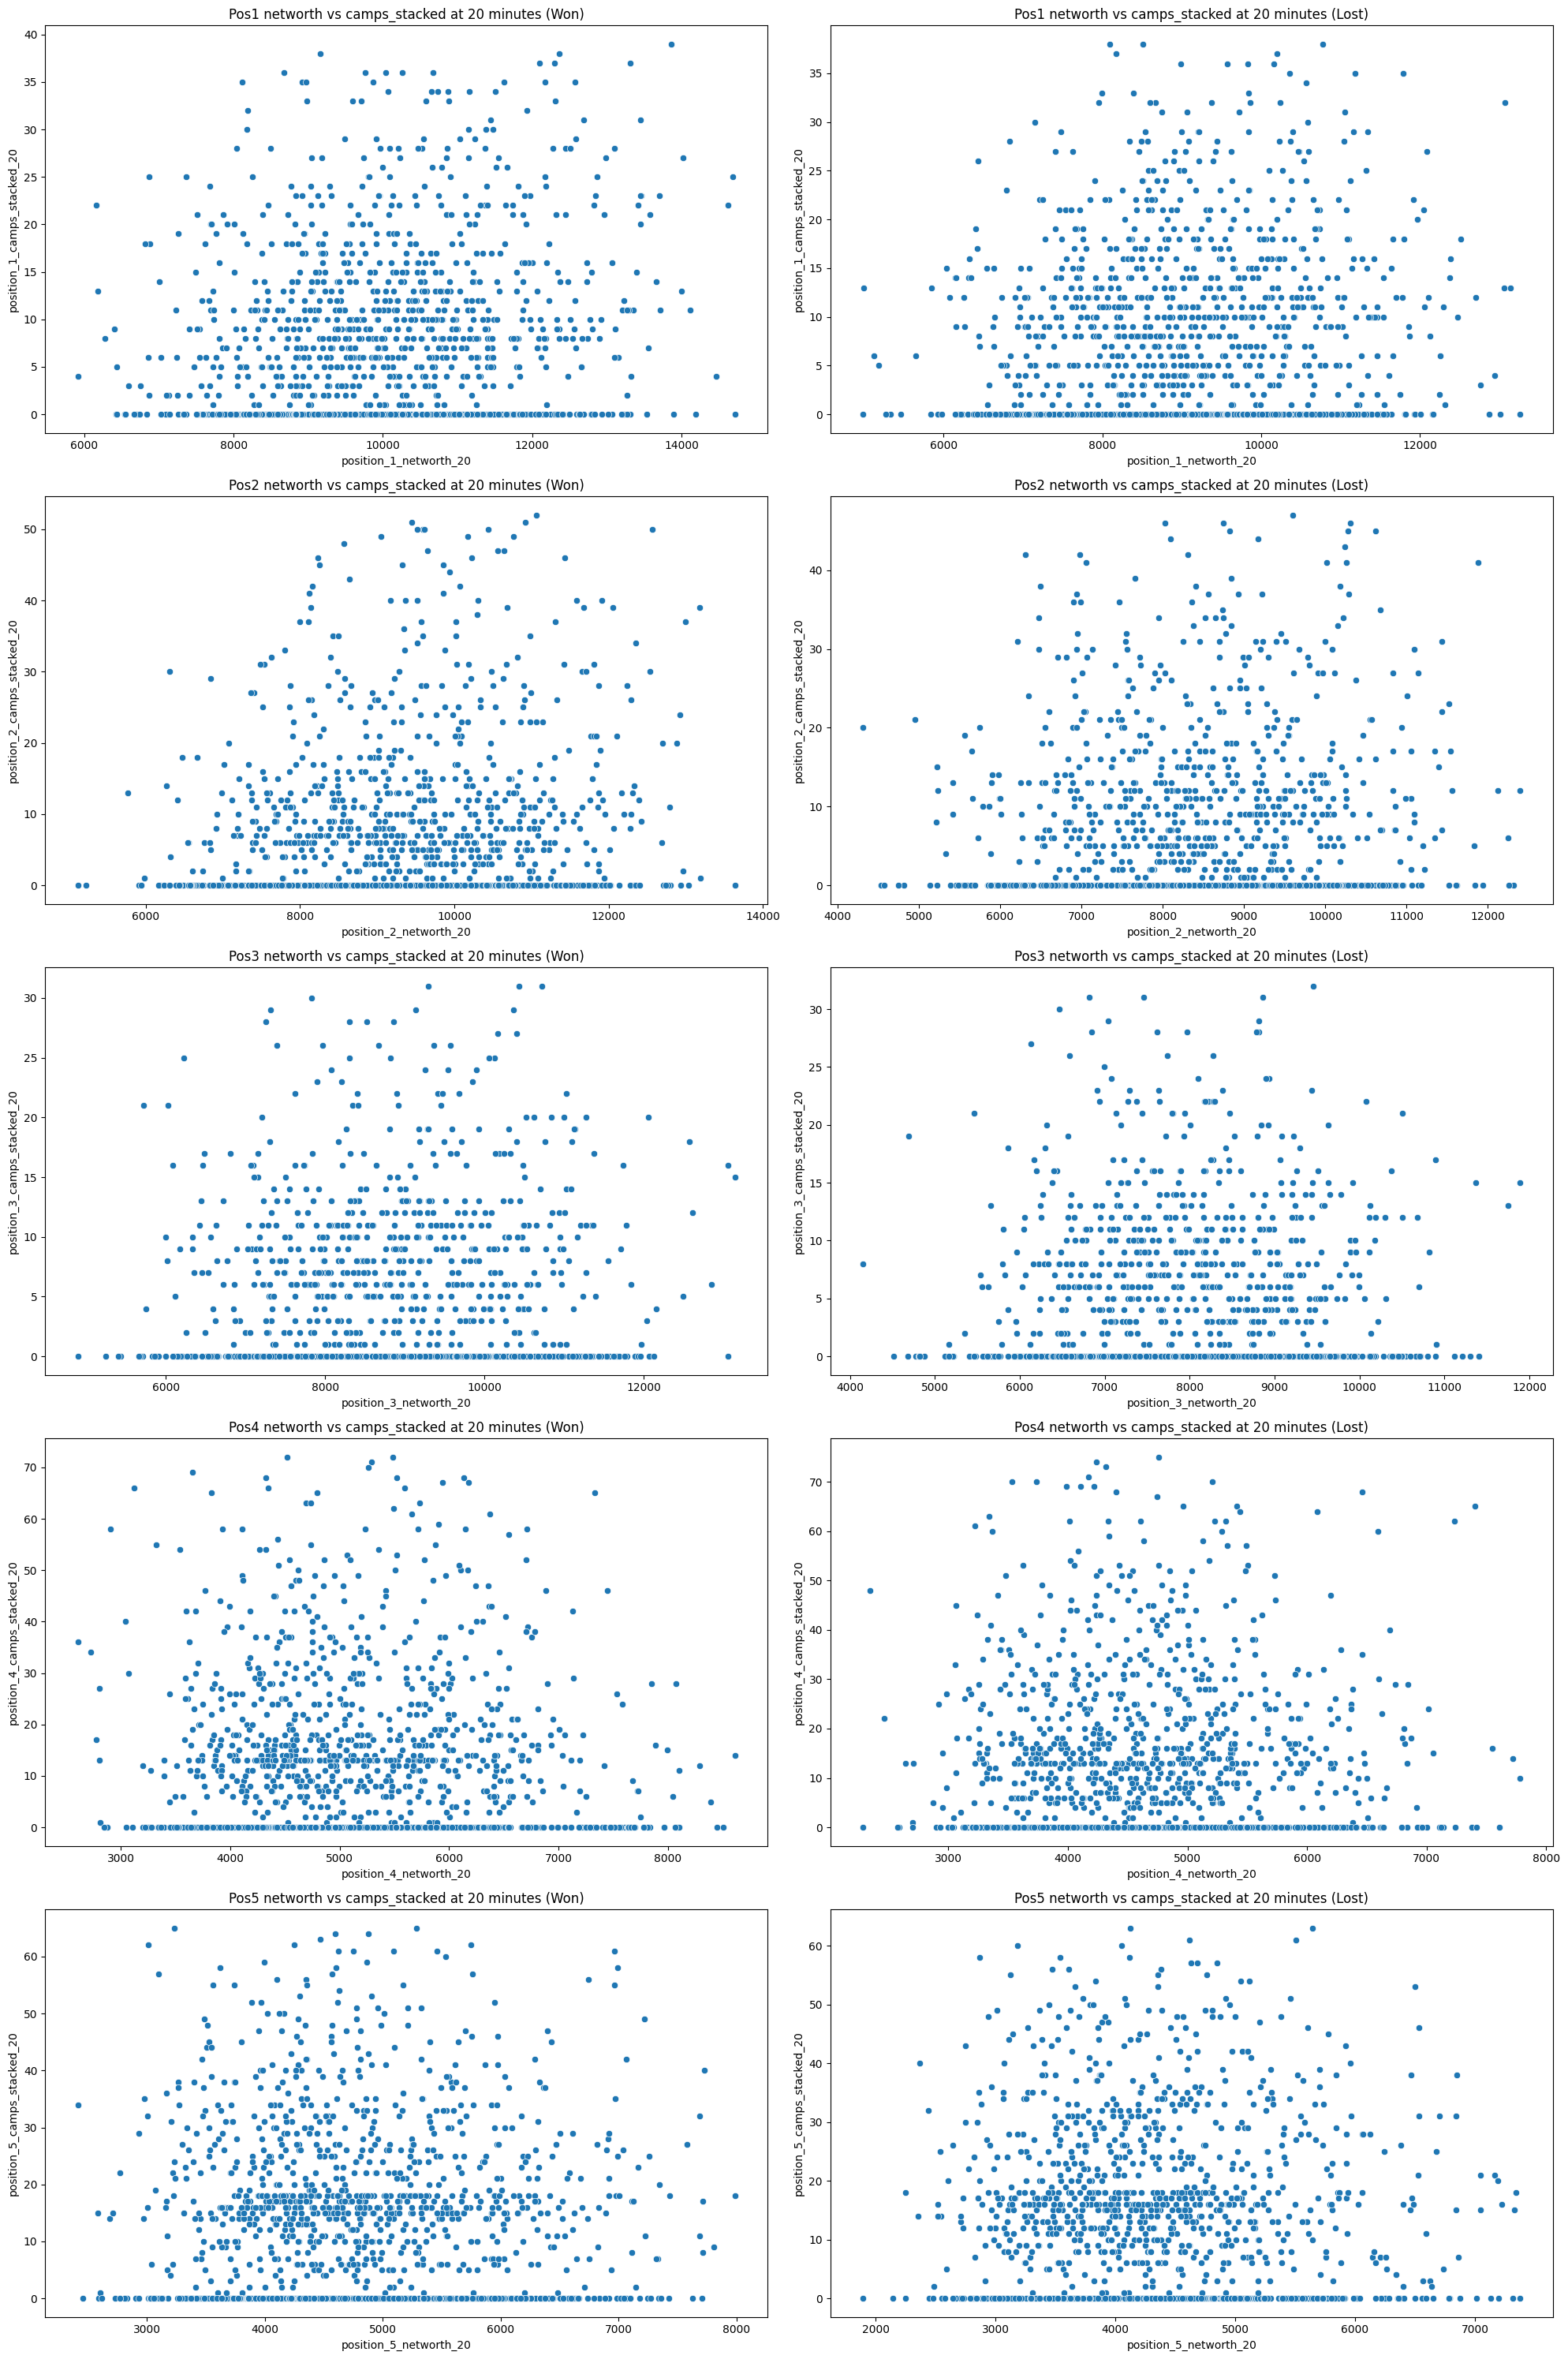

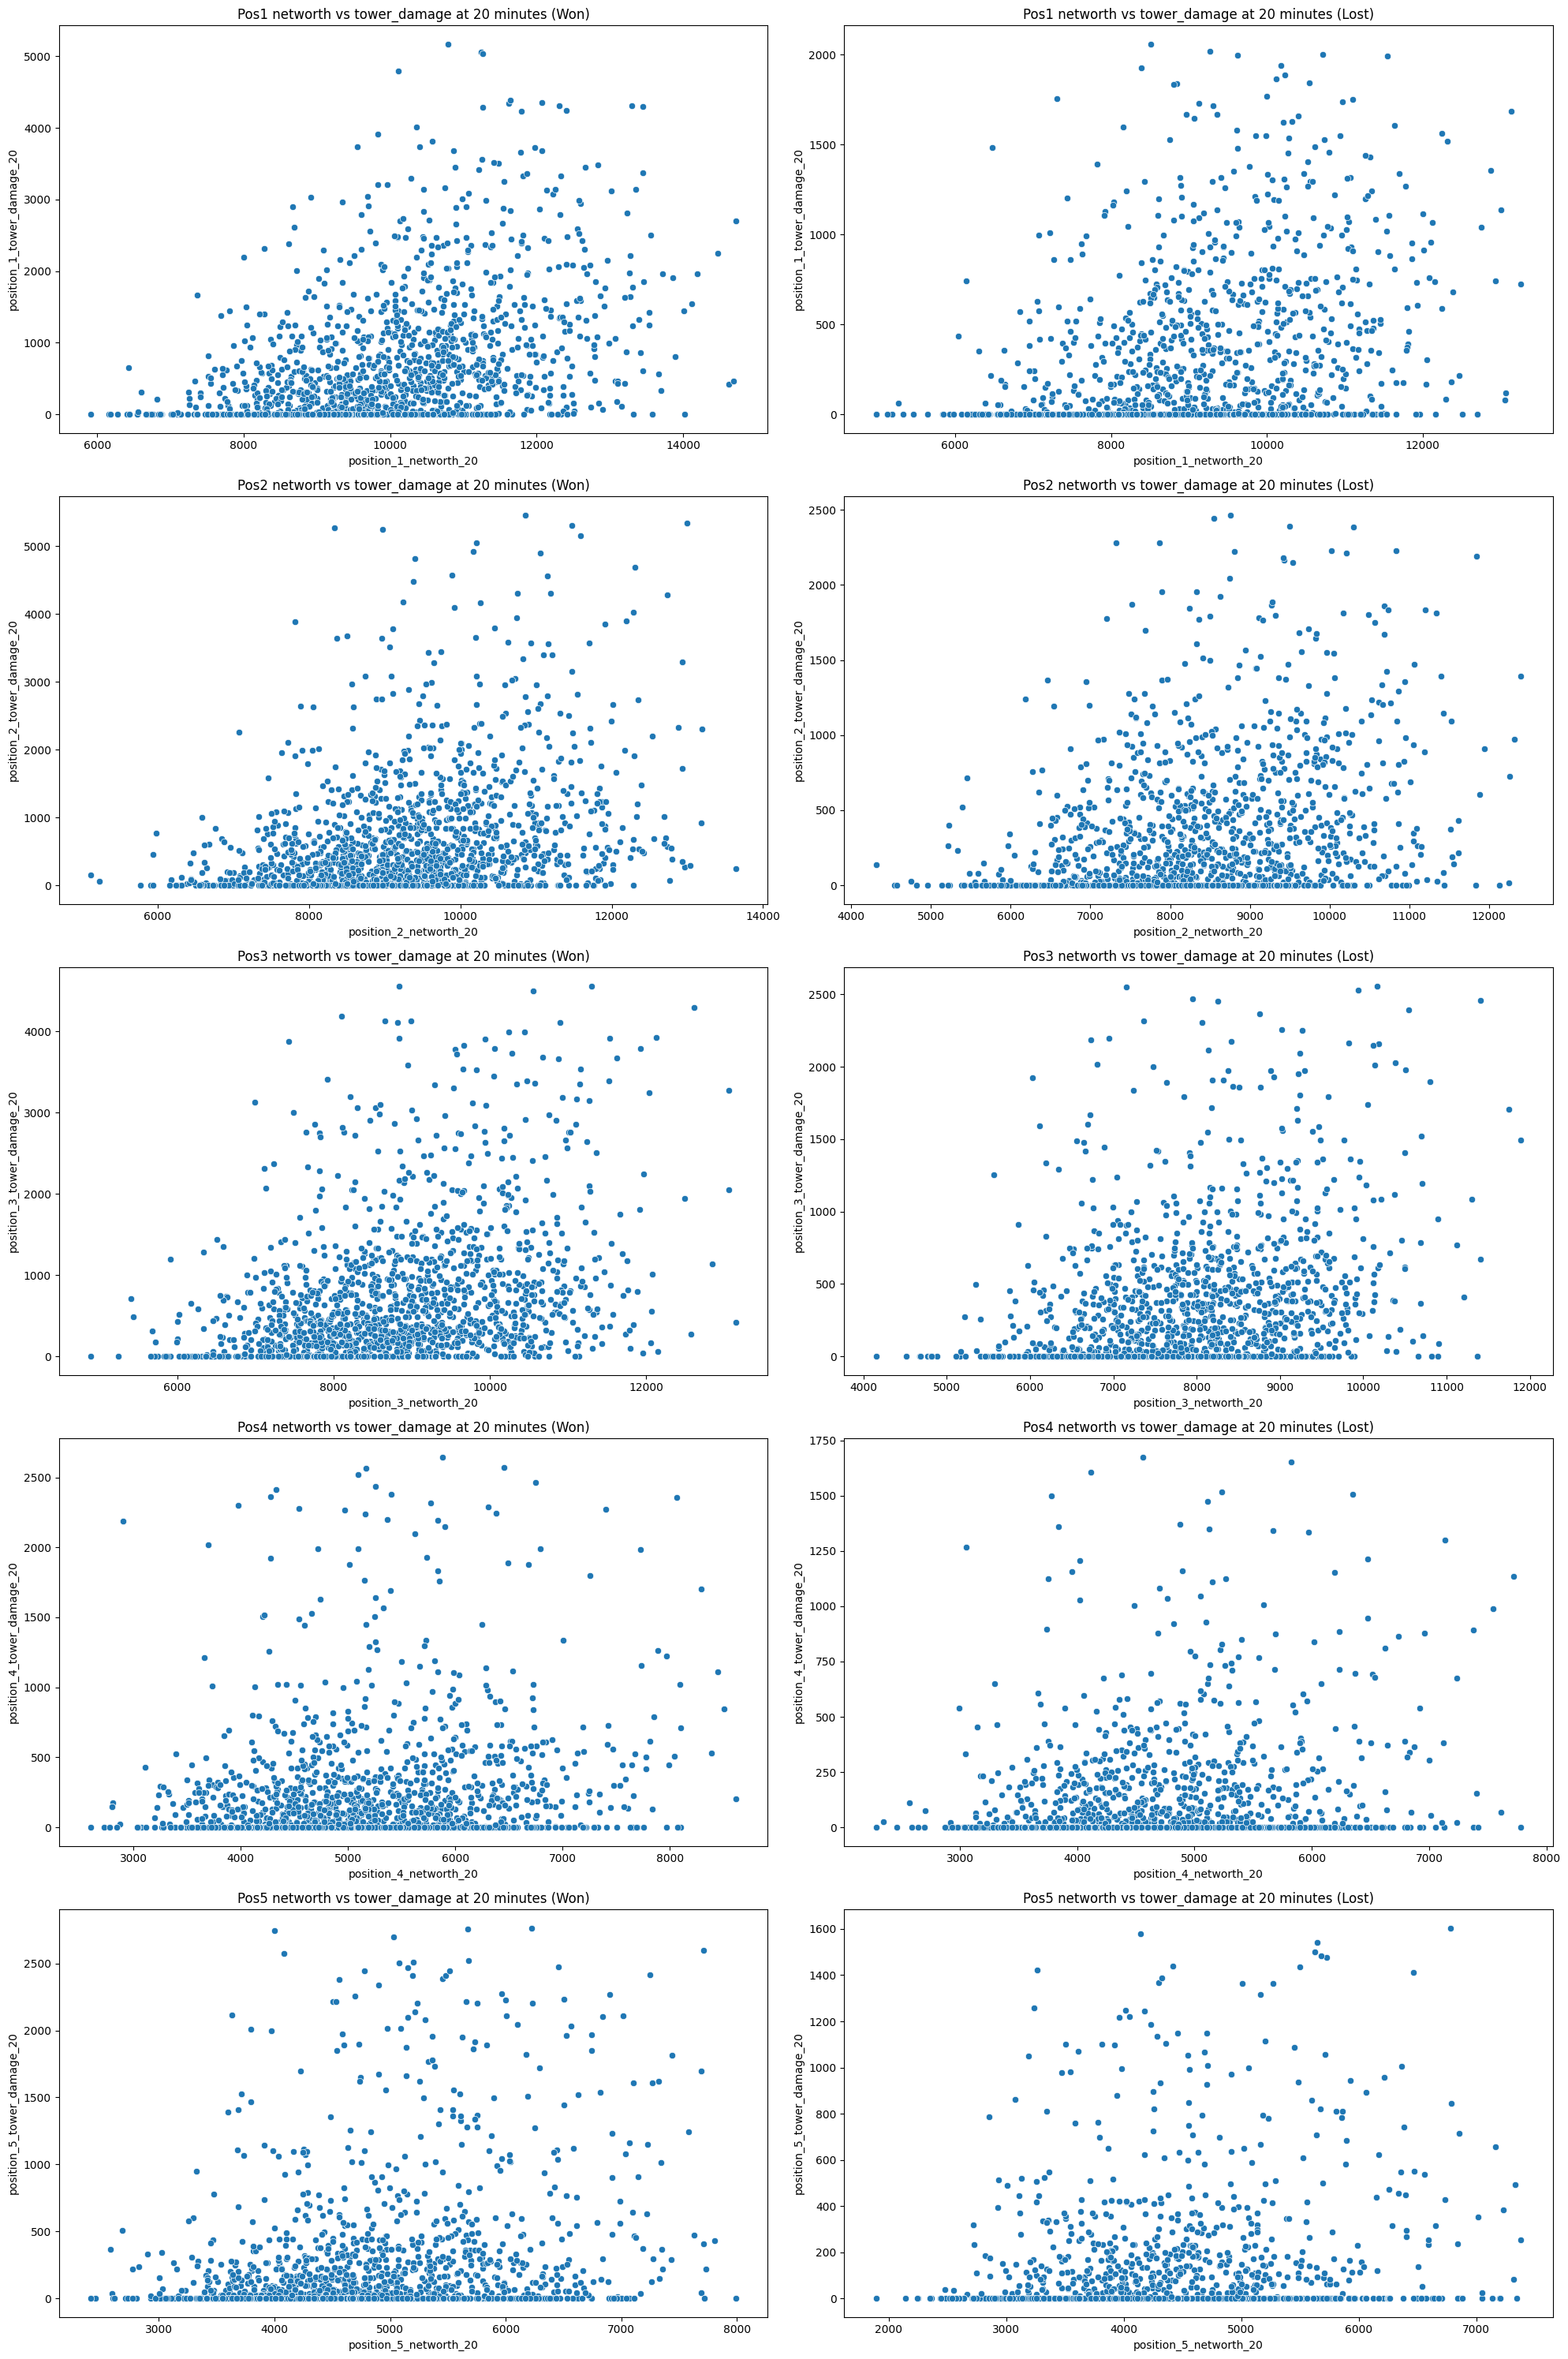

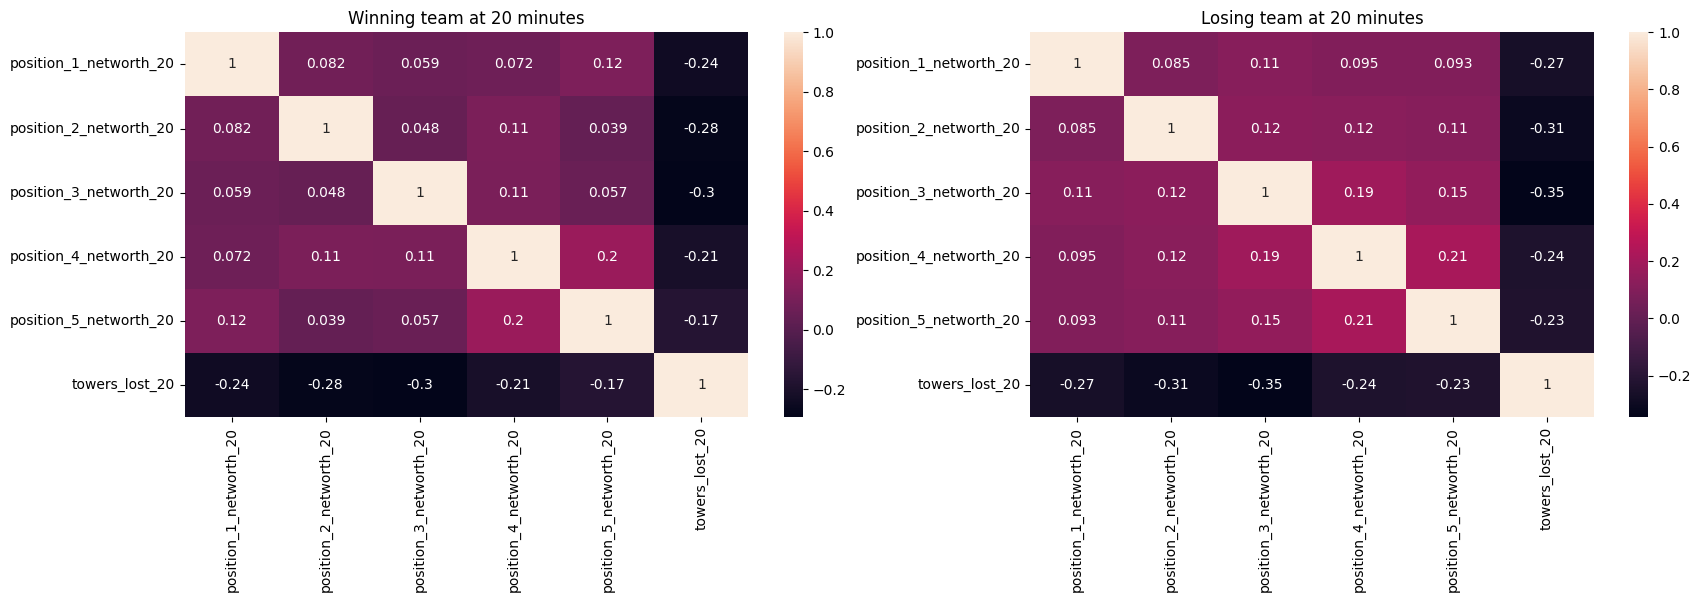

In [27]:
# plot total networth of each team as a pie chart
winner_copy = winner_data.copy(deep=True)
loser_copy = loser_data.copy(deep=True)
main_param = "networth"
player_params = ["xpm", "hero_damage", "camps_stacked", "tower_damage"]
game_params = ["towers_lost"]
time = analysis_time

for param in player_params:
    _, scatter_axs = plt.subplots(5, 2, figsize=(20, 30))
    for idx, pos in enumerate(positions):
        col = f"position_{pos}_{param}_{time}"
        main_col = f"position_{pos}_{main_param}_{time}"
        title = f"Pos{pos} {main_param} vs {param} at {time} minutes"

        # plot scatter plots
        ax = scatter_axs[idx, 0]
        sns.scatterplot(
            x=winner_copy[main_col],
            y=winner_copy[col],
            ax=ax,
        )
        ax.set_title(f"{title} (Won)")

        ax = scatter_axs[idx, 1]
        sns.scatterplot(
            x=loser_copy[main_col],
            y=loser_copy[col],
            ax=ax,
        )
        ax.set_title(f"{title} (Lost)")
    plt.tight_layout()

# plot a heatmap of correlations
plot_params = ["networth"]
game_params = ["towers_lost"]
heatmap_cols = []

for param in plot_params:
    for pos in positions:
        col = f"position_{pos}_{param}_{time}"
        heatmap_cols.append(col)

for param in game_params:
    col = f"{param}_{time}"
    heatmap_cols.append(col)

winner_hmap = winner_copy[heatmap_cols]
loser_hmap = loser_copy[heatmap_cols]

_, ax = plt.subplots(1, 2, figsize=(20, 5))
sns.heatmap(winner_hmap.corr(), annot=True, ax=ax[0])
ax[0].set_title(f"Winning team at {time} minutes")

sns.heatmap(loser_hmap.corr(), annot=True, ax=ax[1])
ax[1].set_title(f"Losing team at {time} minutes")
plt.show()

### Predictor analysis
**T-tests for individual predictors**

In [28]:
winner_copy, loser_copy = load_data(time=analysis_time, hero_count=hero_limit)
player_params = ["networth", "hero_damage", "camps_stacked", "tower_damage", "xpm", "kills"]
game_params = ["towers_lost"]


p_values = {}
time = analysis_time
for param in player_params:
    for pos in positions:
        col = f"position_{pos}_{param}_{time}"
        winner_col = winner_copy[col]
        loser_col = loser_copy[col]
        t, p = stats.ttest_ind(winner_col, loser_col, equal_var=False)
        p_values[col] = p

for param in game_params:
    col = f"{param}_{time}"
    winner_col = winner_copy[col]
    loser_col = loser_copy[col]
    t, p = stats.ttest_ind(winner_col, loser_col, equal_var=False)
    p_values[col] = p

# for param in category_params:
#     col = param
#     winner_col = winner_copy[col]
#     loser_col = loser_copy[col]
#     t, p = stats.ttest_ind(winner_col, loser_col, equal_var=False)
#     p_values[col] = p

p_values = pd.DataFrame.from_dict(p_values, orient="index", columns=["p-value"])
print(p_values)

(1457, 36) (1384, 36)
                                   p-value
position_1_networth_20        2.630729e-79
position_2_networth_20        4.128786e-77
position_3_networth_20        3.494395e-87
position_4_networth_20        3.212021e-45
position_5_networth_20        7.468282e-47
position_1_hero_damage_20     4.963623e-25
position_2_hero_damage_20     4.710531e-23
position_3_hero_damage_20     4.352896e-23
position_4_hero_damage_20     2.097387e-16
position_5_hero_damage_20     4.947352e-10
position_1_camps_stacked_20   4.610802e-01
position_2_camps_stacked_20   8.204021e-01
position_3_camps_stacked_20   9.430523e-01
position_4_camps_stacked_20   2.321261e-01
position_5_camps_stacked_20   8.540398e-01
position_1_tower_damage_20    1.461549e-54
position_2_tower_damage_20    5.449525e-42
position_3_tower_damage_20    1.760485e-46
position_4_tower_damage_20    6.623439e-21
position_5_tower_damage_20    7.541450e-24
position_1_xpm_20             3.325631e-60
position_2_xpm_20             1.

### Model fitting

In [29]:
winner_copy, loser_copy = load_data(time=analysis_time, hero_count=60)

player_params = ["networth"]
game_params = ["towers_lost"]

time = analysis_time
model_params = []

for param in player_params:
    for pos in positions:
        col = f"position_{pos}_{param}_{time}"
        model_params.append(col)

for param in game_params:
    col = f"{param}_{time}"
    model_params.append(col)

# winner_copy["interaction"] = winner_copy["position_1_networth_20"] * winner_copy["towers_lost_20"]
# loser_copy["interaction"] = loser_copy["position_1_networth_20"] * loser_copy["towers_lost_20"]
# model_params.append("interaction")

# logarithmic normalization for skewed data
winner_copy[model_params] = np.log(winner_copy[model_params] + 1)
loser_copy[model_params] = np.log(loser_copy[model_params] + 1)

# standard normalization
# winner_copy[model_params] = (
#     winner_copy[model_params] - winner_copy[model_params].mean()
# ) / winner_copy[model_params].std()

# loser_copy[model_params] = (
#     loser_copy[model_params] - loser_copy[model_params].mean()
# ) / loser_copy[model_params].std()

# add result column
model_params.append("result")
winner_copy["result"] = 1
loser_copy["result"] = 0

# combine data
game_data = pd.concat([winner_copy, loser_copy], axis=0)
# game_data["result"] = game_data["result"].astype("category")
game_data = game_data[model_params]

game_data.head()

# game_data = game_data.dropna()
# print(game_data.describe(include="all"))

# fit a model
X = game_data.drop("result", axis=1)
Y = game_data["result"]

# add constant
X = sm.add_constant(X)
model = sm.Logit(Y, X).fit()
print(model.summary())
print("AIC:", model.aic)
print("BIC:", model.bic)


(2673, 36) (2558, 36)
Optimization terminated successfully.
         Current function value: 0.501925
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                 result   No. Observations:                 5231
Model:                          Logit   Df Residuals:                     5224
Method:                           MLE   Df Model:                            6
Date:                Mon, 11 Dec 2023   Pseudo R-squ.:                  0.2756
Time:                        23:29:10   Log-Likelihood:                -2625.6
converged:                       True   LL-Null:                       -3624.6
Covariance Type:            nonrobust   LLR p-value:                     0.000
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                   -103.5065      4.231    -24.467      0

### Multi-collinearity test


In [30]:
# Assuming X is your predictors DataFrame
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [
    variance_inflation_factor(X.values, i) for i in range(len(X.columns))
]
print(vif_data)

                  feature           VIF
0                   const  10853.412164
1  position_1_networth_20      1.206485
2  position_2_networth_20      1.210723
3  position_3_networth_20      1.244393
4  position_4_networth_20      1.145213
5  position_5_networth_20      1.138603
6          towers_lost_20      1.567914


### Goodness of the fit

In [31]:
# Pseudo R-squared
print("Pseudo R-squared:", model.prsquared)

# Making predictions
predictions = model.predict(sm.add_constant(X))
predictions_binary = [1 if x > 0.5 else 0 for x in predictions]

# Confusion Matrix
conf_matrix = confusion_matrix(Y, predictions_binary)
print("Confusion Matrix:\n", conf_matrix)

# Classification Report
class_report = classification_report(Y, predictions_binary)
print("Classification Report:\n", class_report)

Pseudo R-squared: 0.27562205039954357
Confusion Matrix:
 [[1871  687]
 [ 634 2039]]
Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.73      0.74      2558
           1       0.75      0.76      0.76      2673

    accuracy                           0.75      5231
   macro avg       0.75      0.75      0.75      5231
weighted avg       0.75      0.75      0.75      5231



### Likelihood test

In [32]:
X["intercept"] = 1.0
reduced_x = X["intercept"]
reduced_model = sm.Logit(
    Y, reduced_x
).fit()  # X_reduced contains only a subset of predictors

print(reduced_model.summary())

# Perform Likelihood Ratio Test
D = -2 * (reduced_model.llf - model.llf)
p_value = stats.chi2.sf(D, df=model.df_model - reduced_model.df_model)

print("Likelihood Ratio Test Statistic:", D)
print("P-value:", p_value)

if p_value < 0.05:
    print(
        "The test is significant: The full model provides a significantly better fit than the reduced model."
    )
else:
    print(
        "The test is not significant: The additional predictors do not significantly improve the model's fit."
    )

Optimization terminated successfully.
         Current function value: 0.692906
         Iterations 3
                           Logit Regression Results                           
Dep. Variable:                 result   No. Observations:                 5231
Model:                          Logit   Df Residuals:                     5230
Method:                           MLE   Df Model:                            0
Date:                Mon, 11 Dec 2023   Pseudo R-squ.:               1.062e-10
Time:                        23:29:10   Log-Likelihood:                -3624.6
converged:                       True   LL-Null:                       -3624.6
Covariance Type:            nonrobust   LLR p-value:                       nan
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.0440      0.028      1.590      0.112      -0.010       0.098
Likelihood Ratio Test Statist

In [33]:
# # test for interactions
# winner_copy, loser_copy = load_data(time=analysis_time, hero_count=60)
# winner_copy["result"] = 1
# loser_copy["result"] = 0

# game_data = pd.concat([winner_copy, loser_copy], axis=0)

# player_params = ["networth"]
# game_params = ["towers_lost"]

# time = analysis_time
# model_params = []

# pos_columns = {}

# for pos in positions:
#     for param in player_params:
#         col = f"position_{pos}_{param}_{time}"
#         model_params.append(col)
#         pos_columns[pos] = col

# for param in game_params:
#     col = f"{param}_{time}"
#     model_params.append(col)

# # add interactions
# interactions = {
#     "pos1_x_pos5": ["1", "5"],
#     "pos3_x_pos4": ["3", "4"],
#     "pos1_x_pos4": ["1", "4"],
# }

# for key, value in interactions.items():
#     x1, x2 = value
#     winner_copy[key] = (
#         winner_copy[pos_columns[x1]] * winner_copy[pos_columns[x2]]
#     )
#     loser_copy[key] = loser_copy[pos_columns[x1]] * loser_copy[pos_columns[x2]]
#     model_params.append(key)

# # logarithmic normalization for skewed data
# winner_copy[model_params] = np.log(winner_copy[model_params] + 1)
# loser_copy[model_params] = np.log(loser_copy[model_params] + 1)

# # add result column
# model_params.append("result")
# winner_copy["result"] = 1
# loser_copy["result"] = 0

# # combine data
# game_data = pd.concat([winner_copy, loser_copy], axis=0)
# # game_data["result"] = game_data["result"].astype("category")
# game_data = game_data[model_params]

# X = game_data.drop("result", axis=1)
# Y = game_data["result"]

# # add constant
# X = sm.add_constant(X)
# interaction_model = sm.Logit(Y, X).fit()
# print(interaction_model.summary())
# print("AIC:", interaction_model.aic)
# print("BIC:", interaction_model.bic)

# # Perform Likelihood Ratio Test
# D = -2 * (interaction_model.llf - reduced_model.llf)
# p_value = stats.chi2.sf(
#     D, df=reduced_model.df_model - interaction_model.df_model
# )

# print("Likelihood Ratio Test Statistic:", D)
# print("P-value:", p_value)

# if p_value < 0.05:
#     print(
#         "The test is significant: The full model provides a significantly better fit than the reduced model."
#     )
# else:
#     print(
#         "The test is not significant: The additional predictors do not significantly improve the model's fit."
#     )

### Hypothesis testing

In [34]:
# test for interactions
winner_copy, loser_copy = load_data(time=analysis_time, hero_count=60)
winner_copy["result"] = 1
loser_copy["result"] = 0

game_data = pd.concat([winner_copy, loser_copy], axis=0)

player_params = ["networth"]
game_params = ["towers_lost"]

time = analysis_time
model_params = []

pos_columns = {}

# convert absolute networth into percentage
for row in game_data:
    team_networth = 0
    for pos in positions:
        col = f"position_{pos}_networth_{time}"
        team_networth += game_data[col]

    for pos in positions:
        col = f"position_{pos}_networth_{time}"
        game_data[col] = np.round(game_data[col] / team_networth, 2)


for pos in (1, 2, 3, 4):
    for param in player_params:
        col = f"position_{pos}_{param}_{time}"
        model_params.append(col)
        pos_columns[pos] = col

# for param in game_params:
#     col = f"{param}_{time}"
#     model_params.append(col)

# add result column
model_params.append("result")
winner_copy["result"] = 1
loser_copy["result"] = 0

# combine data
game_data = pd.concat([winner_copy, loser_copy], axis=0)
# game_data["result"] = game_data["result"].astype("category")
game_data = game_data[model_params]


X = game_data.drop("result", axis=1)
Y = game_data["result"]

# add constant
X = sm.add_constant(X)
hypothesis_model = sm.Logit(Y, X).fit()
print(hypothesis_model.summary())
print("AIC:", hypothesis_model.aic)
print("BIC:", hypothesis_model.bic)


# Perform Likelihood Ratio Test
D = -2 * (hypothesis_model.llf - reduced_model.llf)
p_value = stats.chi2.sf(
    D, df=reduced_model.df_model - hypothesis_model.df_model
)

print("Likelihood Ratio Test Statistic:", D)
print("P-value:", p_value)

if p_value < 0.05:
    print(
        "The test is significant: The full model provides a significantly better fit than the reduced model."
    )
else:
    print(
        "The test is not significant: The additional predictors do not significantly improve the model's fit."
    )

(2673, 36) (2558, 36)
Optimization terminated successfully.
         Current function value: 0.523259
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                 result   No. Observations:                 5231
Model:                          Logit   Df Residuals:                     5226
Method:                           MLE   Df Model:                            4
Date:                Mon, 11 Dec 2023   Pseudo R-squ.:                  0.2448
Time:                        23:29:11   Log-Likelihood:                -2737.2
converged:                       True   LL-Null:                       -3624.6
Covariance Type:            nonrobust   LLR p-value:                     0.000
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                    -13.7795      0.415    -33.237      0

In [35]:
# residual plot
predicted_probabilities = model.predict(X)
pearson_residuals = model.resid_pearson

fig, ax = plt.subplots(figsize=(10, 10))
ax.scatter(predicted_probabilities, pearson_residuals)
ax.set_xlabel("Predicted Probabilities")
ax.set_ylabel("Pearson Residuals")

# LOWESS smoothing
smoothed = sm.nonparametric.lowess(
    pearson_residuals, predicted_probabilities
)
abs_smoothed_values = np.abs(smoothed[:, 1])
ax.plot(smoothed[:, 0], smoothed[:, 1], color="black")

plt.axhline(y=0, color="red", linestyle="--", linewidth=2)
plt.title("Residual Plot for Logistic Regression Model")
plt.show()

ValueError: shapes (5231,5) and (7,) not aligned: 5 (dim 1) != 7 (dim 0)

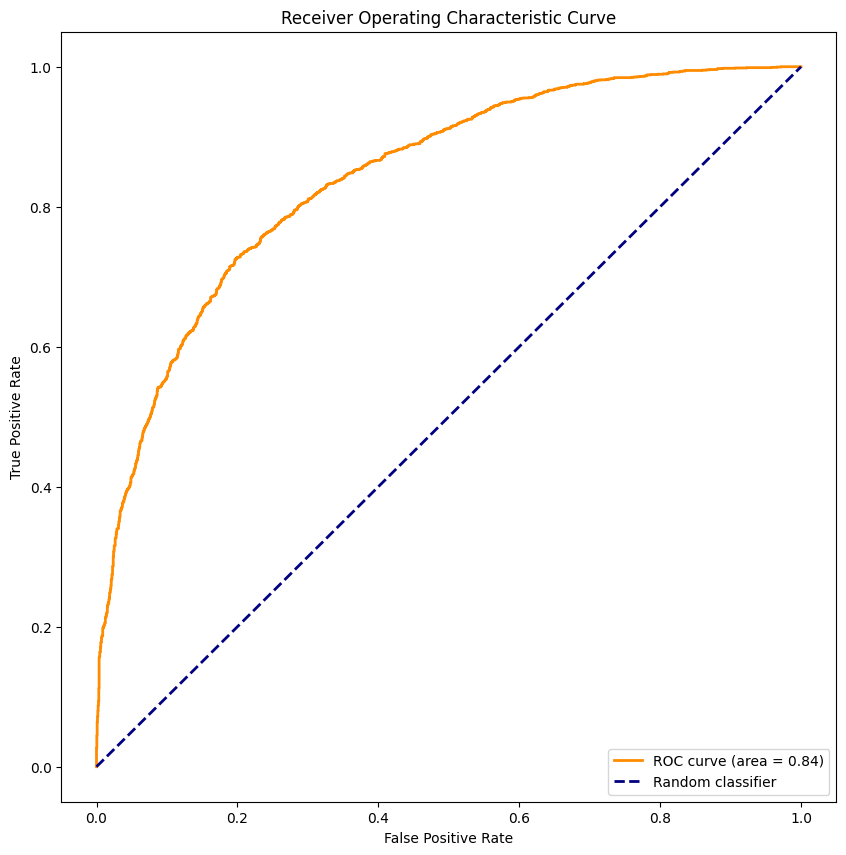

In [ ]:
# Compute ROC curve
fpr, tpr, thresholds = roc_curve(Y, predicted_probabilities)

# Compute AUC (Area Under the Curve)
roc_auc = auc(fpr, tpr)

# Plot ROC curve

plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = {:.2f})'.format(roc_auc))
plt.plot([0, 1], [0, 1], color='navy', lw=2, label="Random classifier", linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic Curve')
plt.legend(loc='lower right')
plt.show()

In [ ]:
# Calculate predictions
game_data["predictions"] = model.predict(X)

# Binning the data into deciles
game_data["decile"] = pd.qcut(game_data["predictions"], 10, labels=False)

# Calculating observed and expected frequencies
# game_data["result"] = game_data["result"].astype("int")
observed = game_data.groupby("decile")["result"].sum()
total = game_data.groupby("decile")["result"].count()
expected = total * game_data.groupby("decile")["predictions"].mean()

# Calculating the Hosmer-Lemeshow statistic
chi_squared = ((observed - expected) ** 2 / expected).sum()
degrees_of_freedom = 8  # 10 deciles - 2
p_value = stats.chi2.sf(chi_squared, degrees_of_freedom)

print("Hosmer-Lemeshow test statistic: ", chi_squared)
print("Degrees of freedom: ", degrees_of_freedom)
print("P-value: ", p_value)

Hosmer-Lemeshow test statistic:  4.858590720527118
Degrees of freedom:  8
P-value:  0.7725777443477942


### Forward selection

In [ ]:
def forward_selection_with_interactions(data, response):
    """
    Perform forward selection with interactions and return the model with the lowest AIC
    """
    remaining = set(data.columns)
    remaining.remove(response)
    selected = []
    aic_values = []
    current_score, best_new_score = float("inf"), float("inf")

    while remaining and current_score == best_new_score:
        scores_with_candidates = []

        # Evaluate adding each remaining predictor
        for candidate in remaining:
            formula = "{} ~ {}".format(
                response, " + ".join(selected + [candidate])
            )
            score = sm.Logit.from_formula(formula, data).fit(disp=0).aic
            scores_with_candidates.append((score, candidate, ""))

        # Evaluate adding interactions between selected predictors and each remaining predictor
        for candidate in remaining:
            for feature in selected:
                interaction_term = f"{candidate}:{feature}"
                formula = "{} ~ {} + {}".format(
                    response,
                    " + ".join(selected + [candidate]),
                    interaction_term,
                )
                score = sm.Logit.from_formula(formula, data).fit(disp=0).aic
                scores_with_candidates.append(
                    (score, candidate, interaction_term)
                )

        # Choose the best candidate to add
        scores_with_candidates.sort()
        (
            best_new_score,
            best_candidate,
            interaction,
        ) = scores_with_candidates.pop(0)
        if current_score > best_new_score:
            remaining.remove(best_candidate)
            selected.append(best_candidate)
            if interaction:
                selected.append(interaction)
            current_score = best_new_score
            aic_values.append(current_score)

    formula = "{} ~ {}".format(response, " + ".join(selected))
    model = sm.Logit.from_formula(formula, data).fit(disp=0)
    return model, selected, aic_values

### Testing model with heroes and interactions

(1647, 11) (1615, 11)


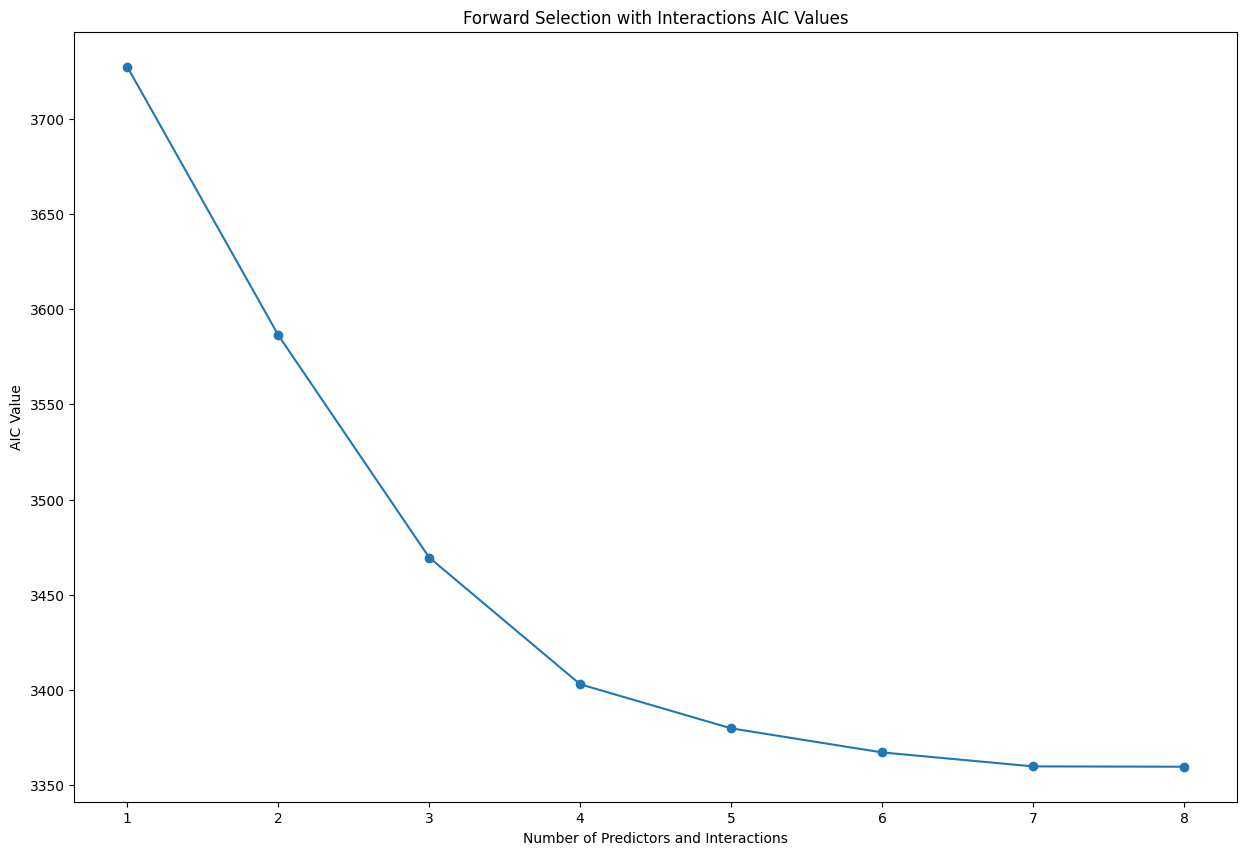

                           Logit Regression Results                           
Dep. Variable:                 result   No. Observations:                 3262
Model:                          Logit   Df Residuals:                     3250
Method:                           MLE   Df Model:                           11
Date:                Fri, 08 Dec 2023   Pseudo R-squ.:                  0.2623
Time:                        08:49:28   Log-Likelihood:                -1667.8
converged:                       True   LL-Null:                       -2260.9
Covariance Type:            nonrobust   LLR p-value:                1.522e-247
                                             coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------
Intercept                                 -8.2929      0.964     -8.605      0.000     -10.182      -6.404
towers_lost_20                            -0.21

In [ ]:
winner_copy, loser_copy = load_data(
    time=analysis_time,
    hero_count=hero_limit,
    include_result=True,
    include_heroes=True,
    player_params=["networth"],
)

game_data = pd.concat([winner_copy, loser_copy], axis=0)
response = "result"

model, selected_predictors, aic_values = forward_selection_with_interactions(
    game_data, "result"
)

# Plotting the AIC values
plt.figure(figsize=(15, 10))
plt.plot(range(1, len(aic_values) + 1), aic_values, marker="o")
plt.xlabel("Number of Predictors and Interactions")
plt.ylabel("AIC Value")
plt.title("Forward Selection with Interactions AIC Values")
plt.show()

# Printing the summary of the selected model
print(model.summary())

### Testing model without heroes, with interactions

(1436, 16) (1412, 16)


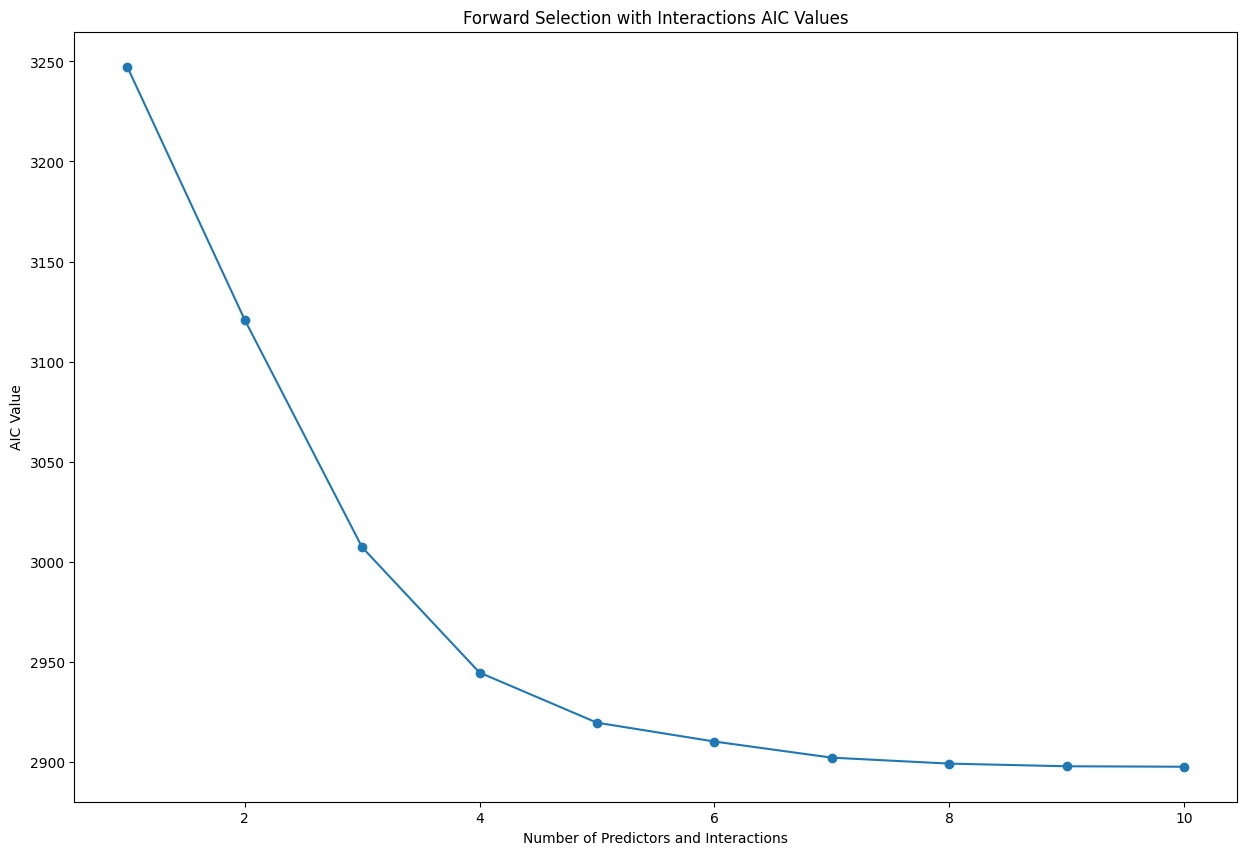

                           Logit Regression Results                           
Dep. Variable:                 result   No. Observations:                 2848
Model:                          Logit   Df Residuals:                     2831
Method:                           MLE   Df Model:                           16
Date:                Fri, 08 Dec 2023   Pseudo R-squ.:                  0.2747
Time:                        08:50:48   Log-Likelihood:                -1431.7
converged:                       True   LL-Null:                       -1974.0
Covariance Type:            nonrobust   LLR p-value:                8.720e-221
                                                                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------------------------------
Intercept                                                       -8.9478      1.458     -6.137      0.000     -

In [ ]:
winner_copy, loser_copy = load_data(
    time=analysis_time,
    hero_count=hero_limit,
    include_result=True,
    player_params=["networth", "hero_damage", "camps_stacked"],
)

game_data = pd.concat([winner_copy, loser_copy], axis=0)
response = "result"

model, selected_predictors, aic_values = forward_selection_with_interactions(
    game_data, "result"
)

# Plotting the AIC values
plt.figure(figsize=(15, 10))
plt.plot(range(1, len(aic_values) + 1), aic_values, marker="o")
plt.xlabel("Number of Predictors and Interactions")
plt.ylabel("AIC Value")
plt.title("Forward Selection with Interactions AIC Values")
plt.show()

# Printing the summary of the selected model
print(model.summary())